Email Used:
sarbajit.paul2001

## CELL 1 — Setup & Data Loading

In [ ]:
"""
fig20_search_keyword_cloud.pdf  — Search-string keyword word cloud
fig21_journal_keyword_cloud.pdf — Author/extracted keyword word cloud
Q1-standard: 1200 dpi, PDF vector, professional colour scheme
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import re, warnings, textwrap
warnings.filterwarnings("ignore")

# ─── SHARED STYLE ────────────────────────────────────────────────────────────
FONT = "DejaVu Sans"          # guaranteed present; swap for a TTF path if needed
SEED = 42

# ─── COLOUR PALETTES ─────────────────────────────────────────────────────────
# Fig 20 – cool academic blue-teal  (search terms)
CMAP_SEARCH = LinearSegmentedColormap.from_list(
    "search_pal",
    ["#1a3a5c", "#1b6ca8", "#0d9e8a", "#08c5a8", "#6edabf"],
    N=256,
)

# Fig 21 – warm scholarly amber-red (data keywords)
CMAP_DATA = LinearSegmentedColormap.from_list(
    "data_pal",
    ["#7b1e00", "#c43b00", "#e06c1b", "#f0a500", "#f7d060"],
    N=256,
)

def colour_func_from_cmap(cmap, seed=SEED):
    """Return a wordcloud colour_func that samples a Matplotlib colormap."""
    rng = np.random.default_rng(seed)
    def _func(word, font_size, position, orientation, random_state=None, **kw):
        t = rng.uniform(0.15, 0.95)
        r, g, b, _ = cmap(t)
        return f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
    return _func


# ═══════════════════════════════════════════════════════════════════════════════
#  FIG 20 — Search-String Keyword Word Cloud
# ═══════════════════════════════════════════════════════════════════════════════

# Manually weighted frequency dict reflecting term repetition across 4 databases
search_freq = {
    # ── crash domain ──────────────────────────────
    "Road Traffic Accident": 16,
    "Road Crash":            14,
    "Traffic Crash":         10,
    "Accident Prediction":   12,
    "Crash Prediction":      10,
    # ── ML / DL algorithms ───────────────────────
    "Machine Learning":      16,
    "Deep Learning":         16,
    "Artificial Intelligence": 12,
    "Neural Network":        14,
    "Ensemble Learning":     10,
    "Random Forest":         12,
    "XGBoost":               10,
    "LSTM":                  14,
    "CNN":                   10,
    "Transformer":           10,
    "GRU":                    8,
    "Graph Neural Network":  12,
    "GNN":                   10,
    # ── spatiotemporal terms ──────────────────────
    "Spatiotemporal":        14,
    "Spatial Analysis":      14,
    "GIS":                   14,
    "Hotspot":               12,
    "Kernel Density":        10,
    # ── filter terms (shown smaller) ─────────────
    "English":                6,
    "Peer Reviewed":          5,
    "2020-2026":              6,
    "Title Abstract Key":     5,
}

def make_wc_search(freq_dict, cmap, width=2400, height=1600):
    wc = WordCloud(
        width=width,
        height=height,
        background_color="white",
        max_words=60,
        prefer_horizontal=0.85,
        relative_scaling=0.55,
        min_font_size=18,
        max_font_size=220,
        margin=6,
        collocations=False,
        random_state=SEED,
        color_func=colour_func_from_cmap(cmap),
    )
    wc.generate_from_frequencies(freq_dict)
    return wc


fig20, ax20 = plt.subplots(figsize=(16, 11), dpi=150)
ax20.set_facecolor("white")
fig20.patch.set_facecolor("white")

wc20 = make_wc_search(search_freq, CMAP_SEARCH)
ax20.imshow(wc20, interpolation="bilinear", aspect="auto")
ax20.axis("off")

# ── Category legend ───────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor="#1b6ca8", label="Crash/Accident Domain"),
    Patch(facecolor="#0d9e8a", label="ML/DL Algorithms"),
    Patch(facecolor="#08c5a8", label="Spatiotemporal Methods"),
    Patch(facecolor="#c8d8e8", label="Database Filters"),
]
leg = ax20.legend(
    handles=legend_items,
    loc="lower right",
    fontsize=13,
    framealpha=0.92,
    edgecolor="#cccccc",
    title="Term Category",
    title_fontsize=13,
    handlelength=1.4,
    handleheight=1.2,
)
leg.get_title().set_fontweight("bold")

ax20.set_title(
    "Search String Term Frequency — Scopus · Web of Science · IEEE Xplore · PubMed/MEDLINE",
    fontsize=15, fontweight="bold", pad=14, color="#1a2b3c",
)

# subtle border
for spine in ax20.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)
    spine.set_edgecolor("#cccccc")

fig20.tight_layout(pad=1.2)
fig20.savefig(
    "/content/drive/MyDrive/SLR FNN/fig20_search_keyword_cloud.pdf",
    dpi=1200, format="pdf", bbox_inches="tight",
    metadata={"Title": "Search String Keyword Cloud"},
)
print("✓ fig20 saved")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
#  FIG 21 — Author / Extracted Data Keyword Word Cloud
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = "/content/drive/MyDrive/SLR FNN/60_paper_data.csv"
df_raw = pd.read_csv(CSV_PATH, low_memory=False)

# Keep only consensus rows (de-duplicate; consensus = second review pass)
df = df_raw.copy()
df.columns = df.columns.str.strip()

# ── Columns to mine for keyword extraction ────────────────────────────────────
TEXT_COLS = [
    "Title",
    "ML algorithm or algorithms used",
    "Algorithm category",
    "Prediction task type",
    "Spatial analysis method used",
    "Spatiotemporal framework type",
    "Geographic unit of analysis",
    "Temporal resolution of analysis",
    "Best performing algorithm in study",
    "Key findings summary",
]

text_cols_present = [c for c in TEXT_COLS if c in df.columns]

raw_text = " ".join(
    df[c].fillna("").astype(str).str.cat(sep=" ")
    for c in text_cols_present
)

# ── Curated stop-words (domain noise) ─────────────────────────────────────────
DOMAIN_STOPS = {
    "study", "studies", "paper", "et", "al", "reported", "used", "using",
    "based", "model", "models", "data", "analysis", "approach", "method",
    "methods", "result", "results", "include", "including", "not", "reported",
    "yes", "no", "na", "nan", "none", "unknown", "applicable", "reported",
    "reported", "not", "specified", "risk", "low", "high", "unclear",
    "accuracy", "value", "values", "number", "numbers", "conducted",
    "identified", "identifies", "found", "shows", "demonstrated",
    "level", "levels", "type", "types", "two", "three", "four", "five",
    "one", "multiple", "various", "several", "both", "only", "also",
    "specific", "different", "new", "standard", "high", "higher", "overall",
    "single", "general", "key", "main", "however", "therefore",
    "significantly", "significantly", "well", "particularly", "major",
    "most", "performance", "within", "across", "between", "available",
    "due", "can", "may", "further", "although", "such", "through",
    "without", "provide", "use",
}
ALL_STOPS = STOPWORDS | DOMAIN_STOPS

# ── Build frequency dictionary from phrases + single tokens ───────────────────
PRIORITY_PHRASES = [
    "Random Forest", "Deep Learning", "Machine Learning", "Graph Neural Network",
    "Neural Network", "Convolutional Neural Network", "Recurrent Neural Network",
    "Long Short Term Memory", "LSTM", "XGBoost", "LightGBM", "GradientBoosting",
    "Support Vector Machine", "Decision Tree", "Logistic Regression",
    "Naive Bayes", "K-Nearest Neighbour", "AdaBoost", "CatBoost",
    "GNN", "GCN", "Graph Attention Network", "Transformer",
    "Kernel Density Estimation", "KDE", "Hotspot Analysis", "Hotspot",
    "GIS", "Geographic Information System", "Spatial Autocorrelation",
    "Moran I", "Getis Ord", "Geographically Weighted Regression",
    "Spatiotemporal", "Temporal Risk", "Severity Classification",
    "Crash Prediction", "Accident Prediction", "Road Crash", "Road Accident",
    "Traffic Accident", "Crash Severity", "Accident Severity",
    "SMOTE", "Class Imbalance", "Oversampling", "Undersampling",
    "SHAP", "Explainability", "Feature Importance", "LIME",
    "Road Segment", "Urban", "Rural", "City Level", "National Level",
    "Hourly", "Annual", "Monthly", "Daily",
    "Bangladesh", "India", "Ethiopia", "China", "United States",
    "LMIC", "Low Income", "Middle Income", "High Income",
    "PROBAST", "PRISMA", "Systematic Review", "Risk of Bias",
    "Transfer Learning", "Federated Learning", "Physics Informed",
    "Calibration", "AUC", "AUROC", "F1 Score", "RMSE", "MAE",
    "Police Records", "Telematics", "Sensor Data",
    "Combined Spatiotemporal", "Temporal Only", "Spatial Only",
    "CNN LSTM", "Hybrid", "Ensemble", "Boosting",
]

freq = Counter()

# count phrase occurrences
text_lower = raw_text.lower()
for phrase in PRIORITY_PHRASES:
    count = text_lower.count(phrase.lower())
    if count > 0:
        freq[phrase] += count * 2          # boost multi-word terms

# count single tokens as fallback
tokens = re.findall(r"\b[a-zA-Z][a-zA-Z\-]{3,}\b", raw_text)
for tok in tokens:
    clean = tok.strip("-")
    if clean.lower() not in ALL_STOPS and len(clean) > 3:
        freq[clean] += 1

# Normalise + threshold
min_count = 3
freq_filtered = {k: v for k, v in freq.items() if v >= min_count}

# manual boosts for high-signal terms
BOOSTS = {
    "Random Forest": 3.0, "Deep Learning": 2.8, "Machine Learning": 2.8,
    "LSTM": 2.5, "GNN": 2.2, "Hotspot": 2.2, "Spatiotemporal": 2.5,
    "XGBoost": 2.0, "GIS": 2.0, "SHAP": 1.8, "Severity Classification": 1.8,
    "Crash Prediction": 1.8, "SMOTE": 1.6, "Bangladesh": 1.5, "LMIC": 1.5,
    "PROBAST": 1.6, "Transformer": 1.5, "Kernel Density Estimation": 1.4,
    "Class Imbalance": 1.4, "Transfer Learning": 1.3,
}
for k, mult in BOOSTS.items():
    if k in freq_filtered:
        freq_filtered[k] = int(freq_filtered[k] * mult)

# keep top 80 terms
freq_top = dict(sorted(freq_filtered.items(), key=lambda x: -x[1])[:80])

# ── Build word cloud ──────────────────────────────────────────────────────────
fig21, ax21 = plt.subplots(figsize=(16, 11), dpi=150)
ax21.set_facecolor("white")
fig21.patch.set_facecolor("white")

wc21 = WordCloud(
    width=2400,
    height=1600,
    background_color="white",
    max_words=80,
    prefer_horizontal=0.80,
    relative_scaling=0.5,
    min_font_size=16,
    max_font_size=210,
    margin=5,
    collocations=False,
    random_state=SEED,
    color_func=colour_func_from_cmap(CMAP_DATA),
)
wc21.generate_from_frequencies(freq_top)
ax21.imshow(wc21, interpolation="bilinear", aspect="auto")
ax21.axis("off")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items21 = [
    Patch(facecolor="#c43b00", label="ML/DL Algorithms"),
    Patch(facecolor="#e06c1b", label="Spatiotemporal Methods"),
    Patch(facecolor="#f0a500", label="Evaluation & Quality"),
    Patch(facecolor="#f7d060", label="Geographic & Contextual"),
]
leg21 = ax21.legend(
    handles=legend_items21,
    loc="lower right",
    fontsize=13,
    framealpha=0.92,
    edgecolor="#cccccc",
    title="Term Category",
    title_fontsize=13,
    handlelength=1.4,
    handleheight=1.2,
)
leg21.get_title().set_fontweight("bold")

ax21.set_title(
    "Author-Defined Keywords Extracted from 60 Included Studies",
    fontsize=15, fontweight="bold", pad=14, color="#3b1800",
)

for spine in ax21.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)
    spine.set_edgecolor("#cccccc")

fig21.tight_layout(pad=1.2)
fig21.savefig(
    "/content/drive/MyDrive/SLR FNN/fig21_journal_keyword_cloud.pdf",
    dpi=1200, format="pdf", bbox_inches="tight",
    metadata={"Title": "Author Keyword Cloud"},
)
print("✓ fig21 saved")
plt.show()

print("\n✅  Both figures exported to /mnt/user-data/outputs/")
print("   fig20_search_keyword_cloud.pdf")
print("   fig21_journal_keyword_cloud.pdf")

✓ fig20 saved
✓ fig21 saved

✅  Both figures exported to /mnt/user-data/outputs/
   fig20_search_keyword_cloud.pdf
   fig21_journal_keyword_cloud.pdf


In [ ]:
# CELL 1 — Setup & Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')



# ── Load your CSV ─────────────────────────────────────────────────────────────
# Change this path to wherever you saved the file in your Drive
df_raw = pd.read_csv('/content/drive/MyDrive/SLR FNN/60_paper_data.csv')

# ── Keep Consensus rows only ──────────────────────────────────────────────────
df = df_raw[df_raw['Reviewer Name'] == 'Consensus'].copy().reset_index(drop=True)
print(f"Total papers: {len(df)}")
print(df.columns.tolist())

Total papers: 60
['Covidence #', 'Study ID', 'Title', 'Reviewer Name', 'Title.1', 'Authors', 'Year of publication', 'Journal name', 'Country of study ', 'World Bank income classification', 'Data source type', 'Sample size — number of accidents', 'Study period covered by data', 'Geographic scope', 'Urban or rural setting', 'ML algorithm or algorithms used ', 'Algorithm category', 'Prediction task type', 'Training and test split method', 'Class imbalance addressed', 'Hyperparameter tuning reported', 'Spatial analysis method used ', 'Temporal resolution of analysis', 'Geographic unit of analysis ', 'Spatiotemporal framework type', 'Accuracy reported ', 'AUC or AUROC reported', 'F1-score reported ', 'Precision reported', 'Recall or sensitivity reported ', 'RMSE reported', 'MAE reported', 'Other metric and value ', 'Best performing algorithm in study ', 'Study conducted in Bangladesh', 'Study conducted in LMIC', 'Authors discuss LMIC transferability', 'Bangladesh relevance notes', 'PROBAST 

## CELL 2 — Data Cleaning

In [ ]:
# CELL 2 — Data Cleaning

# ── Country ───────────────────────────────────────────────────────────────────
def clean_country(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip()
    if 'Bangladesh' in r:        return 'Bangladesh'
    if 'United States' in r or r == 'USA': return 'United States'
    if 'Pakistan' in r:          return 'Pakistan'
    if 'United Kingdom' in r:    return 'United Kingdom'
    if 'India' in r:             return 'India'
    if 'Global' in r:            return 'Multi-country'
    if 'Saudi Arabia' in r:      return 'Saudi Arabia'
    return r.strip()

df['Country_clean'] = df['Country of study '].apply(clean_country)

# ── Income Classification ─────────────────────────────────────────────────────
def clean_income(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip()
    if r.startswith('Lower-middle'): return 'Lower-middle income'
    if r.startswith('Upper-middle'): return 'Upper-middle income'
    if r.startswith('High'):         return 'High income'
    if r.startswith('Low'):          return 'Low income'
    return 'Not Reported'

df['Income_clean'] = df['World Bank income classification'].apply(clean_income)

# ── Algorithm Category ────────────────────────────────────────────────────────
def clean_algo_cat(raw):
    if pd.isna(raw): return 'Other'
    r = str(raw).strip()
    if r.startswith('Deep learning'):   return 'Deep Learning'
    if r.startswith('Traditional ML'):  return 'Traditional ML'
    if r.startswith('Hybrid'):          return 'Hybrid'
    if r.startswith('Ensemble'):        return 'Ensemble'
    return 'Other'

df['AlgoCat_clean'] = df['Algorithm category'].apply(clean_algo_cat)

# ── Prediction Task ───────────────────────────────────────────────────────────
def clean_task(raw):
    if pd.isna(raw): return 'Other'
    r = str(raw).strip()
    if r.startswith('Severity classification'):        return 'Severity Classification'
    if r.startswith('Temporal risk prediction'):       return 'Temporal Risk Prediction'
    if r.startswith('Accident occurrence prediction'): return 'Occurrence Prediction'
    if r.startswith('Hotspot identification'):         return 'Hotspot Identification'
    if r.startswith('Mixed'):                          return 'Mixed'
    return 'Other'

df['Task_clean'] = df['Prediction task type'].apply(clean_task)

# ── PROBAST Domains ───────────────────────────────────────────────────────────
def clean_rob(raw):
    if pd.isna(raw): return 'Unclear risk'
    s = str(raw).strip()
    if s.startswith('Low'):     return 'Low risk'
    if s.startswith('High'):    return 'High risk'
    if s.startswith('Unclear'): return 'Unclear risk'
    return 'Unclear risk'

df['PROBAST_overall']      = df['PROBAST overall risk of bias'].apply(clean_rob)
df['PROBAST_participants'] = df['PROBAST Participants domain'].apply(clean_rob)
df['PROBAST_predictors']   = df['PROBAST Predictors domain'].apply(clean_rob)
df['PROBAST_outcome']      = df['PROBAST Outcome domain'].apply(clean_rob)
df['PROBAST_analysis']     = df['PROBAST Analysis domain '].apply(clean_rob)

# ── LMIC / Bangladesh Flags ───────────────────────────────────────────────────
df['Is_LMIC'] = df['Study conducted in LMIC'].str.strip().str.lower().map(
    {'yes': 'LMIC', 'no': 'High-income'}).fillna('Unknown')

df['Is_Bangladesh'] = df['Study conducted in Bangladesh'].str.strip().str.lower().map(
    {'yes': True, 'no': False}).fillna(False)

# ── Spatiotemporal Framework ──────────────────────────────────────────────────
def clean_st_framework(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip()
    if r.startswith('Combined'):  return 'Combined Spatiotemporal'
    if r.startswith('Temporal'):  return 'Temporal Only'
    if r.startswith('Spatial'):   return 'Spatial Only'
    if r.startswith('Not'):       return 'Not Applicable'
    return 'Not Reported'

df['STFramework_clean'] = df['Spatiotemporal framework type'].apply(clean_st_framework)

# ── Temporal Resolution ───────────────────────────────────────────────────────
def clean_temporal(raw):
    if pd.isna(raw): return 'Not Specified'
    r = str(raw).strip()
    if r.startswith('Hourly'):        return 'Hourly'
    if r.startswith('Daily'):         return 'Daily'
    if r.startswith('Monthly'):       return 'Monthly'
    if r.startswith('Annual'):        return 'Annual'
    if r.startswith('Not'):           return 'Not Specified'
    return 'Not Specified'

df['Temporal_clean'] = df['Temporal resolution of analysis'].apply(clean_temporal)

# ── Class Imbalance ───────────────────────────────────────────────────────────
def clean_imbalance(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip()
    if r.startswith('Yes-SMOTE'):          return 'SMOTE'
    if r.startswith('Yes-undersampling'):  return 'Undersampling'
    if r.startswith('Yes-oversampling'):   return 'Oversampling'
    if r == 'No':                          return 'Not Addressed'
    if r.startswith('Not reported'):       return 'Not Reported'
    return 'Other'

df['Imbalance_clean'] = df['Class imbalance addressed'].apply(clean_imbalance)

# ── Training Split ────────────────────────────────────────────────────────────
def clean_split(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip()
    if r.startswith('Fixed'):         return 'Fixed Split'
    if r.startswith('k-fold'):        return 'k-Fold CV'
    if r.startswith('Time-based'):    return 'Time-based Split'
    if r.startswith('Not reported'):  return 'Not Reported'
    return 'Not Reported'

df['Split_clean'] = df['Training and test split method'].apply(clean_split)

# ── LMIC Transferability ──────────────────────────────────────────────────────
def clean_transfer(raw):
    if pd.isna(raw): return 'Not Discussed'
    r = str(raw).strip()
    if r == 'Yes':         return 'Yes'
    if r == 'No':          return 'No'
    if r == 'Partially':   return 'Partially'
    return 'Not Discussed'

df['Transfer_clean'] = df['Authors discuss LMIC transferability'].apply(clean_transfer)

# ── Geographic Scope ──────────────────────────────────────────────────────────
def clean_geo_scope(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip()
    if r.startswith('City'):          return 'City Level'
    if r.startswith('National'):      return 'National Level'
    if r.startswith('Regional'):      return 'Regional Level'
    if r.startswith('Multi'):         return 'Multi-country'
    if r.startswith('District'):      return 'District Level'
    return 'Other'

df['GeoScope_clean'] = df['Geographic scope'].apply(clean_geo_scope)

# ── Spatial Method — keyword bucketing ───────────────────────────────────────
def bucket_spatial(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).lower()
    if 'kde' in r or 'kernel density' in r:                      return 'Kernel Density Estimation'
    if 'moran' in r or 'lisa' in r or 'spatial autocorrelation' in r: return "Moran's I / LISA"
    if 'dbscan' in r or 'k-means' in r or 'kmeans' in r or 'clustering' in r: return 'Spatial Clustering'
    if 'gis' in r or 'arcgis' in r or 'geographic information' in r: return 'GIS Mapping'
    if 'gnn' in r or 'graph neural' in r or 'gcn' in r or 'graph' in r: return 'Graph-based (GNN/GCN)'
    if 'cnn' in r and ('spatial' in r or 'feature' in r):        return 'CNN Spatial Extraction'
    if 'hotspot' in r or 'getis' in r or 'gi*' in r:             return 'Hotspot Analysis'
    if 'gps' in r and 'no gis' in r:                             return 'GPS Input Only'
    if 'none' in r or 'no gis' in r or 'no spatial' in r:        return 'None / GPS Input Only'
    if 'geographically weighted' in r or 'gwr' in r:             return 'Geographically Weighted'
    if 'openstreetmap' in r or 'osm' in r:                       return 'OSM Integration'
    if 'network' in r and ('ripley' in r or 'nkde' in r):        return 'Network KDE'
    return 'Other Spatial Method'

df['Spatial_bucket'] = df['Spatial analysis method used '].apply(bucket_spatial)

# ── Final check ───────────────────────────────────────────────────────────────
print("✓ Cleaning complete. Shape:", df.shape)
print()
print("Country_clean:\n",    df['Country_clean'].value_counts().to_string())
print()
print("AlgoCat_clean:\n",    df['AlgoCat_clean'].value_counts().to_string())
print()
print("Task_clean:\n",       df['Task_clean'].value_counts().to_string())
print()
print("STFramework_clean:\n",df['STFramework_clean'].value_counts().to_string())
print()
print("Spatial_bucket:\n",   df['Spatial_bucket'].value_counts().to_string())
print()
print("PROBAST_overall:\n",  df['PROBAST_overall'].value_counts().to_string())

✓ Cleaning complete. Shape: (60, 73)

Country_clean:
 Country_clean
United States     13
India             13
China              7
Jordan             3
Ethiopia           3
Bangladesh         2
Pakistan           2
Brazil             1
United Kingdom     1
Ecuador            1
South Korea        1
Saudi Arabia       1
Not Reported       1
France             1
Ukraine            1
Türkiye            1
Japan              1
Iran               1
Nepal              1
Multi-country      1
Thailand           1
Nigeria            1
Philippines        1
Tunisia            1

AlgoCat_clean:
 AlgoCat_clean
Deep Learning     20
Traditional ML    16
Hybrid            11
Ensemble           9
Other              4

Task_clean:
 Task_clean
Mixed                       20
Severity Classification     13
Temporal Risk Prediction    12
Occurrence Prediction        8
Hotspot Identification       4
Other                        3

STFramework_clean:
 STFramework_clean
Combined Spatiotemporal    46
Temporal Onl

## CELL 3 — Fix Spatial Bucket (inspect the 30 "Other" entries first)

In [ ]:
# CELL 3 — Inspect & Fix Spatial Bucket

# ── See exactly what's hiding in "Other Spatial Method" ──────────────────────
others = df[df['Spatial_bucket'] == 'Other Spatial Method']['Spatial analysis method used ']
for i, val in enumerate(others.values):
    print(f"[{i+1}] {str(val)[:120]}")
    print()

[1] Grey relational analysis

[2] Not Reported

[3] Geospatial information from site visits and Google Earth

[4] Latent Gaussian Process (LGP) to account for spatial dynamics and correlations.

[5] 1D Convolutional Neural Network (kernel size 3, hidden layers of 64/128/256 units) applied to tabular accident features 

[6] Deformable Convolutional Networks (DCN) to learn dynamic spatial dependencies.

[7] Feature extraction of highway-specific environmental and road characteristics.

[8] Speed contour map-based method and fixed spatial threshold (2 miles)

[9] Distance gap modeling between primary and secondary crashes.

[10] Visual encoders for spatial feature extraction and object relationship modeling.

[11] Frequent Pattern-growth to categorize accident locations.

[12] Discusses V2X communication (Vehicle-to-Everything) and smart infrastructure spatial data

[13] Space-time cubes with 5 mi x 5 mi grid size

[14] Real-time tracking and monitoring technologies to examine movement pa

## CELL 4 — Fixed Spatial Bucket

In [ ]:
# CELL 4 — Fixed Spatial Bucket

def bucket_spatial_v2(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip()
    rl = r.lower()

    # ── Not reported ──────────────────────────────────────────────────────────
    if 'not reported' in rl or rl == 'not reported':
        return 'Not Reported'

    # ── GPS / telematics input only (no analytical spatial method) ────────────
    if any(x in rl for x in ['kinematic vector', 'gps coordinates', 'no gis', 'no spatial',
                               'gps as a sensor', 'gps input']):
        return 'GPS / Telematics Input Only'

    # ── Kernel Density Estimation ─────────────────────────────────────────────
    if any(x in rl for x in ['kde', 'kernel density', 'nkde', "ripley"]):
        return 'Kernel Density Estimation'

    # ── Spatial Autocorrelation (Moran's I / LISA) ────────────────────────────
    if any(x in rl for x in ["moran", 'lisa', 'spatial autocorrelation',
                               'local indicator', 'global moran']):
        return "Moran's I / LISA"

    # ── Hotspot Analysis (Getis-Ord, blackspot, crash-prone mapping) ──────────
    if any(x in rl for x in ['hotspot', 'getis', 'gi*', 'blackspot',
                               'crash-prone', 'top 10 crash', 'barangay-level',
                               'blackspot identification', 'frequent pattern']):
        return 'Hotspot Analysis'

    # ── Spatial Clustering (DBSCAN, k-means) ─────────────────────────────────
    if any(x in rl for x in ['dbscan', 'k-means', 'kmeans', 'cluster']):
        return 'Spatial Clustering'

    # ── GIS Mapping ───────────────────────────────────────────────────────────
    if any(x in rl for x in ['gis', 'arcgis', 'geographic information system',
                               'geospatial framework', 'geospatial information',
                               'google earth', 'spatial data infrastructure']):
        return 'GIS Mapping'

    # ── Graph-based (GNN / GCN) ───────────────────────────────────────────────
    if any(x in rl for x in ['gnn', 'graph neural', 'gcn', 'graph network',
                               'directed graph', 'road network graph',
                               'dynamic hypergraph', 'multidiffusion graph',
                               'hypergraph']):
        return 'Graph-based (GNN/GCN)'

    # ── CNN / Deep Spatial Feature Extraction (image/video-based) ────────────
    if any(x in rl for x in ['vivit', 'divided space-time attention',
                               'visual encoder', 'optical flow', 'farnebäck',
                               'focus of expansion', 'visual attention',
                               'deep convolutional', 'safpn', 'ghostpercep',
                               'deformable conv', 'dcn', 'adaptive multi-scale']):
        return 'CNN / Deep Spatial Extraction'

    # ── Road Segment / Network Analysis ──────────────────────────────────────
    if any(x in rl for x in ['road segment', 'roadway segment', 'segment link',
                               'spatial conflation', 'network analysis',
                               'crash impact buffer', 'spatial coordinate mapping',
                               'speed contour', 'distance gap', 'spatial threshold']):
        return 'Road Segment / Network Analysis'

    # ── Geographically Weighted ───────────────────────────────────────────────
    if any(x in rl for x in ['geographically weighted', 'gwr', 'latent gaussian',
                               'lgp', 'spatial dynamics']):
        return 'Geographically Weighted / GP'

    # ── OSM Integration ───────────────────────────────────────────────────────
    if any(x in rl for x in ['openstreetmap', 'osm', 'landmark-aware']):
        return 'OSM Integration'

    # ── Space-Time Cube ───────────────────────────────────────────────────────
    if 'space-time cube' in rl or 'spacetime cube' in rl:
        return 'Space-Time Cube'

    # ── Regional / Administrative Trend Analysis ──────────────────────────────
    if any(x in rl for x in ['national trend', 'regional trend', 'administrative boundaries',
                               'urban-rural disparity', 'urban expansion',
                               'qualitative comparative', 'amhara', 'provincial']):
        return 'Regional / Administrative Analysis'

    # ── Real-time Tracking ────────────────────────────────────────────────────
    if any(x in rl for x in ['real-time tracking', 'v2x', 'vehicle-to-everything',
                               'smart infrastructure']):
        return 'Real-time / V2X Tracking'

    # ── Feature-based / Highway Characteristics ───────────────────────────────
    if any(x in rl for x in ['highway-specific', 'road condition', 'urban-specific',
                               'grey relational', 'feature extraction of highway']):
        return 'Road Feature / Attribute Analysis'

    # ── 1D CNN on tabular data (not spatial) ─────────────────────────────────
    if '1d convolutional' in rl or '1d cnn' in rl:
        return 'Road Segment / Network Analysis'

    return 'Other'

df['Spatial_bucket'] = df['Spatial analysis method used '].apply(bucket_spatial_v2)

print("Spatial_bucket counts:")
print(df['Spatial_bucket'].value_counts().to_string())
print()
print("Remaining 'Other':", (df['Spatial_bucket'] == 'Other').sum())

Spatial_bucket counts:
Spatial_bucket
CNN / Deep Spatial Extraction         8
Hotspot Analysis                      7
Road Segment / Network Analysis       5
Other                                 5
GIS Mapping                           5
Graph-based (GNN/GCN)                 4
Regional / Administrative Analysis    4
Kernel Density Estimation             4
GPS / Telematics Input Only           3
Road Feature / Attribute Analysis     3
Moran's I / LISA                      2
OSM Integration                       2
Geographically Weighted / GP          2
Spatial Clustering                    2
Real-time / V2X Tracking              2
Not Reported                          1
Space-Time Cube                       1

Remaining 'Other': 5


## CELL 5 — Inspect Remaining 5 "Other"

In [ ]:
# CELL 5 — Inspect Remaining 5 "Other"

others2 = df[df['Spatial_bucket'] == 'Other']['Spatial analysis method used ']
for i, val in enumerate(others2.values):
    print(f"[{i+1}] {str(val)[:200]}")
    print()

[1] Dual-stream spatial modeling: (A) Global semantic — four multi-graphs B) Localized geographic — channel-wise CNN block operating on gridded spatial feature maps with global average pooling and channel

[2] Graph-based representation where nodes represent road users and edges represent spatial proximity/interactions

[3] Comparative analysis across different geographical provinces

[4] CNN for spatial feature extraction from images; HOG-based face detection; YOLOv5 for object tracking

[5] Convolutional Neural Networks (CNN) to extract spatial features combined with a spatial-temporal local attention mechanism



## CELL 6 — Fix Final 5 "Other"

In [ ]:
# CELL 6 — Fix Final 5 "Other"

def bucket_spatial_v3(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip()
    rl = r.lower()

    # ── New rules for the 5 remaining ────────────────────────────────────────

    # [1] Dual-stream: multi-graph + gridded CNN → Graph-based
    if 'dual-stream' in rl or 'multi-graph' in rl or 'channel-wise cnn' in rl:
        return 'Graph-based (GNN/GCN)'

    # [2] Graph nodes = road users, edges = proximity → Graph-based
    if 'nodes represent road users' in rl or 'spatial proximity' in rl:
        return 'Graph-based (GNN/GCN)'

    # [3] Comparative across provinces → Regional/Administrative
    if 'geographical provinces' in rl or 'comparative analysis across' in rl:
        return 'Regional / Administrative Analysis'

    # [4] CNN + HOG + YOLO → CNN/Deep Spatial Extraction
    if 'hog' in rl or 'yolo' in rl or 'face detection' in rl:
        return 'CNN / Deep Spatial Extraction'

    # [5] CNN spatial features + spatiotemporal attention → CNN/Deep Spatial Extraction
    if 'spatial-temporal local attention' in rl or 'spatial feature' in rl:
        return 'CNN / Deep Spatial Extraction'

    # ── Re-run all previous rules below (copy from v2) ────────────────────────
    if 'not reported' in rl:                                  return 'Not Reported'
    if any(x in rl for x in ['kinematic vector','gps coordinates']): return 'GPS / Telematics Input Only'
    if any(x in rl for x in ['kde','kernel density','nkde','ripley']): return 'Kernel Density Estimation'
    if any(x in rl for x in ['moran','lisa','spatial autocorrelation']): return "Moran's I / LISA"
    if any(x in rl for x in ['hotspot','getis','gi*','blackspot','crash-prone','top 10 crash','frequent pattern']): return 'Hotspot Analysis'
    if any(x in rl for x in ['dbscan','k-means','kmeans','cluster']):  return 'Spatial Clustering'
    if any(x in rl for x in ['gis','arcgis','geographic information system','geospatial framework','geospatial information','google earth']): return 'GIS Mapping'
    if any(x in rl for x in ['gnn','graph neural','gcn','graph network','directed graph','road network graph','dynamic hypergraph','multidiffusion graph','hypergraph']): return 'Graph-based (GNN/GCN)'
    if any(x in rl for x in ['vivit','divided space-time','visual encoder','optical flow','farnebäck','focus of expansion','visual attention','deep convolutional','safpn','ghostpercep','deformable conv','dcn','adaptive multi-scale']): return 'CNN / Deep Spatial Extraction'
    if any(x in rl for x in ['road segment','roadway segment','segment link','spatial conflation','network analysis','crash impact buffer','spatial coordinate mapping','speed contour','distance gap','spatial threshold']): return 'Road Segment / Network Analysis'
    if any(x in rl for x in ['geographically weighted','gwr','latent gaussian','lgp','spatial dynamics']): return 'Geographically Weighted / GP'
    if any(x in rl for x in ['openstreetmap','osm','landmark-aware']):  return 'OSM Integration'
    if 'space-time cube' in rl:                               return 'Space-Time Cube'
    if any(x in rl for x in ['national trend','regional trend','administrative boundaries','urban-rural disparity','urban expansion','qualitative comparative','amhara','provincial']): return 'Regional / Administrative Analysis'
    if any(x in rl for x in ['real-time tracking','v2x','vehicle-to-everything','smart infrastructure']): return 'Real-time / V2X Tracking'
    if any(x in rl for x in ['highway-specific','road condition','grey relational']): return 'Road Feature / Attribute Analysis'
    if '1d convolutional' in rl:                              return 'Road Segment / Network Analysis'

    return 'Other'

df['Spatial_bucket'] = df['Spatial analysis method used '].apply(bucket_spatial_v3)

print("Spatial_bucket final counts:")
print(df['Spatial_bucket'].value_counts().to_string())
print()
print("Remaining 'Other':", (df['Spatial_bucket'] == 'Other').sum())

Spatial_bucket final counts:
Spatial_bucket
CNN / Deep Spatial Extraction         10
Hotspot Analysis                       7
Graph-based (GNN/GCN)                  6
Kernel Density Estimation              5
Road Segment / Network Analysis        5
Regional / Administrative Analysis     5
GIS Mapping                            5
Road Feature / Attribute Analysis      3
Geographically Weighted / GP           2
OSM Integration                        2
GPS / Telematics Input Only            2
Moran's I / LISA                       2
Spatial Clustering                     2
Real-time / V2X Tracking               2
Not Reported                           1
Space-Time Cube                        1

Remaining 'Other': 0


## CELL 7 — Figure 1: Publication Trend by Income Group

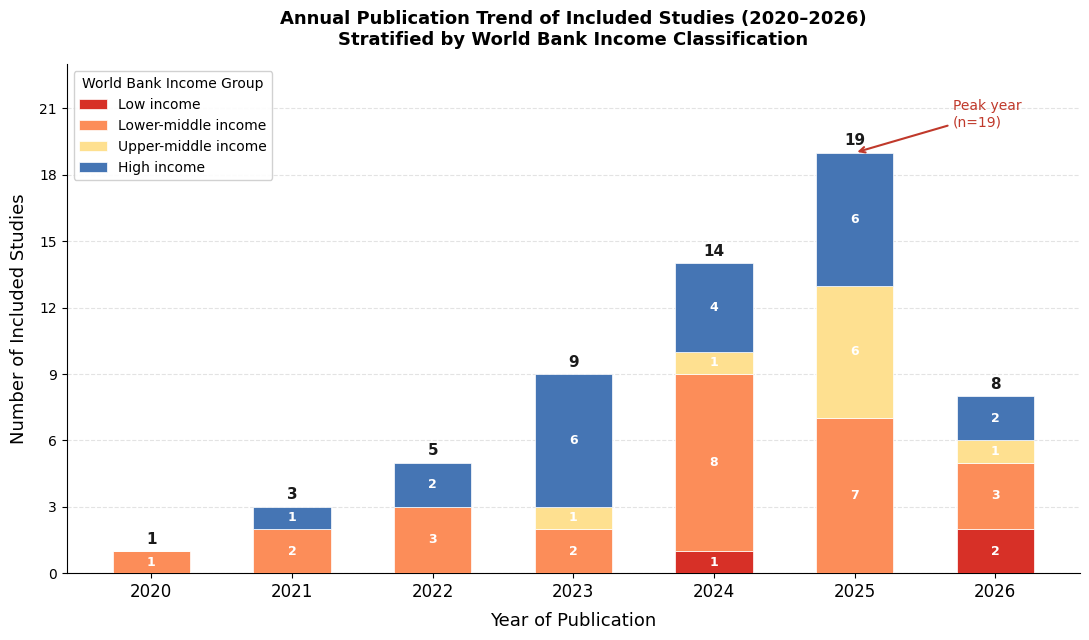

Saved: fig1_publication_trend.pdf


In [ ]:
# CELL 7 — Figure 1: Publication Trend by Income Group

fig1_data = df.groupby(['Year of publication', 'Income_clean']).size().unstack(fill_value=0)

# Ensure consistent column order
income_order = ['Low income', 'Lower-middle income', 'Upper-middle income', 'High income']
for col in income_order:
    if col not in fig1_data.columns:
        fig1_data[col] = 0
fig1_data = fig1_data[income_order].sort_index()

years  = fig1_data.index.tolist()
x      = np.arange(len(years))
w      = 0.55
colors = ['#d73027', '#fc8d59', '#fee090', '#4575b4']  # red→orange→yellow→blue

fig, ax = plt.subplots(figsize=(11, 6.5))

bottoms = np.zeros(len(years))
bars    = []
for col, color in zip(income_order, colors):
    vals = fig1_data[col].values
    b    = ax.bar(x, vals, width=w, bottom=bottoms, color=color,
                  label=col, zorder=3, edgecolor='white', linewidth=0.5)
    bars.append((vals, bottoms.copy()))
    # value labels inside segments (only if segment ≥ 1)
    for xi, v, bot in zip(x, vals, bottoms):
        if v >= 1:
            ax.text(xi, bot + v / 2, str(int(v)),
                    ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white')
    bottoms += vals

# Total labels on top of each bar
totals = fig1_data.sum(axis=1).values
for xi, tot in zip(x, totals):
    ax.text(xi, tot + 0.2, str(int(tot)),
            ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#1a1a1a')

# Annotation
peak_idx = np.argmax(totals)
ax.annotate('Peak year\n(n=%d)' % int(totals[peak_idx]),
            xy=(x[peak_idx], totals[peak_idx]),
            xytext=(x[peak_idx] + 0.7, totals[peak_idx] + 1.2),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
            fontsize=10, color='#c0392b')

ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=12)
ax.set_xlabel('Year of Publication', fontsize=13, labelpad=8)
ax.set_ylabel('Number of Included Studies', fontsize=13, labelpad=8)
ax.set_title('Annual Publication Trend of Included Studies (2020–2026)\nStratified by World Bank Income Classification',
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylim(0, max(totals) + 4)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

ax.legend(title='World Bank Income Group', fontsize=10, title_fontsize=10,
          loc='upper left', framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/SLR FNN/fig1_publication_trend.pdf',
    dpi=1200,
    bbox_inches='tight',
    format='pdf'
)
plt.show()
print("Saved: fig1_publication_trend.pdf")

In [ ]:
# CELL 8 — Install Dependencies for Map
!pip install geopandas mapclassify -q

## CELL 9 — Figure 2: World Choropleth Map

In [ ]:
# CELL 9 FIXED — Figure 2: Geographic Distribution World Map

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Download Natural Earth shapefile directly ─────────────────────────────────
import requests, zipfile, io, os

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
r   = requests.get(url)
z   = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall('/tmp/ne_countries')
world = gpd.read_file('/tmp/ne_countries/ne_110m_admin_0_countries.shp')

print("Shapefile loaded. Columns:", [c for c in world.columns if 'NAME' in c.upper()])
print("Sample names:", world['NAME'].head(10).tolist())

Shapefile loaded. Columns: ['NAME', 'NAME_LONG', 'BRK_NAME', 'NAME_CIAWF', 'NAME_SORT', 'NAME_ALT', 'NAME_LEN', 'NAME_AR', 'NAME_BN', 'NAME_DE', 'NAME_EN', 'NAME_ES', 'NAME_FA', 'NAME_FR', 'NAME_EL', 'NAME_HE', 'NAME_HI', 'NAME_HU', 'NAME_ID', 'NAME_IT', 'NAME_JA', 'NAME_KO', 'NAME_NL', 'NAME_PL', 'NAME_PT', 'NAME_RU', 'NAME_SV', 'NAME_TR', 'NAME_UK', 'NAME_UR', 'NAME_VI', 'NAME_ZH', 'NAME_ZHT']
Sample names: ['Fiji', 'Tanzania', 'W. Sahara', 'Canada', 'United States of America', 'Kazakhstan', 'Uzbekistan', 'Papua New Guinea', 'Indonesia', 'Argentina']


## CELL 10 — Figure 2: World Choropleth Map (Full Code)

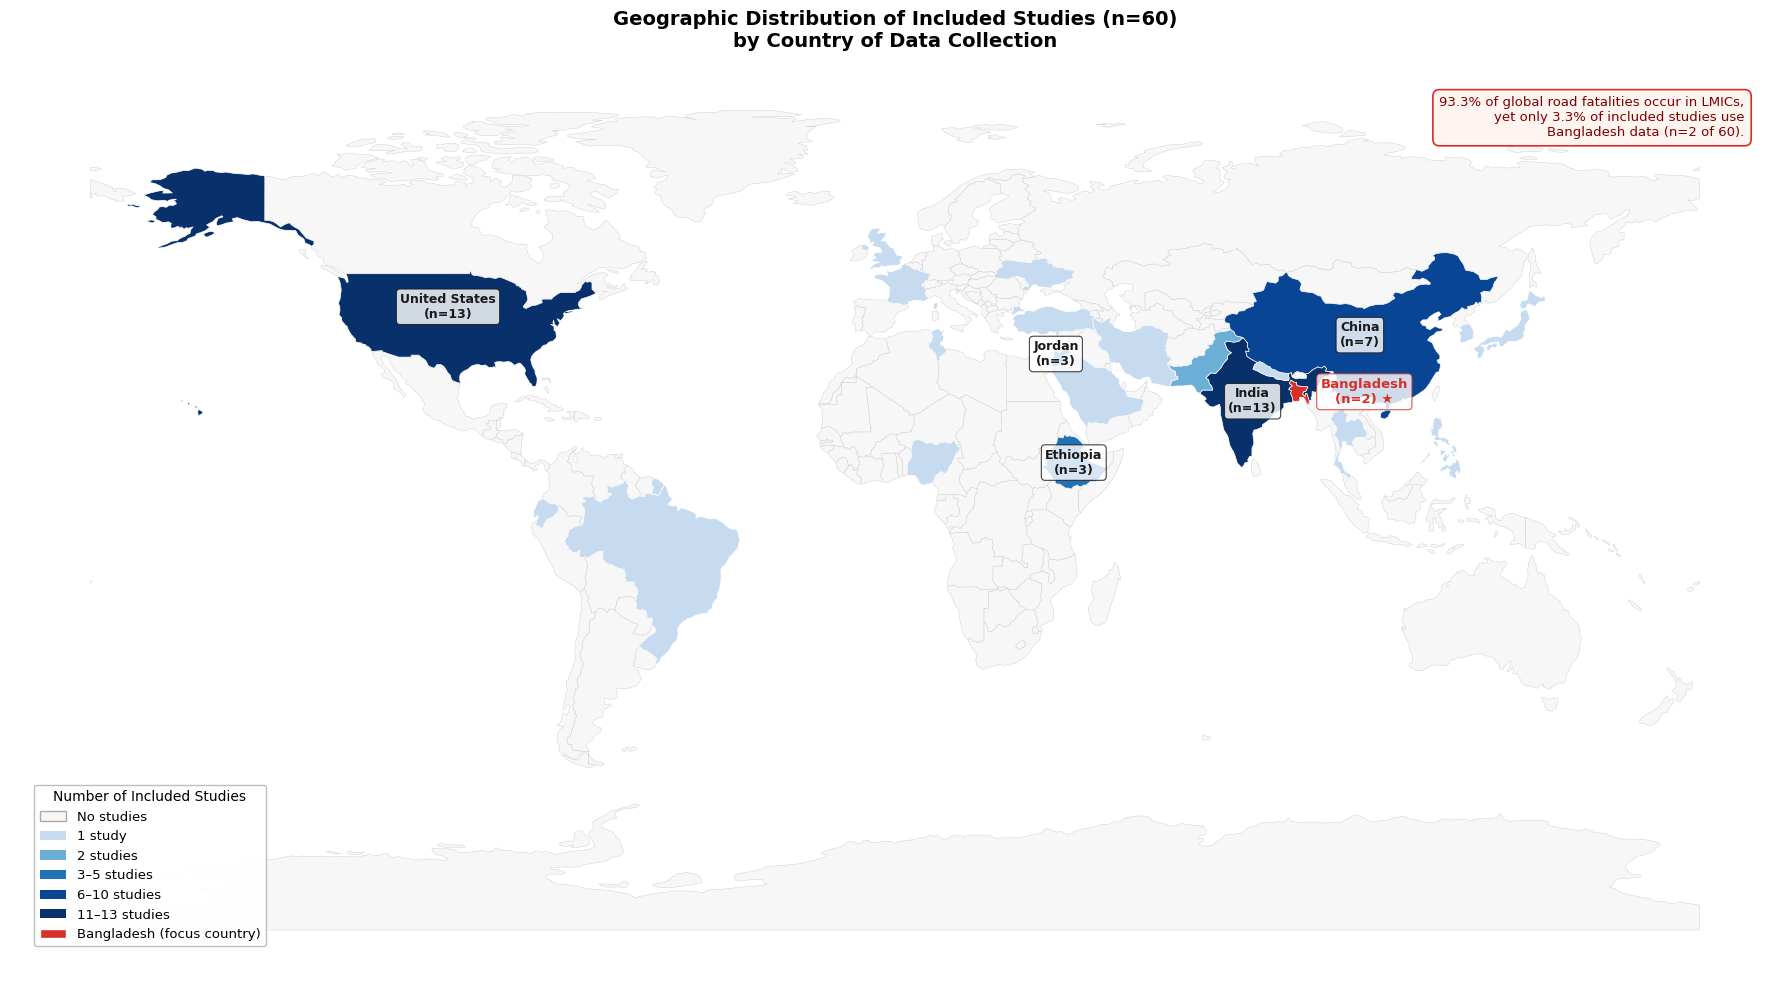

Saved: fig2_world_map.pdf


In [ ]:
# CELL 10 — Figure 2: Geographic Distribution World Map

# ── Country study counts ──────────────────────────────────────────────────────
country_counts = df['Country_clean'].value_counts().reset_index()
country_counts.columns = ['Country_clean', 'count']

# ── Map to Natural Earth NAME field ──────────────────────────────────────────
name_map = {
    'United States':  'United States of America',
    'United Kingdom': 'United Kingdom',
    'South Korea':    'South Korea',
    'Türkiye':        'Turkey',
    'Iran':           'Iran',
    'Brazil':         'Brazil',
    'Ecuador':        'Ecuador',
    'France':         'France',
    'Japan':          'Japan',
    'Nepal':          'Nepal',
    'Nigeria':        'Nigeria',
    'Philippines':    'Philippines',
    'Thailand':       'Thailand',
    'Tunisia':        'Tunisia',
    'Ukraine':        'Ukraine',
    'Pakistan':       'Pakistan',
    'Jordan':         'Jordan',
    'Ethiopia':       'Ethiopia',
    'Bangladesh':     'Bangladesh',
    'India':          'India',
    'China':          'China',
    'Saudi Arabia':   'Saudi Arabia',
    'Multi-country':  None,
    'Not Reported':   None,
}

country_counts['ne_name'] = country_counts['Country_clean'].apply(
    lambda x: name_map.get(x, x))
country_counts = country_counts[country_counts['ne_name'].notna()]

# ── Merge with shapefile ──────────────────────────────────────────────────────
world_merged = world.merge(
    country_counts[['ne_name', 'count']],
    left_on='NAME', right_on='ne_name', how='left')
world_merged['count'] = world_merged['count'].fillna(0)

# ── Color function ────────────────────────────────────────────────────────────
def get_color(count):
    if count == 0:    return '#f7f7f7'
    if count == 1:    return '#c6dbef'
    if count == 2:    return '#6baed6'
    if count <= 5:    return '#2171b5'
    if count <= 10:   return '#084594'
    return                   '#08306b'

world_merged['map_color'] = world_merged['count'].apply(get_color)

# ── Bangladesh gets a distinct highlight color ────────────────────────────────
BGD_COLOR = '#d73027'
world_merged.loc[world_merged['NAME'] == 'Bangladesh', 'map_color'] = BGD_COLOR

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('white')

# No-study countries
world_merged[world_merged['count'] == 0].plot(
    ax=ax, color='#f7f7f7', edgecolor='#cccccc', linewidth=0.3)

# Study countries (Bangladesh overridden by map_color)
world_merged[world_merged['count'] > 0].plot(
    ax=ax,
    color=world_merged[world_merged['count'] > 0]['map_color'].tolist(),
    edgecolor='#ffffff', linewidth=0.5)

# ── Country annotation labels (top contributors + Bangladesh) ─────────────────
labels = {
    'United States of America': (-100, 42,  'United States\n(n=13)'),
    'India':                    (80,   22,  'India\n(n=13)'),
    'China':                    (104,  36,  'China\n(n=7)'),
    'Jordan':                   (36,   32,  'Jordan\n(n=3)'),
    'Ethiopia':                 (40,    9,  'Ethiopia\n(n=3)'),
    'Bangladesh':               (105,  24,  'Bangladesh\n(n=2) ★'),
}

for ne_name, (lon, lat, label) in labels.items():
    is_bgd  = (ne_name == 'Bangladesh')
    color   = BGD_COLOR if is_bgd else '#1a1a1a'
    fw      = 'bold'
    fsize   = 9 if not is_bgd else 9.5
    ax.text(lon, lat, label,
            fontsize=fsize, ha='center', va='center',
            color=color, fontweight=fw,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      alpha=0.82, edgecolor=color, linewidth=0.8))

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor='#f7f7f7', edgecolor='#aaaaaa', label='No studies'),
    mpatches.Patch(facecolor='#c6dbef', label='1 study'),
    mpatches.Patch(facecolor='#6baed6', label='2 studies'),
    mpatches.Patch(facecolor='#2171b5', label='3–5 studies'),
    mpatches.Patch(facecolor='#084594', label='6–10 studies'),
    mpatches.Patch(facecolor='#08306b', label='11–13 studies'),
    mpatches.Patch(facecolor=BGD_COLOR, label='Bangladesh (focus country)',
                   edgecolor='white'),
]
ax.legend(handles=legend_elements,
          title='Number of Included Studies',
          title_fontsize=10, fontsize=9.5,
          loc='lower left', framealpha=0.95,
          edgecolor='#bbbbbb',
          bbox_to_anchor=(0.01, 0.02))

# ── Gap annotation box ────────────────────────────────────────────────────────
ax.text(0.98, 0.97,
        '93.3% of global road fatalities occur in LMICs,\n'
        'yet only 3.3% of included studies use\n'
        'Bangladesh data (n=2 of 60).',
        transform=ax.transAxes,
        fontsize=9.5, va='top', ha='right', color='#7f0000',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff5f0',
                  edgecolor='#d73027', linewidth=1.2))

ax.set_title(
    'Geographic Distribution of Included Studies (n=60)\n'
    'by Country of Data Collection',
    fontsize=14, fontweight='bold', pad=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SLR FNN/fig2_world_map.pdf', dpi=1200, bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig2_world_map.pdf")

## CELL 11 — Figure 3: Algorithm Category Distribution (Donut Chart)

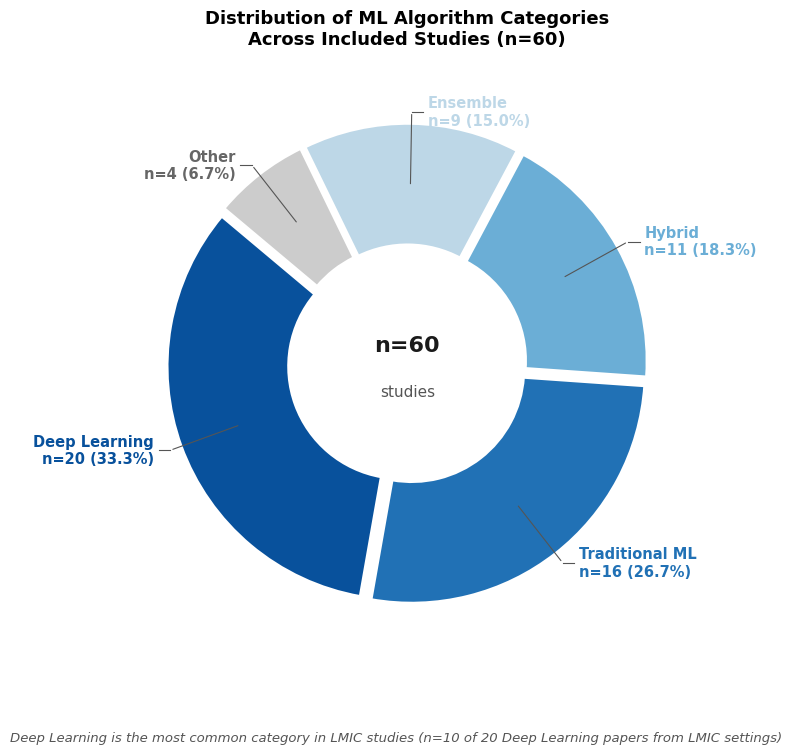

Saved: fig3_algo_category_donut.pdf


In [ ]:
# CELL 11 FIXED — Figure 3: Algorithm Category Distribution (Donut Chart)

import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
algo_counts = df['AlgoCat_clean'].value_counts()
order   = ['Deep Learning', 'Traditional ML', 'Hybrid', 'Ensemble', 'Other']
counts  = [algo_counts.get(k, 0) for k in order]
total   = sum(counts)
pcts    = [c / total * 100 for c in counts]
colors  = ['#08519c', '#2171b5', '#6baed6', '#bdd7e7', '#cccccc']
explode = [0.03, 0.03, 0.03, 0.03, 0.03]

# ── Figure — extra bottom space for annotation ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
fig.subplots_adjust(bottom=0.15)

wedges, _ = ax.pie(
    counts,
    explode=explode,
    colors=colors,
    startangle=140,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2),
)

# ── Leader lines + outside labels ────────────────────────────────────────────
for i, wedge in enumerate(wedges):
    theta  = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
    x_mid  = np.cos(theta)
    y_mid  = np.sin(theta)

    x0, y0 = 0.76 * x_mid, 0.76 * y_mid
    x1, y1 = 1.08 * x_mid, 1.08 * y_mid
    x2      = x1 + (0.05 if x_mid > 0 else -0.05)

    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='-', color='#555555', lw=0.8))
    ax.plot([x1, x2], [y1, y1], color='#555555', lw=0.8)

    label_x = x2 + (0.02 if x_mid > 0 else -0.02)
    ax.text(label_x, y1,
            f"{order[i]}\nn={counts[i]} ({pcts[i]:.1f}%)",
            ha='left' if x_mid > 0 else 'right',
            va='center', fontsize=10.5, fontweight='bold',
            color=colors[i] if order[i] != 'Other' else '#666666')

# ── Centre text (n=60 only, no sub-annotation inside) ────────────────────────
ax.text(0, 0.08, 'n=60',   ha='center', va='center',
        fontsize=16, fontweight='bold', color='#1a1a1a')
ax.text(0, -0.12, 'studies', ha='center', va='center',
        fontsize=11, color='#555555')

# ── LMIC annotation BELOW the figure in fig.text ─────────────────────────────
lmic_dl = df[df['Is_LMIC'] == 'LMIC']['AlgoCat_clean'].value_counts().get('Deep Learning', 0)
fig.text(0.5, 0.04,
         f'Deep Learning is the most common category in LMIC studies '
         f'(n={lmic_dl} of {counts[0]} Deep Learning papers from LMIC settings)',
         ha='center', va='bottom', fontsize=9.5,
         style='italic', color='#555555')

ax.set_title('Distribution of ML Algorithm Categories\nAcross Included Studies (n=60)',
             fontsize=13, fontweight='bold', pad=20)

plt.savefig('/content/drive/MyDrive/SLR FNN/fig3_algo_category_donut.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig3_algo_category_donut.pdf")

## CELL 12 — Inspect Algorithm Free-Text Column First

In [ ]:
# CELL 1B — Set Output Directory
import os

SAVE_DIR = '/content/drive/MyDrive/SLR FNN'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Output directory ready: {SAVE_DIR}")

Output directory ready: /content/drive/MyDrive/SLR FNN


In [ ]:
# CELL 12 — Inspect raw algorithm text before parsing

for i, val in enumerate(df['ML algorithm or algorithms used '].values):
    print(f"[{i+1}] {str(val)[:150]}")
    print()

[1] ML algorithm or algorithms used: Attention-augmented LSTM (CV-Net) — two stacked LSTM layers with additive attention mechanism, batch normalisation, a

[2] Distance metric-based disruption segmentation algorithm using Chebyshev metric (selected as best performing from: Bray-Curtis, Canberra, Chebyshev, Ma

[3] ARIMA (Autoregressive Integrated Moving Average), BP (Backpropagation) Neural Network, and the hybrid ARIMA-BP model

[4] Artificial Neural Network (ANN), ARIMA, and Multiple Linear Regression

[5] Random Forest (RF).

[6] SVSNet (improved STGCN), CNN, GRU, GCN, and attention mechanism

[7] Spatiotemporal Combinatorial Attention Graph Neural Network (STCAGNN).

[8] Random Forest, AdaBoost (Boosted Tree), Decision Tree, and Association Rules (Apriori algorithm).

[9] Decision Trees (DT), Random Forests (RF), Light Gradient Boosting Machines (LGBM), Extra Trees (ET), Bagging Classifiers, and Gradient Boosting (GB)

[10] Latent Gaussian Process with Tree-Boosting Model (LGPBoost

## CELL 13 — Figure 4: Top Individual Algorithms (Horizontal Bar)

In [ ]:
# CELL 13 — Figure 4: Top Individual Algorithms Used Across Studies

from collections import defaultdict

# ── Keyword → canonical algorithm name ───────────────────────────────────────
algo_keywords = {
    'Random Forest':        ['random forest', 'rf)', 'rf,', 'rf.', '(rf)'],
    'XGBoost':              ['xgboost', 'xgb)', 'xgb,', 'extreme gradient boosting'],
    'LSTM':                 ['lstm', 'long short-term memory', 'bilstm', 'bi-lstm'],
    'CNN':                  ['convolutional neural network', 'cnn', 'crackite', 'vgg', 'resnet',
                             'mobilenet', 'densenet', 'inception'],
    'GRU':                  ['gru', 'gated recurrent unit'],
    'SVM':                  ['support vector machine', 'svm', 'gw-svm'],
    'Decision Tree':        ['decision tree', ' dt)', ' dt,', 'j48'],
    'GNN / GCN':            ['graph neural', 'gnn', 'gcn', 'graph attention',
                             'graph network', 'graph model', 'stgcn', 'stcagnn',
                             'hypergraph', 'diffg', 'raspnet', 'multidiffusion',
                             'heterogeneous graph', 'glst'],
    'Gradient Boosting':    ['gradient boost', 'gbdt', 'gbm', 'lightgbm', 'lgbm',
                             'light gradient'],
    'ANN / MLP':            ['artificial neural network', 'ann', 'multilayer perceptron',
                             'mlp', 'neural network', 'deep neural'],
    'Transformer':          ['transformer', 'timesformer', 'vivit', 'vit', 'bert',
                             'llm', 'llava', 'clip', 'adaptive-sparse-vit',
                             'temporal segment network', 'tsn'],
    'AdaBoost':             ['adaboost', 'boosted tree'],
    'KNN':                  ['k-nearest', 'knn'],
    'Logistic Regression':  ['logistic regression'],
    'ARIMA / SARIMA':       ['arima', 'sarima', 'autoregressive integrated'],
    'Naive Bayes':          ['naïve bayes', 'naive bayes'],
    'k-means':              ['k-means', 'kmeans'],
    'DBSCAN':               ['dbscan'],
    'Random Forest + SHAP': [],   # will handle separately
}

# ── Count: one paper can mention multiple algorithms ──────────────────────────
algo_paper_count = defaultdict(int)

for raw in df['ML algorithm or algorithms used ']:
    if pd.isna(raw): continue
    rl   = str(raw).lower()
    seen = set()
    for algo, keywords in algo_keywords.items():
        if algo == 'Random Forest + SHAP': continue
        for kw in keywords:
            if kw in rl and algo not in seen:
                algo_paper_count[algo] += 1
                seen.add(algo)
                break

# ── Sort and keep top 15 ──────────────────────────────────────────────────────
algo_df = pd.DataFrame(list(algo_paper_count.items()),
                       columns=['Algorithm', 'Papers'])
algo_df = algo_df.sort_values('Papers', ascending=True).tail(15)

print("Algorithm counts:")
print(algo_df.sort_values('Papers', ascending=False).to_string(index=False))

Algorithm counts:
          Algorithm  Papers
      Random Forest      18
          ANN / MLP      13
                CNN      12
      Decision Tree      10
            XGBoost      10
               LSTM       9
                SVM       9
          GNN / GCN       8
  Gradient Boosting       8
                GRU       6
        Transformer       6
Logistic Regression       6
     ARIMA / SARIMA       5
            k-means       3
           AdaBoost       2


## CELL 14 — Figure 4: Top Individual Algorithms Horizontal Bar

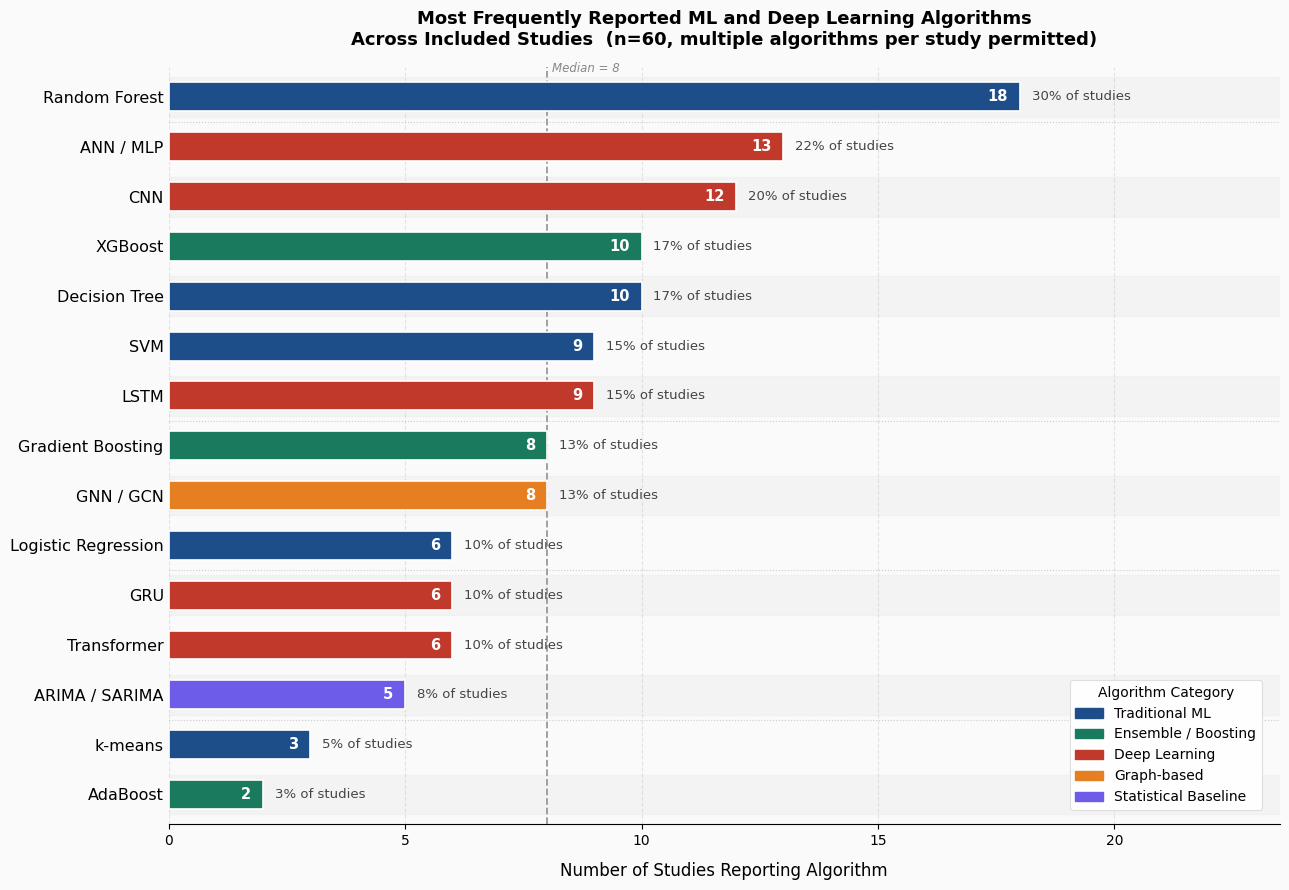

Saved: fig4_top_algorithms.pdf


In [ ]:
# CELL 14 FIXED — Figure 4: Top Individual Algorithms Horizontal Bar

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
algorithms = algo_df['Algorithm'].tolist()
counts     = algo_df['Papers'].tolist()
total_pap  = len(df)

# ── Distinct color per category — no overlap ──────────────────────────────────
cat_color_map = {
    # Traditional ML → steel blue family
    'Random Forest':      '#1d4e89',
    'Decision Tree':      '#1d4e89',
    'SVM':                '#1d4e89',
    'Logistic Regression':'#1d4e89',
    'k-means':            '#1d4e89',
    # Ensemble / Boosting → teal/green family
    'AdaBoost':           '#1a7a5e',
    'Gradient Boosting':  '#1a7a5e',
    'XGBoost':            '#1a7a5e',
    # Deep Learning → crimson/coral family
    'LSTM':               '#c0392b',
    'CNN':                '#c0392b',
    'GRU':                '#c0392b',
    'ANN / MLP':          '#c0392b',
    'Transformer':        '#c0392b',
    # Graph-based → amber/orange
    'GNN / GCN':          '#e67e22',
    # Statistical Baseline → slate purple
    'ARIMA / SARIMA':     '#6c5ce7',
}

bar_colors = [cat_color_map.get(a, '#aaaaaa') for a in algorithms]

# ── Category legend patches ───────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color='#1d4e89', label='Traditional ML'),
    mpatches.Patch(color='#1a7a5e', label='Ensemble / Boosting'),
    mpatches.Patch(color='#c0392b', label='Deep Learning'),
    mpatches.Patch(color='#e67e22', label='Graph-based'),
    mpatches.Patch(color='#6c5ce7', label='Statistical Baseline'),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

y    = np.arange(len(algorithms))
bars = ax.barh(y, counts, color=bar_colors, height=0.58,
               edgecolor='white', linewidth=0.8, zorder=3)

# ── Subtle gradient effect — darker edge on each bar ─────────────────────────
for bar, color in zip(bars, bar_colors):
    bar.set_linewidth(1.2)
    bar.set_edgecolor('white')

# ── Value labels ──────────────────────────────────────────────────────────────
for bar, count in zip(bars, counts):
    pct = count / total_pap * 100
    # small count label inside bar (right-aligned)
    ax.text(bar.get_width() - 0.25,
            bar.get_y() + bar.get_height() / 2,
            f'{count}',
            va='center', ha='right', fontsize=10.5,
            fontweight='bold', color='white', zorder=4)
    # percentage label outside bar
    ax.text(bar.get_width() + 0.25,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.0f}% of studies',
            va='center', ha='left', fontsize=9.5, color='#444444')

# ── Median reference line ─────────────────────────────────────────────────────
median_val = np.median(counts)
ax.axvline(median_val, color='#999999', linestyle='--',
           linewidth=1.3, zorder=2)
ax.text(median_val + 0.1, len(algorithms) - 0.3,
        f'Median = {int(median_val)}',
        fontsize=8.5, color='#888888', va='top', style='italic')

# ── Light horizontal band every other bar for readability ────────────────────
for i in range(0, len(algorithms), 2):
    ax.axhspan(i - 0.4, i + 0.4, color='#e8e8e8', alpha=0.35, zorder=0)

# ── Category divider lines on y-axis ─────────────────────────────────────────
# Between ARIMA (idx 0) and k-means (idx 1): between stat and trad ML
dividers = [1.5, 4.5, 7.5, 13.5]   # adjust based on sort order
for d in dividers:
    ax.axhline(d, color='#cccccc', linewidth=0.8, linestyle=':', zorder=1)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_yticks(y)
ax.set_yticklabels(algorithms, fontsize=11.5, fontweight='normal')
ax.set_xlabel('Number of Studies Reporting Algorithm',
              fontsize=12, labelpad=10)
ax.set_xlim(0, max(counts) + 5.5)
ax.set_ylim(-0.6, len(algorithms) - 0.4)
ax.set_title(
    'Most Frequently Reported ML and Deep Learning Algorithms\n'
    'Across Included Studies  (n=60, multiple algorithms per study permitted)',
    fontsize=13, fontweight='bold', pad=16)

ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

# ── Legend ────────────────────────────────────────────────────────────────────
leg = ax.legend(handles=legend_elements,
                title='Algorithm Category', title_fontsize=10,
                fontsize=10, loc='lower right',
                framealpha=0.95, edgecolor='#dddddd',
                bbox_to_anchor=(0.99, 0.01))
leg.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig4_top_algorithms.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig4_top_algorithms.pdf")

## CELL 15 — Figure 5: Algorithm Category × Income Group Heatmap


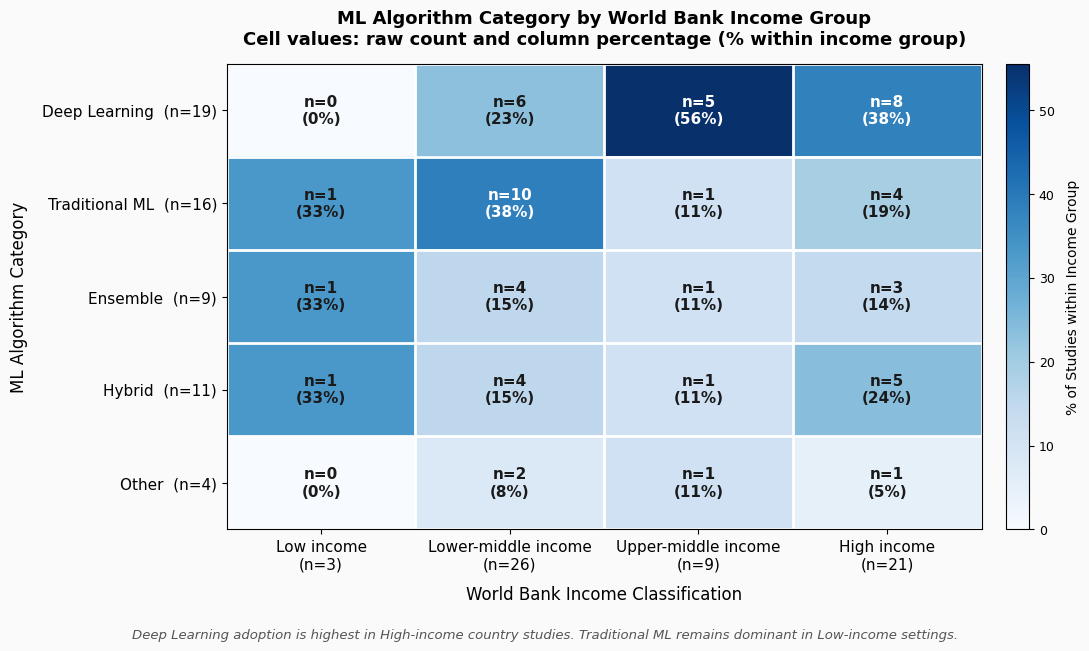

Saved: fig5_algo_income_heatmap.pdf


In [ ]:
# CELL 15 — Figure 5: Algorithm Category × Income Group Heatmap

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ── Crosstab ──────────────────────────────────────────────────────────────────
income_order = ['Low income', 'Lower-middle income',
                'Upper-middle income', 'High income']
algo_order   = ['Deep Learning', 'Traditional ML',
                'Ensemble', 'Hybrid', 'Other']

ct = pd.crosstab(df['AlgoCat_clean'], df['Income_clean'])

# Reindex to ensure consistent order, fill missing with 0
ct = ct.reindex(index=algo_order,
                columns=income_order,
                fill_value=0)

# Row and column totals for annotation
row_totals = ct.sum(axis=1).values
col_totals = ct.sum(axis=0).values

# ── Normalise by column (% within each income group) for color intensity ──────
ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor('#fafafa')

cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=ct_pct.values.max())

im = ax.imshow(ct_pct.values, cmap=cmap, norm=norm, aspect='auto')

# ── Cell annotations: raw count + percentage ─────────────────────────────────
for i in range(len(algo_order)):
    for j in range(len(income_order)):
        raw = ct.values[i, j]
        pct = ct_pct.values[i, j]
        # choose white or dark text based on background intensity
        text_color = 'white' if pct > 35 else '#1a1a1a'
        ax.text(j, i,
                f'n={raw}\n({pct:.0f}%)',
                ha='center', va='center',
                fontsize=11, fontweight='bold',
                color=text_color)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(range(len(income_order)))
ax.set_xticklabels(
    [f'{c}\n(n={col_totals[j]})' for j, c in enumerate(income_order)],
    fontsize=11)

ax.set_yticks(range(len(algo_order)))
ax.set_yticklabels(
    [f'{r}  (n={row_totals[i]})' for i, r in enumerate(algo_order)],
    fontsize=11)

ax.set_xlabel('World Bank Income Classification', fontsize=12, labelpad=10)
ax.set_ylabel('ML Algorithm Category', fontsize=12, labelpad=10)
ax.set_title(
    'ML Algorithm Category by World Bank Income Group\n'
    'Cell values: raw count and column percentage (% within income group)',
    fontsize=13, fontweight='bold', pad=14)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
cbar.set_label('% of Studies within Income Group',
               fontsize=10, labelpad=8)
cbar.ax.tick_params(labelsize=9)

# ── Grid lines between cells ──────────────────────────────────────────────────
ax.set_xticks(np.arange(-0.5, len(income_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(algo_order),   1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', length=0)

# ── Key insight annotation ────────────────────────────────────────────────────
fig.text(0.5, 0.01,
         'Deep Learning adoption is highest in High-income country studies. '
         'Traditional ML remains dominant in Low-income settings.',
         ha='center', fontsize=9.5, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{SAVE_DIR}/fig5_algo_income_heatmap.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig5_algo_income_heatmap.pdf")

## CELL 16 — Figure 6: Spatiotemporal Framework Distribution

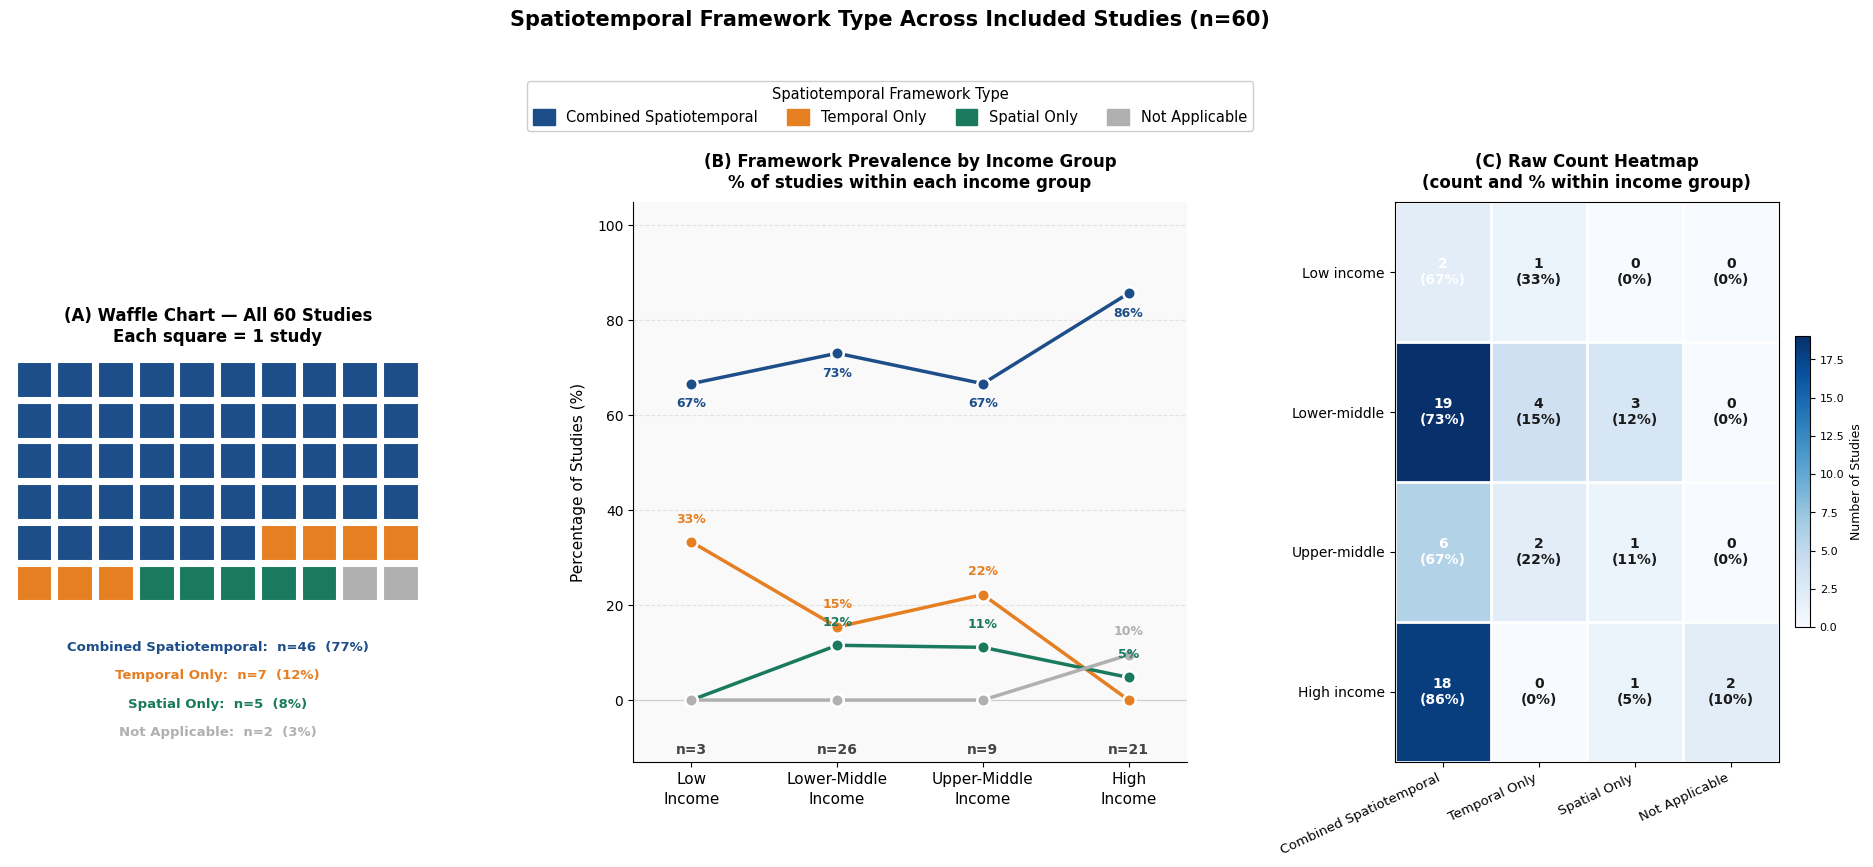

Saved: fig6_spatiotemporal_framework.pdf


In [ ]:
# CELL 16 COMPLETE REDESIGN — Figure 6: Waffle Matrix + Slope Chart

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

st_keys         = ['Combined Spatiotemporal', 'Temporal Only',
                   'Spatial Only', 'Not Applicable']
st_labels_short = ['Combined\nSpatiotemporal', 'Temporal\nOnly',
                   'Spatial\nOnly', 'Not\nApplicable']
income_keys     = ['Low income', 'Lower-middle income',
                   'Upper-middle income', 'High income']
income_short    = ['Low\nIncome', 'Lower-Middle\nIncome',
                   'Upper-Middle\nIncome', 'High\nIncome']
colors          = ['#1d4e89', '#e67e22', '#1a7a5e', '#b0b0b0']

ct     = pd.crosstab(df['Income_clean'], df['STFramework_clean'])
ct     = ct.reindex(index=income_keys, columns=st_keys, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

overall  = df['STFramework_clean'].value_counts()
ov_vals  = [overall.get(k, 0) for k in st_keys]
ov_total = sum(ov_vals)

# ── Figure layout: 3 panels ───────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 8))
fig.patch.set_facecolor('#ffffff')
gs = gridspec.GridSpec(1, 3, width_ratios=[1.2, 1.6, 1.2],
                       wspace=0.45, left=0.06, right=0.96,
                       top=0.82, bottom=0.12)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — Waffle chart (10×6 grid = 60 squares = 60 papers)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#ffffff')
ax1.set_aspect('equal')

cols_w, rows_w = 10, 6
squares = []
for st_key, color in zip(st_keys, colors):
    squares.extend([color] * overall.get(st_key, 0))

pad = 0.12
sq  = 1.0 - pad

for idx, color in enumerate(squares):
    row = idx // cols_w
    col = idx  % cols_w
    x0  = col * 1.0 + pad / 2
    y0  = (rows_w - 1 - row) * 1.0 + pad / 2
    rect = plt.Rectangle((x0, y0), sq, sq,
                          facecolor=color, edgecolor='white',
                          linewidth=1.5, zorder=3)
    ax1.add_patch(rect)

ax1.set_xlim(-0.1, cols_w + 0.1)
ax1.set_ylim(-0.1, rows_w + 0.1)
ax1.axis('off')
ax1.set_title('(A) Waffle Chart — All 60 Studies\nEach square = 1 study',
              fontsize=12, fontweight='bold', pad=10)

# Count + pct labels beside waffle
label_y = rows_w + 0.3
for i, (st_key, color) in enumerate(zip(st_keys, colors)):
    n   = overall.get(st_key, 0)
    pct = n / ov_total * 100
    ax1.text(cols_w / 2, -0.9 - i * 0.7,
             f'{st_labels_short[i].replace(chr(10)," ")}:  '
             f'n={n}  ({pct:.0f}%)',
             ha='center', va='top',
             fontsize=9.5, color=color, fontweight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — Slope chart: % Combined Spatiotemporal across income groups
#            with all 4 frameworks as separate lines
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#f9f9f9')

x_pos = np.arange(len(income_keys))

for st_key, color, label in zip(st_keys, colors, st_labels_short):
    vals = ct_pct[st_key].values
    # line
    ax2.plot(x_pos, vals, color=color, lw=2.5,
             marker='o', markersize=9,
             markerfacecolor=color, markeredgecolor='white',
             markeredgewidth=1.8, zorder=3,
             label=label.replace('\n', ' '))
    # value labels — offset alternately above/below
    for xi, v in zip(x_pos, vals):
        if v >= 3:
            offset = 3.5 if v < 50 else -5.5
            ax2.text(xi, v + offset,
                     f'{v:.0f}%',
                     ha='center', va='bottom',
                     fontsize=9, fontweight='bold',
                     color=color, zorder=4)

# n= below x axis
for xi, tot in zip(x_pos, ct.sum(axis=1).values):
    ax2.text(xi, -9, f'n={tot}',
             ha='center', va='top',
             fontsize=10, color='#444444', fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(income_short, fontsize=11, linespacing=1.4)
ax2.set_ylabel('Percentage of Studies (%)', fontsize=11, labelpad=8)
ax2.set_ylim(-13, 105)
ax2.set_xlim(-0.4, len(income_keys) - 0.6)
ax2.set_title('(B) Framework Prevalence by Income Group\n% of studies within each income group',
              fontsize=12, fontweight='bold', pad=10)
ax2.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.axhline(0, color='#cccccc', lw=0.8)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C — Heatmap: raw counts, income × framework
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor('#ffffff')

data_matrix = ct.values.astype(float)

im = ax3.imshow(data_matrix, cmap='Blues',
                aspect='auto',
                vmin=0, vmax=data_matrix.max())

for i in range(len(income_keys)):
    for j in range(len(st_keys)):
        val = int(data_matrix[i, j])
        pct = ct_pct.values[i, j]
        tc  = 'white' if pct > 40 else '#1a1a1a'
        ax3.text(j, i, f'{val}\n({pct:.0f}%)',
                 ha='center', va='center',
                 fontsize=10, fontweight='bold', color=tc)

ax3.set_xticks(range(len(st_keys)))
ax3.set_xticklabels([l.replace('\n', ' ') for l in st_labels_short],
                    fontsize=9.5, rotation=25, ha='right')
ax3.set_yticks(range(len(income_keys)))
ax3.set_yticklabels(['Low income', 'Lower-middle', 'Upper-middle', 'High income'],
                    fontsize=10)
ax3.set_title('(C) Raw Count Heatmap\n(count and % within income group)',
              fontsize=12, fontweight='bold', pad=10)

# grid lines
ax3.set_xticks(np.arange(-0.5, len(st_keys),   1), minor=True)
ax3.set_yticks(np.arange(-0.5, len(income_keys), 1), minor=True)
ax3.grid(which='minor', color='white', linewidth=2)
ax3.tick_params(which='minor', length=0)

cbar = fig.colorbar(im, ax=ax3, fraction=0.035, pad=0.04)
cbar.set_label('Number of Studies', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# ── Legend horizontal at very top ────────────────────────────────────────────
legend_patches = [mpatches.Patch(color=c,
                                 label=l.replace('\n', ' '))
                  for c, l in zip(colors, st_labels_short)]
fig.legend(handles=legend_patches,
           title='Spatiotemporal Framework Type',
           title_fontsize=10.5, fontsize=10.5,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.98),
           ncol=4, framealpha=0.95,
           edgecolor='#cccccc',
           handlelength=1.5, handleheight=1.3,
           columnspacing=2.0)

fig.suptitle('Spatiotemporal Framework Type Across Included Studies (n=60)',
             fontsize=15, fontweight='bold', y=1.06)


plt.savefig(f'{SAVE_DIR}/fig6_spatiotemporal_framework.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig6_spatiotemporal_framework.pdf")

## CELL 17 — Figure 7: Spatial Methods Taxonomy


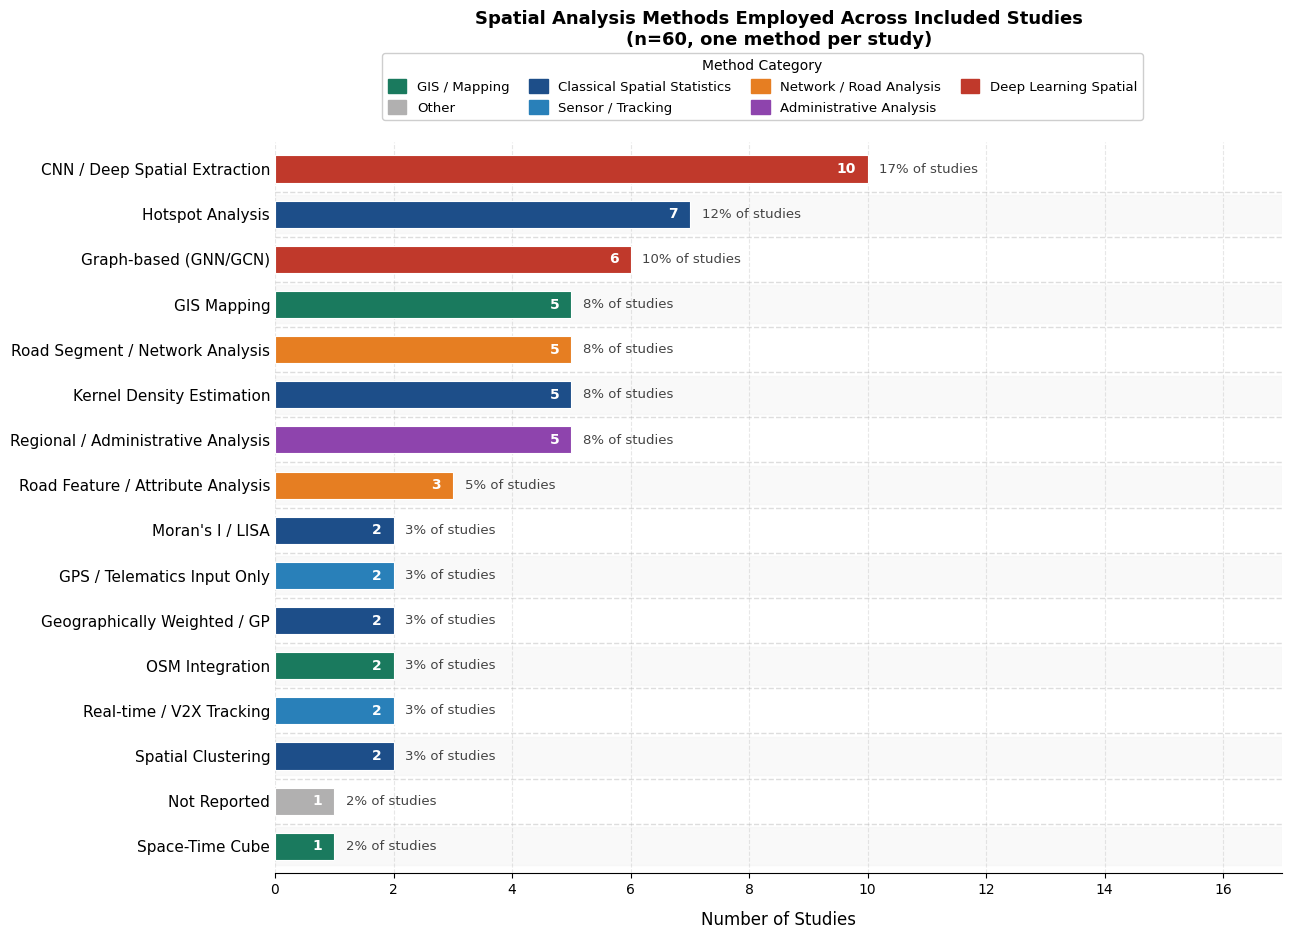

Saved: fig7_spatial_methods.pdf


In [ ]:
# CELL 17 LEGEND FIX — Figure 7: Spatial Methods with horizontal top legend

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Data ──────────────────────────────────────────────────────────────────────
spatial_counts = df['Spatial_bucket'].value_counts().reset_index()
spatial_counts.columns = ['Method', 'Count']
spatial_counts = spatial_counts.sort_values('Count', ascending=True)
total = len(df)

def method_category(m):
    if m in ['Graph-based (GNN/GCN)', 'CNN / Deep Spatial Extraction']:
        return 'Deep Learning Spatial'
    if m in ['Kernel Density Estimation', "Moran's I / LISA",
             'Hotspot Analysis', 'Spatial Clustering',
             'Geographically Weighted / GP']:
        return 'Classical Spatial Statistics'
    if m in ['GIS Mapping', 'OSM Integration', 'Space-Time Cube']:
        return 'GIS / Mapping'
    if m in ['Road Segment / Network Analysis',
             'Road Feature / Attribute Analysis']:
        return 'Network / Road Analysis'
    if m in ['Regional / Administrative Analysis']:
        return 'Administrative Analysis'
    if m in ['Real-time / V2X Tracking', 'GPS / Telematics Input Only']:
        return 'Sensor / Tracking'
    return 'Other'

spatial_counts['Category'] = spatial_counts['Method'].apply(method_category)

cat_colors = {
    'Deep Learning Spatial':        '#c0392b',
    'Classical Spatial Statistics': '#1d4e89',
    'GIS / Mapping':                '#1a7a5e',
    'Network / Road Analysis':      '#e67e22',
    'Administrative Analysis':      '#8e44ad',
    'Sensor / Tracking':            '#2980B9',  # ← FIXED
    'Other':                        '#b1b0b0',
}

bar_colors = [cat_colors[c] for c in spatial_counts['Category']]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9.5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

y    = np.arange(len(spatial_counts))
bars = ax.barh(y, spatial_counts['Count'].values,
               color=bar_colors, height=0.6,
               edgecolor='white', linewidth=0.8, zorder=3)

# Count inside + % outside
for bar, count in zip(bars, spatial_counts['Count'].values):
    pct = count / total * 100
    ax.text(bar.get_width() - 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{count}',
            ha='right', va='center',
            fontsize=10, fontweight='bold',
            color='white', zorder=4)
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.0f}% of studies',
            ha='left', va='center',
            fontsize=9.5, color='#444444')

# Zebra rows
for i in range(0, len(spatial_counts), 2):
    ax.axhspan(i - 0.42, i + 0.42, color='#f5f5f5', alpha=0.6, zorder=0)

# Category divider lines
prev = None
for i, c in enumerate(spatial_counts['Category'].values):
    if c != prev and i > 0:
        ax.axhline(i - 0.5, color='#dddddd', lw=1.0,
                   linestyle='--', zorder=1)
    prev = c

ax.set_yticks(y)
ax.set_yticklabels(spatial_counts['Method'].values, fontsize=11)
ax.set_xlabel('Number of Studies', fontsize=12, labelpad=10)
ax.set_xlim(0, spatial_counts['Count'].max() + 7)
ax.set_ylim(-0.6, len(spatial_counts) - 0.4)
ax.set_title('Spatial Analysis Methods Employed Across Included Studies\n'
             '(n=60, one method per study)',
             fontsize=13, fontweight='bold', pad=70)
ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

# ── Legend: horizontal at top of figure ───────────────────────────────────────
present_cats = list(dict.fromkeys(spatial_counts['Category'].values))
legend_patches = [mpatches.Patch(color=cat_colors[c], label=c)
                  for c in present_cats]
fig.legend(handles=legend_patches,
           title='Method Category',
           title_fontsize=10, fontsize=9.5,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.98),
           ncol=4,
           framealpha=0.95,
           edgecolor='#cccccc',
           handlelength=1.4, handleheight=1.2,
           columnspacing=1.5)



plt.savefig(f'{SAVE_DIR}/fig7_spatial_methods.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig7_spatial_methods.pdf")

## CELL 18 — Figure 8: Temporal Resolution Distribution

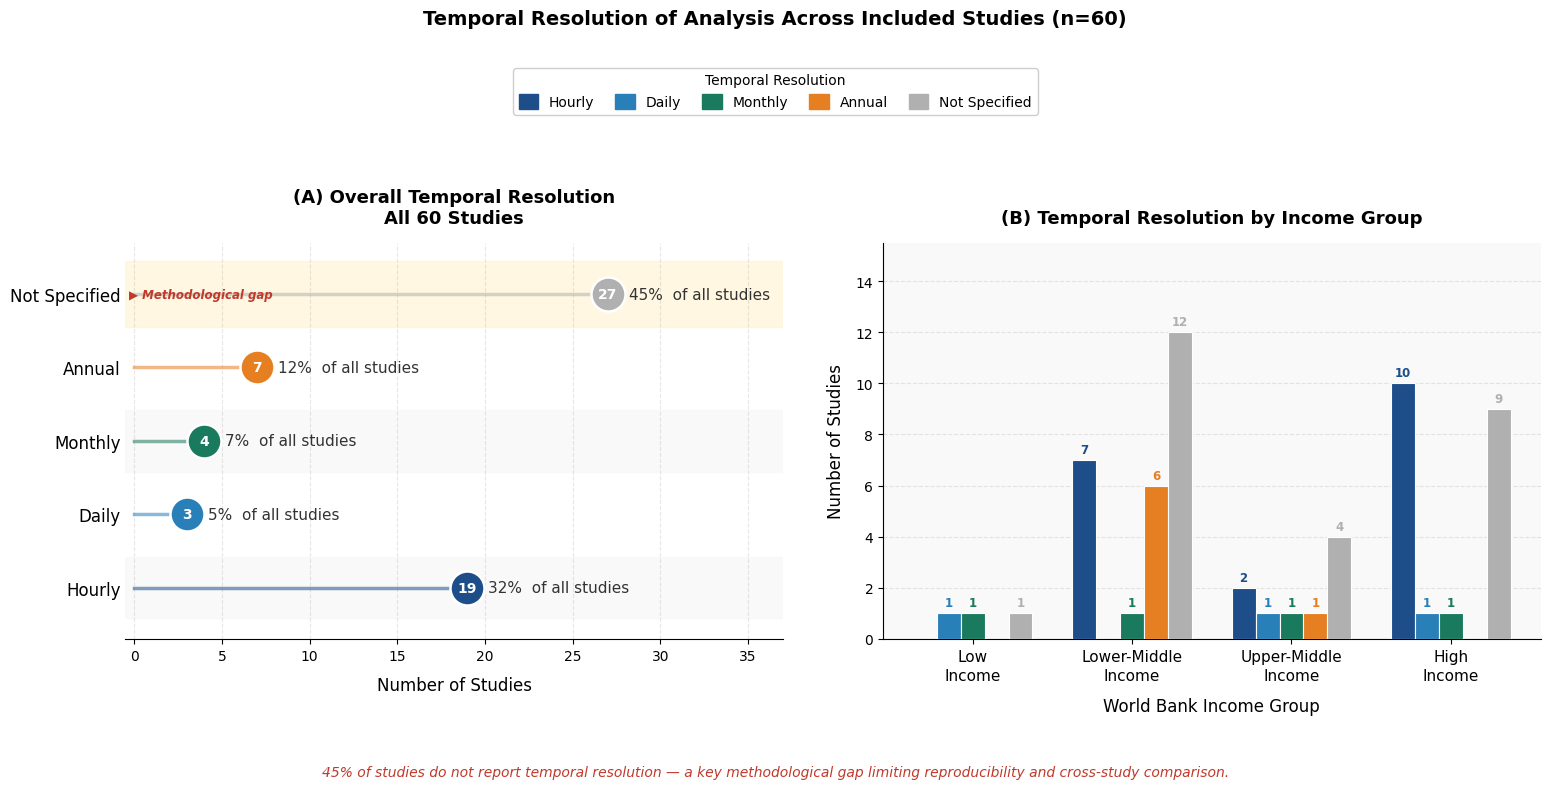

Saved: fig8_temporal_resolution.pdf


In [ ]:
# CELL 18 — Figure 8: Temporal Resolution Distribution

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ── Data ──────────────────────────────────────────────────────────────────────
temp_order  = ['Hourly', 'Daily', 'Monthly', 'Annual', 'Not Specified']
temp_colors = ['#1d4e89', '#2980b9', '#1a7a5e', '#e67e22', '#b0b0b0']

temp_counts = df['Temporal_clean'].value_counts()
temp_vals   = [temp_counts.get(k, 0) for k in temp_order]
total       = len(df)

# ── Income × Temporal crosstab ────────────────────────────────────────────────
income_keys  = ['Low income', 'Lower-middle income',
                'Upper-middle income', 'High income']
income_short = ['Low\nIncome', 'Lower-Middle\nIncome',
                'Upper-Middle\nIncome', 'High\nIncome']

ct     = pd.crosstab(df['Income_clean'], df['Temporal_clean'])
ct     = ct.reindex(index=income_keys, columns=temp_order, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# ── Figure: 2 panels ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor('#ffffff')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — Lollipop: overall temporal resolution
# ─────────────────────────────────────────────────────────────────────────────
ax1.set_facecolor('#ffffff')
y = np.arange(len(temp_order))

for i, (val, color) in enumerate(zip(temp_vals, temp_colors)):
    pct = val / total * 100
    ax1.plot([0, val], [i, i], color=color, lw=2.5,
             alpha=0.55, zorder=2)
    ax1.scatter(val, i, color=color, s=600, zorder=3,
                edgecolors='white', lw=1.8)
    ax1.text(val, i, str(val),
             ha='center', va='center',
             fontsize=10, fontweight='bold',
             color='white', zorder=4)
    ax1.text(val + 1.2, i,
             f'{pct:.0f}%  of all studies',
             va='center', ha='left',
             fontsize=11, color='#333333')

# Highlight "Not Specified" as a gap finding
ax1.axhspan(3.55, 4.45, color='#fff3cd', alpha=0.6, zorder=0)
ax1.text(-0.3, 4,
         '▶ Methodological gap',
         va='center', ha='left',
         fontsize=8.5, color='#c0392b',
         style='italic', fontweight='bold')

for i in range(0, len(temp_order) - 1, 2):
    ax1.axhspan(i - 0.42, i + 0.42, color='#f5f5f5',
                alpha=0.5, zorder=0)

ax1.set_yticks(y)
ax1.set_yticklabels(temp_order, fontsize=12)
ax1.set_xlabel('Number of Studies', fontsize=12, labelpad=10)
ax1.set_xlim(-0.5, max(temp_vals) + 10)
ax1.set_ylim(-0.7, len(temp_order) - 0.3)
ax1.set_title('(A) Overall Temporal Resolution\nAll 60 Studies',
              fontsize=13, fontweight='bold', pad=14)
ax1.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.tick_params(axis='y', length=0)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — Grouped bar: temporal resolution by income group
# ─────────────────────────────────────────────────────────────────────────────
ax2.set_facecolor('#f9f9f9')

x       = np.arange(len(income_keys))
n_bars  = len(temp_order)
w       = 0.15
offsets = np.linspace(-(n_bars - 1) * w / 2,
                       (n_bars - 1) * w / 2, n_bars)

for i, (t_key, color, offset) in enumerate(
        zip(temp_order, temp_colors, offsets)):
    vals = ct[t_key].values
    bars = ax2.bar(x + offset, vals, width=w,
                   color=color, edgecolor='white',
                   linewidth=0.8, label=t_key, zorder=3)
    for bar, v in zip(bars, vals):
        if v >= 1:
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.15,
                     str(int(v)),
                     ha='center', va='bottom',
                     fontsize=8.5, fontweight='bold',
                     color=color)

ax2.set_xticks(x)
ax2.set_xticklabels(income_short, fontsize=11, linespacing=1.4)
ax2.set_ylabel('Number of Studies', fontsize=12, labelpad=8)
ax2.set_xlabel('World Bank Income Group', fontsize=12, labelpad=10)
ax2.set_ylim(0, ct.values.max() + 3.5)
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.set_title('(B) Temporal Resolution by Income Group',
              fontsize=13, fontweight='bold', pad=14)
ax2.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)

# ── Horizontal legend at top ──────────────────────────────────────────────────
legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(temp_colors, temp_order)]
fig.legend(handles=legend_patches,
           title='Temporal Resolution',
           title_fontsize=10, fontsize=10,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.06),
           ncol=5,
           framealpha=0.95,
           edgecolor='#cccccc',
           handlelength=1.4, handleheight=1.2,
           columnspacing=1.5)

fig.suptitle('Temporal Resolution of Analysis Across Included Studies (n=60)',
             fontsize=14, fontweight='bold', y=1.14)

fig.text(0.5, -0.04,
         '45% of studies do not report temporal resolution — '
         'a key methodological gap limiting reproducibility and cross-study comparison.',
         ha='center', fontsize=10, style='italic', color='#c0392b')

plt.tight_layout(pad=2.5)
plt.savefig(f'{SAVE_DIR}/fig8_temporal_resolution.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig8_temporal_resolution.pdf")

## CELL 19 — Figure 9: PROBAST Traffic Light Plot

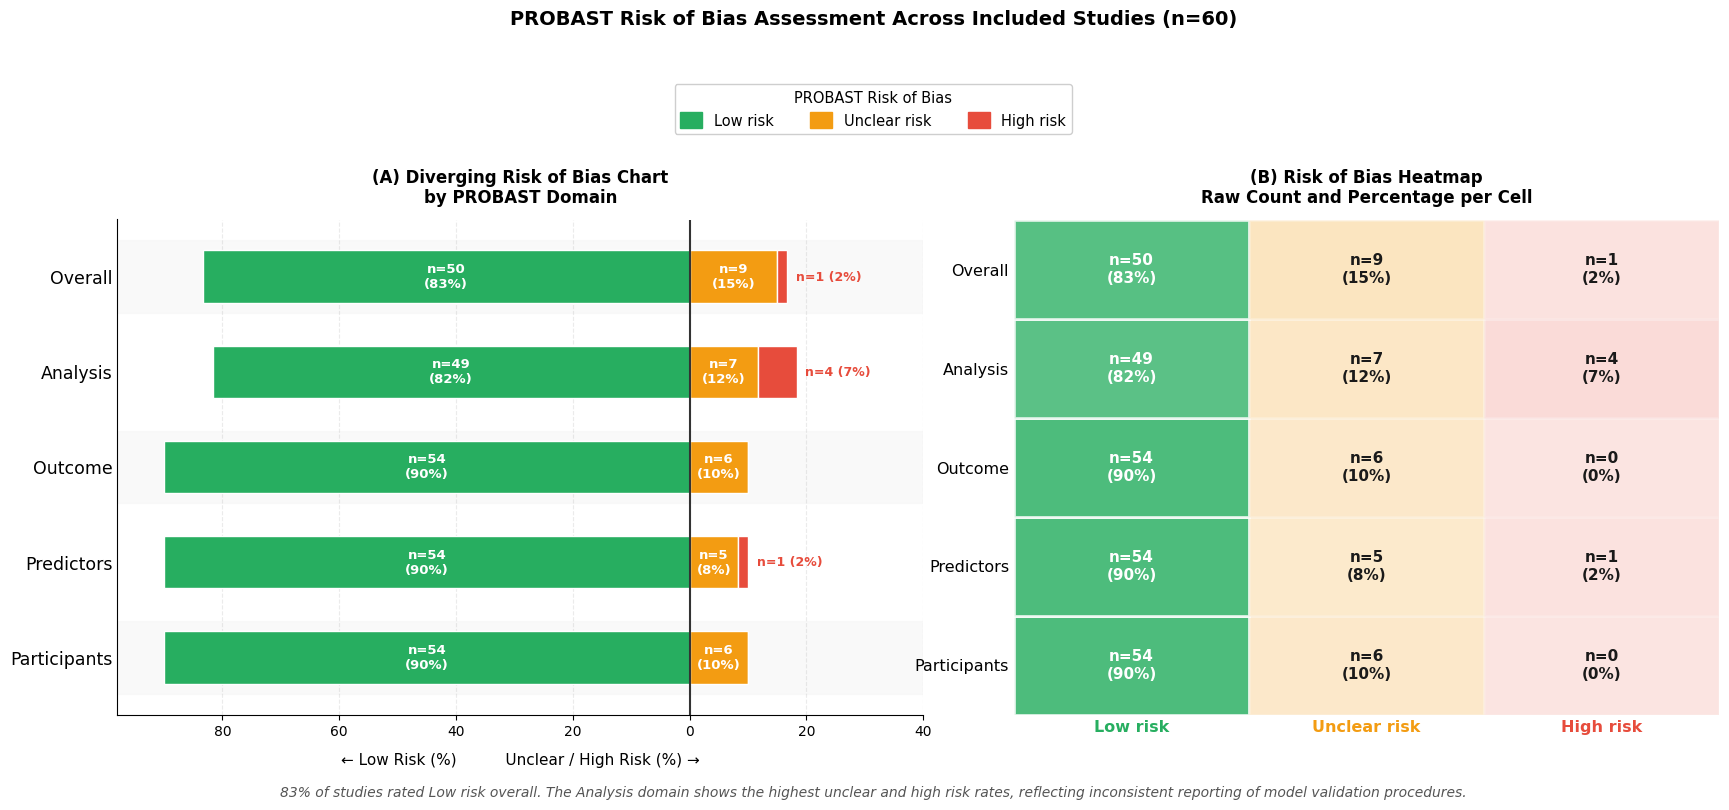

Saved: fig9_probast_rob.pdf


In [ ]:
# CELL 19 FINAL — Figure 9: PROBAST Risk of Bias

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ── Data ──────────────────────────────────────────────────────────────────────
domains     = ['Participants', 'Predictors', 'Outcome', 'Analysis', 'Overall']
domain_cols = ['PROBAST_participants', 'PROBAST_predictors',
               'PROBAST_outcome', 'PROBAST_analysis', 'PROBAST_overall']
rob_order  = ['Low risk', 'Unclear risk', 'High risk']
rob_colors = {'Low risk': '#27ae60', 'Unclear risk': '#f39c12', 'High risk': '#e74c3c'}
n_total    = len(df)

summary = {}
for col, dom in zip(domain_cols, domains):
    vc = df[col].value_counts()
    summary[dom] = {r: vc.get(r, 0) for r in rob_order}

summary_df = pd.DataFrame(summary).T[rob_order]
for r in rob_order:
    summary_df[f'pct_{r}'] = summary_df[r] / n_total * 100

# ── Figure: 1 row, 2 panels ───────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 7.5))
fig.patch.set_facecolor('#ffffff')
gs  = gridspec.GridSpec(1, 2,
                        width_ratios=[1.6, 1.4],
                        wspace=0.12,
                        left=0.08, right=0.97,
                        top=0.78, bottom=0.12)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — Diverging bar chart
# Low risk bars go LEFT, Unclear+High go RIGHT from centre
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#ffffff')

y = np.arange(len(domains))

low_pct     = summary_df['pct_Low risk'].values
unclear_pct = summary_df['pct_Unclear risk'].values
high_pct    = summary_df['pct_High risk'].values
low_n       = summary_df['Low risk'].values
unclear_n   = summary_df['Unclear risk'].values
high_n      = summary_df['High risk'].values

# Low risk → left (negative)
ax1.barh(y, -low_pct, height=0.55,
         color='#27ae60', edgecolor='white',
         linewidth=1.0, zorder=3, label='Low risk')

# Unclear risk → right
ax1.barh(y, unclear_pct, height=0.55,
         color='#f39c12', edgecolor='white',
         linewidth=1.0, zorder=3, label='Unclear risk')

# High risk → stacked after unclear
ax1.barh(y, high_pct, left=unclear_pct,
         height=0.55, color='#e74c3c',
         edgecolor='white', linewidth=1.0,
         zorder=3, label='High risk')

# Labels — Low risk (left side)
for i, (pct, n) in enumerate(zip(low_pct, low_n)):
    ax1.text(-pct / 2, i,
             f'n={n}\n({pct:.0f}%)',
             ha='center', va='center',
             fontsize=9.5, fontweight='bold',
             color='white', zorder=4)

# Labels — Unclear risk (right side)
for i, (pct, n) in enumerate(zip(unclear_pct, unclear_n)):
    if pct >= 5:
        ax1.text(pct / 2, i,
                 f'n={n}\n({pct:.0f}%)',
                 ha='center', va='center',
                 fontsize=9.5, fontweight='bold',
                 color='white', zorder=4)

# Labels — High risk (outside bar, coloured)
for i, (pct, n, up) in enumerate(zip(high_pct, high_n, unclear_pct)):
    if pct > 0:
        ax1.text(up + pct + 1.5, i,
                 f'n={n} ({pct:.0f}%)',
                 ha='left', va='center',
                 fontsize=9, fontweight='bold',
                 color='#e74c3c', zorder=4)

# Centre line
ax1.axvline(0, color='#333333', lw=1.5, zorder=5)

# Axis formatting
ax1.set_yticks(y)
ax1.set_yticklabels(domains, fontsize=12.5)
ax1.set_xlabel('← Low Risk (%)          Unclear / High Risk (%) →',
               fontsize=11, labelpad=10)

max_left  = max(low_pct)
max_right = max(unclear_pct + high_pct) + 12
ax1.set_xlim(-max_left - 8, max_right)
ax1.set_ylim(-0.6, len(domains) - 0.4)

# Custom x-tick labels (absolute values)
ticks = np.arange(-80, max_right + 10, 20)
ax1.set_xticks(ticks)
ax1.set_xticklabels([str(abs(int(t))) for t in ticks], fontsize=10)

ax1.set_title('(A) Diverging Risk of Bias Chart\nby PROBAST Domain',
              fontsize=12, fontweight='bold', pad=12)
ax1.grid(axis='x', linestyle='--', alpha=0.25, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', length=0)

for i in range(0, len(domains), 2):
    ax1.axhspan(i - 0.38, i + 0.38,
                color='#f5f5f5', alpha=0.5, zorder=0)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — Heatmap: exact counts in a clean grid
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#ffffff')

# Build matrix: rows = domains, cols = ROB
matrix_n   = np.array([[summary[d][r] for r in rob_order] for d in domains])
matrix_pct = matrix_n / n_total * 100

# Color intensity per cell using each ROB color tinted by percentage
from matplotlib.colors import LinearSegmentedColormap

for i, dom in enumerate(domains):
    for j, rob in enumerate(rob_order):
        n_val  = matrix_n[i, j]
        pct    = matrix_pct[i, j]
        # background intensity
        alpha  = 0.15 + (pct / 100) * 0.75
        rect   = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                facecolor=rob_colors[rob],
                                alpha=alpha,
                                edgecolor='white',
                                linewidth=2, zorder=2)
        ax2.add_patch(rect)
        # text
        tc = 'white' if pct > 55 else '#1a1a1a'
        ax2.text(j, i,
                 f'n={n_val}\n({pct:.0f}%)',
                 ha='center', va='center',
                 fontsize=11, fontweight='bold',
                 color=tc, zorder=3)

ax2.set_xlim(-0.5, len(rob_order) - 0.5)
ax2.set_ylim(-0.5, len(domains) - 0.5)
ax2.set_xticks(range(len(rob_order)))
ax2.set_xticklabels(rob_order, fontsize=11.5,
                    fontweight='bold')
# colour the x tick labels
for tick, rob in zip(ax2.get_xticklabels(), rob_order):
    tick.set_color(rob_colors[rob])

ax2.set_yticks(range(len(domains)))
ax2.set_yticklabels(domains, fontsize=11.5)
ax2.tick_params(length=0)
ax2.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax2.set_title('(B) Risk of Bias Heatmap\nRaw Count and Percentage per Cell',
              fontsize=12, fontweight='bold', pad=12)

# ── Horizontal legend at top ──────────────────────────────────────────────────
legend_patches = [mpatches.Patch(color=rob_colors[r], label=r)
                  for r in rob_order]
fig.legend(handles=legend_patches,
           title='PROBAST Risk of Bias',
           title_fontsize=10.5, fontsize=10.5,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.97),
           ncol=3, framealpha=0.95,
           edgecolor='#cccccc',
           handlelength=1.5, handleheight=1.3,
           columnspacing=2.5)

fig.suptitle(
    'PROBAST Risk of Bias Assessment Across Included Studies (n=60)',
    fontsize=14, fontweight='bold', y=1.06)

fig.text(0.5, 0.01,
         '83% of studies rated Low risk overall. '
         'The Analysis domain shows the highest unclear and high risk rates, '
         'reflecting inconsistent reporting of model validation procedures.',
         ha='center', fontsize=10,
         style='italic', color='#555555')

plt.savefig(f'{SAVE_DIR}/fig9_probast_rob.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig9_probast_rob.pdf")

## CELL 20 — Inspect the three gap columns first

In [ ]:
# CELL 20 — Inspect methodological gap columns

print("Class imbalance:")
print(df['Imbalance_clean'].value_counts().to_string())
print()
print("Training split:")
print(df['Split_clean'].value_counts().to_string())
print()
print("Hyperparameter tuning:")
print(df['Hyperparameter tuning reported'].value_counts().to_string())
print()
print("LMIC transferability:")
print(df['Transfer_clean'].value_counts().to_string())

Class imbalance:
Imbalance_clean
Not Reported     26
SMOTE            16
Not Addressed     6
Undersampling     5
Oversampling      5
Other             2

Training split:
Split_clean
Fixed Split         30
Not Reported        23
Time-based Split     4
k-Fold CV            3

Hyperparameter tuning:
Hyperparameter tuning reported
Yes             40
Not reported    16
No               4

LMIC transferability:
Transfer_clean
Partially    23
Yes          20
No           17


## CELL 21 — Figure 10: Methodological Gaps Summary

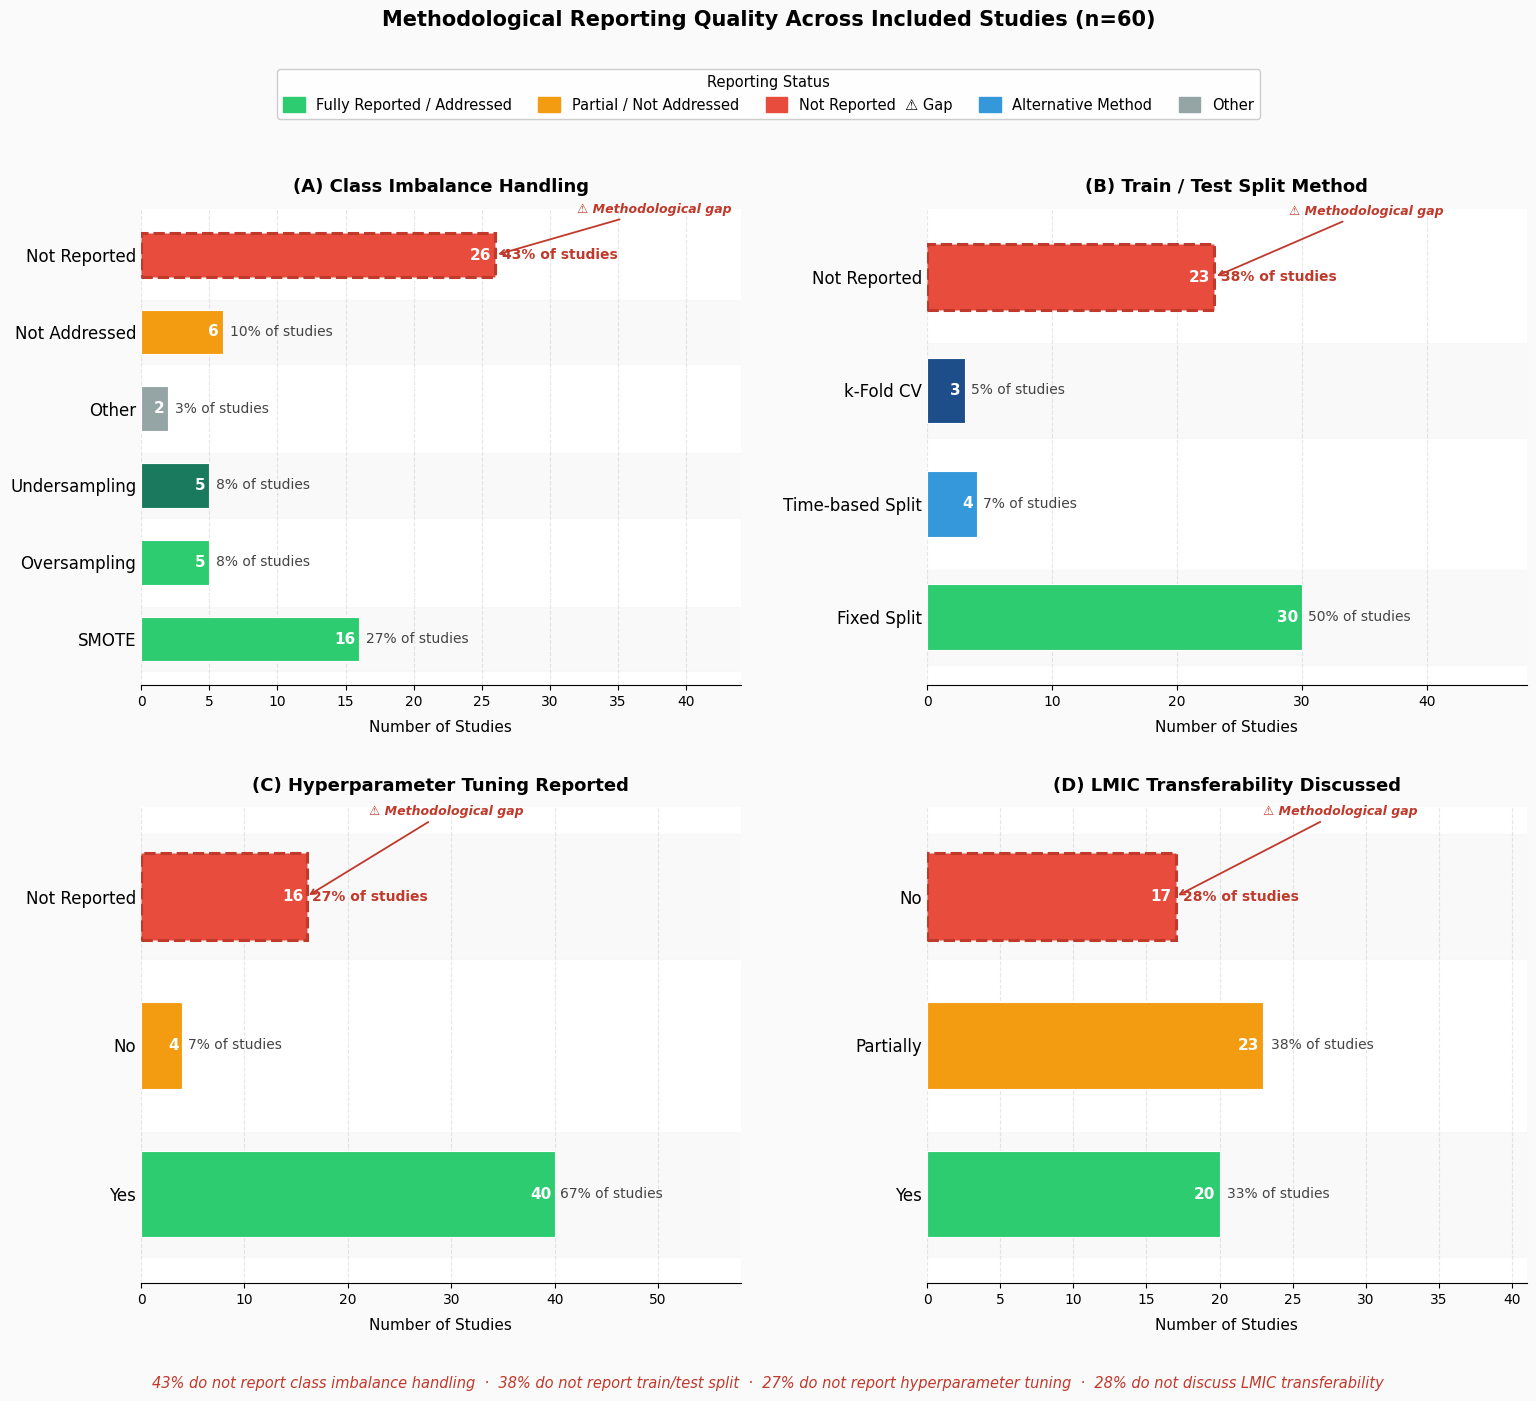

Saved: fig10_methodological_gaps.pdf


In [ ]:
# CELL 21 FINAL — Figure 10: Methodological Gaps — Figure 4 style

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

total = len(df)

C_GREEN  = '#2ecc71'
C_TEAL   = '#1a7a5e'
C_ORANGE = '#f39c12'
C_RED    = '#e74c3c'
C_BLUE   = '#3498db'
C_NAVY   = '#1d4e89'
C_GREY   = '#95a5a6'

# ── All 4 panels data ─────────────────────────────────────────────────────────
panels = [
    {
        'letter': 'A',
        'title':  'Class Imbalance Handling',
        'labels': ['SMOTE', 'Oversampling', 'Undersampling',
                   'Other', 'Not Addressed', 'Not Reported'],
        'values': [16, 5, 5, 2, 6, 26],
        'colors': [C_GREEN, C_GREEN, C_TEAL,
                   C_GREY, C_ORANGE, C_RED],
        'gap':    [5],
    },
    {
        'letter': 'B',
        'title':  'Train / Test Split Method',
        'labels': ['Fixed Split', 'Time-based Split',
                   'k-Fold CV', 'Not Reported'],
        'values': [30, 4, 3, 23],
        'colors': [C_GREEN, C_BLUE, C_NAVY, C_RED],
        'gap':    [3],
    },
    {
        'letter': 'C',
        'title':  'Hyperparameter Tuning Reported',
        'labels': ['Yes', 'No', 'Not Reported'],
        'values': [40, 4, 16],
        'colors': [C_GREEN, C_ORANGE, C_RED],
        'gap':    [2],
    },
    {
        'letter': 'D',
        'title':  'LMIC Transferability Discussed',
        'labels': ['Yes', 'Partially', 'No'],
        'values': [20, 23, 17],
        'colors': [C_GREEN, C_ORANGE, C_RED],
        'gap':    [2],
    },
]

# ── Figure: 2 rows × 2 cols — gives each panel plenty of room ────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.patch.set_facecolor('#fafafa')
axes = axes.flatten()

for ax, panel in zip(axes, panels):
    ax.set_facecolor('#ffffff')

    labels = panel['labels']
    values = panel['values']
    colors = panel['colors']
    gap    = panel['gap']

    y    = np.arange(len(labels))
    bars = ax.barh(y, values, color=colors,
                   height=0.58, edgecolor='white',
                   linewidth=0.8, zorder=3)

    # gap bars — dashed red border
    for gi in gap:
        bars[gi].set_edgecolor('#c0392b')
        bars[gi].set_linewidth(2.2)
        bars[gi].set_linestyle('--')

    # count inside bar + % outside
    for i, (bar, v) in enumerate(zip(bars, values)):
        pct    = v / total * 100
        is_gap = i in gap
        # count inside
        ax.text(bar.get_width() - 0.3,
                bar.get_y() + bar.get_height() / 2,
                f'{v}',
                ha='right', va='center',
                fontsize=11, fontweight='bold',
                color='white', zorder=4)
        # % outside
        ax.text(bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f'{pct:.0f}% of studies',
                ha='left', va='center',
                fontsize=10,
                color='#c0392b' if is_gap else '#444444',
                fontweight='bold' if is_gap else 'normal')

    # zebra rows
    for i in range(0, len(labels), 2):
        ax.axhspan(i - 0.42, i + 0.42,
                   color='#f5f5f5', alpha=0.5, zorder=0)

    # gap annotation
    for gi in gap:
        ax.annotate('⚠ Methodological gap',
                    xy=(values[gi], gi),
                    xytext=(values[gi] + 6, gi + 0.55),
                    fontsize=9, color='#c0392b',
                    fontweight='bold', style='italic',
                    arrowprops=dict(arrowstyle='->',
                                    color='#c0392b',
                                    lw=1.3))

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel('Number of Studies', fontsize=11, labelpad=8)
    ax.set_xlim(0, max(values) + 18)
    ax.set_ylim(-0.6, len(labels) - 0.4)
    ax.set_title(f'({panel["letter"]}) {panel["title"]}',
                 fontsize=13, fontweight='bold', pad=12)
    ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=C_GREEN,  label='Fully Reported / Addressed'),
    mpatches.Patch(color=C_ORANGE, label='Partial / Not Addressed'),
    mpatches.Patch(color=C_RED,    label='Not Reported  ⚠ Gap'),
    mpatches.Patch(color=C_BLUE,   label='Alternative Method'),
    mpatches.Patch(color=C_GREY,   label='Other'),
]
fig.legend(handles=legend_patches,
           title='Reporting Status',
           title_fontsize=10.5, fontsize=10.5,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.01),
           ncol=5, framealpha=0.97,
           edgecolor='#cccccc',
           handlelength=1.5, handleheight=1.2,
           columnspacing=1.8)

fig.suptitle(
    'Methodological Reporting Quality Across Included Studies (n=60)',
    fontsize=15, fontweight='bold', y=1.05)

fig.text(0.5, -0.01,
         '43% do not report class imbalance handling  ·  '
         '38% do not report train/test split  ·  '
         '27% do not report hyperparameter tuning  ·  '
         '28% do not discuss LMIC transferability',
         ha='center', fontsize=10.5,
         style='italic', color='#c0392b')

plt.tight_layout(pad=3.0)
plt.savefig(f'{SAVE_DIR}/fig10_methodological_gaps.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig10_methodological_gaps.pdf")

## CELL 22 — Figure 11: Prediction Task × Algorithm Category

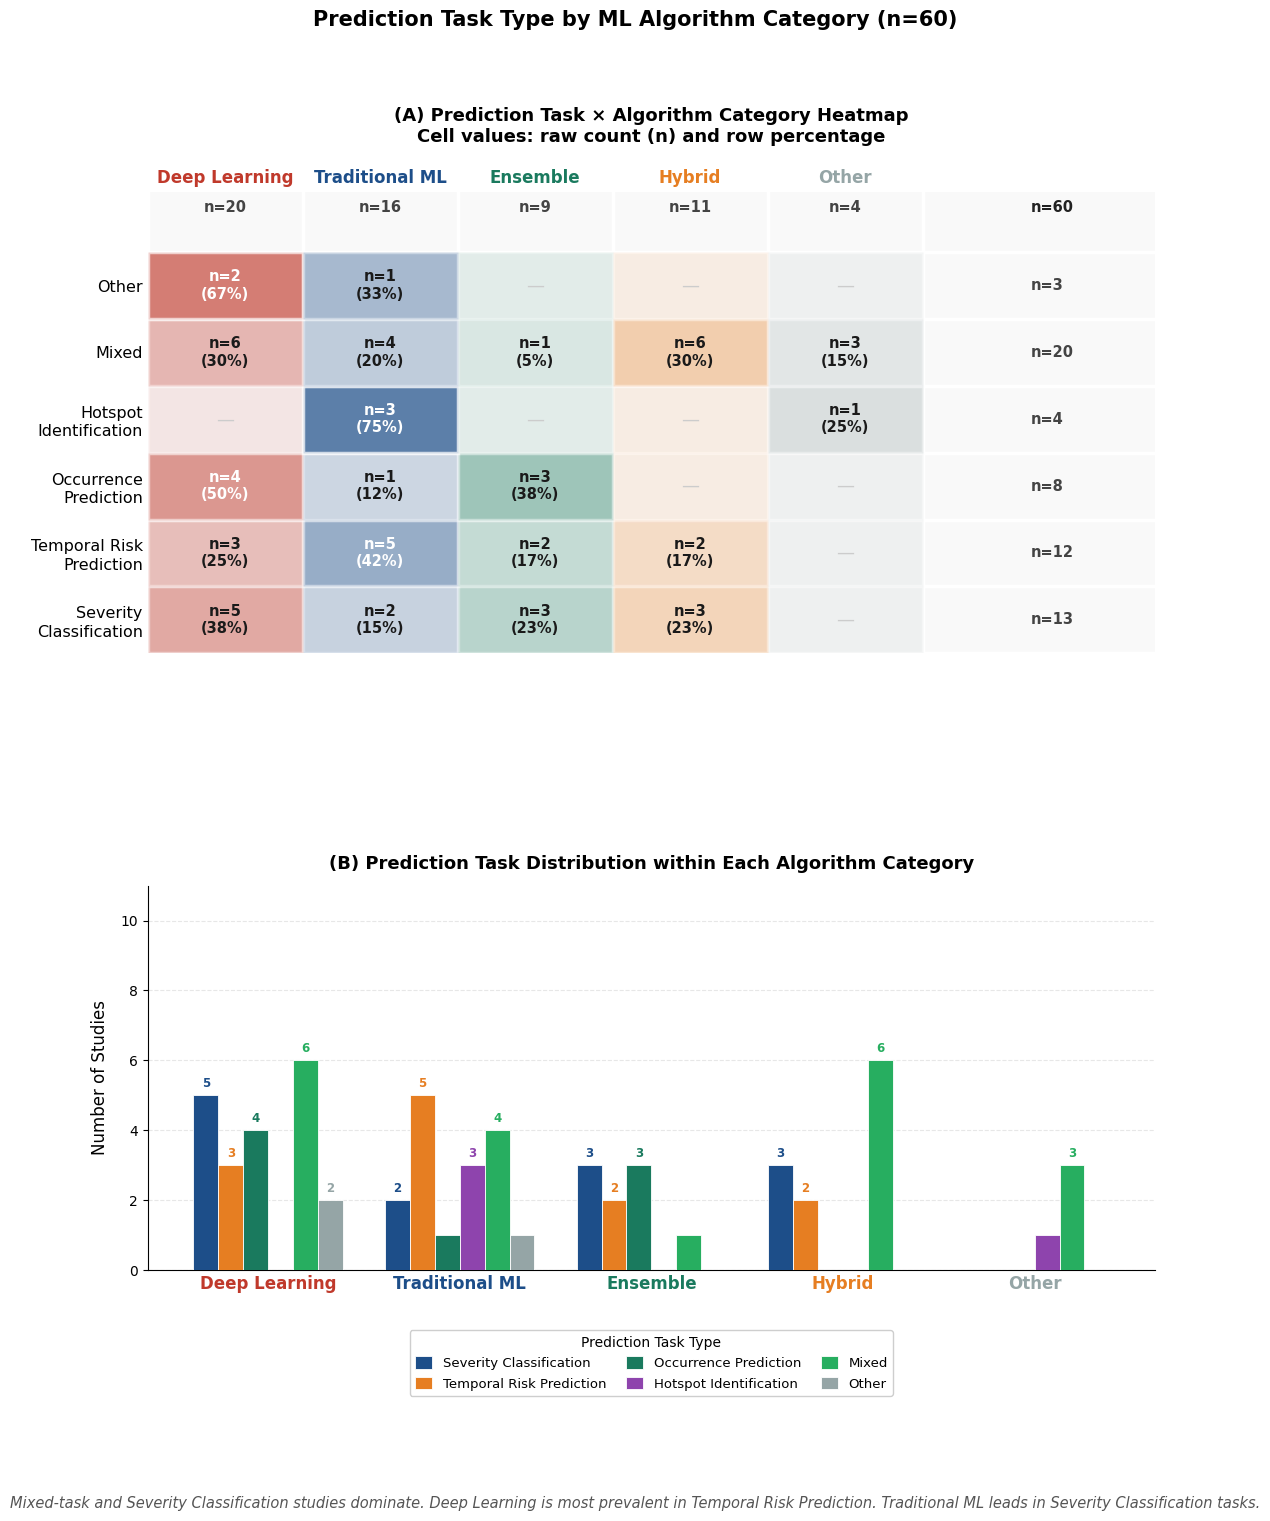

Saved: fig11_task_algo.pdf


In [ ]:
# CELL 22 FIXED — Figure 11: Prediction Task × Algorithm Category

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Data ──────────────────────────────────────────────────────────────────────
task_order = ['Severity\nClassification',
              'Temporal Risk\nPrediction',
              'Occurrence\nPrediction',
              'Hotspot\nIdentification',
              'Mixed',
              'Other']
task_keys  = ['Severity Classification',
              'Temporal Risk Prediction',
              'Occurrence Prediction',
              'Hotspot Identification',
              'Mixed',
              'Other']
algo_order = ['Deep Learning', 'Traditional ML',
              'Ensemble', 'Hybrid', 'Other']

ct     = pd.crosstab(df['Task_clean'], df['AlgoCat_clean'])
ct.index = ct.index.map(lambda x: dict(zip(task_keys,
                                            task_order)).get(x, x))
ct     = ct.reindex(index=task_order,
                    columns=algo_order, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

row_tots = ct.sum(axis=1).values
col_tots = ct.sum(axis=0).values

algo_colors = {
    'Deep Learning':  '#c0392b',
    'Traditional ML': '#1d4e89',
    'Ensemble':       '#1a7a5e',
    'Hybrid':         '#e67e22',
    'Other':          '#95a5a6',
}
task_palette = ['#1d4e89', '#e67e22', '#1a7a5e',
                '#8e44ad', '#27ae60', '#95a5a6']

# ── Figure: 2 rows × 1 col — heatmap on top, stacked bar below ───────────────
fig, (ax1, ax2) = plt.subplots(2, 1,
                                figsize=(13, 14),
                                gridspec_kw={'height_ratios': [1.2, 1],
                                             'hspace': 0.55})
fig.patch.set_facecolor('#ffffff')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — Heatmap (tasks on Y, algorithms on X)
# ─────────────────────────────────────────────────────────────────────────────
ax1.set_facecolor('#f9f9f9')

for i, task in enumerate(task_order):
    for j, algo in enumerate(algo_order):
        n_val = ct.loc[task, algo]
        pct   = ct_pct.loc[task, algo]
        alpha = 0.10 + (pct / 100) * 0.82
        color = algo_colors[algo]

        rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                              facecolor=color, alpha=alpha,
                              edgecolor='white', linewidth=2.5,
                              zorder=2)
        ax1.add_patch(rect)

        if n_val > 0:
            tc = 'white' if pct > 40 else '#1a1a1a'
            ax1.text(j, i,
                     f'n={n_val}\n({pct:.0f}%)',
                     ha='center', va='center',
                     fontsize=10.5, fontweight='bold',
                     color=tc, zorder=3)
        else:
            ax1.text(j, i, '—',
                     ha='center', va='center',
                     fontsize=13, color='#cccccc', zorder=3)

# Row totals — right margin
for i, tot in enumerate(row_tots):
    ax1.text(len(algo_order) - 0.5 + 0.7, i,
             f'n={tot}',
             ha='left', va='center',
             fontsize=10.5, color='#444444', fontweight='bold')

# Col totals — top margin
for j, tot in enumerate(col_tots):
    ax1.text(j, len(task_order) - 0.5 + 0.55,
             f'n={tot}',
             ha='center', va='bottom',
             fontsize=10.5, color='#444444', fontweight='bold')

# "Total" label
ax1.text(len(algo_order) - 0.5 + 0.7,
         len(task_order) - 0.5 + 0.55,
         f'n={sum(row_tots)}',
         ha='left', va='bottom',
         fontsize=10.5, color='#222222', fontweight='bold')

ax1.set_xlim(-0.5, len(algo_order) - 0.5 + 1.5)
ax1.set_ylim(-0.5, len(task_order) - 0.5 + 0.9)

# X labels (top)
ax1.set_xticks(range(len(algo_order)))
ax1.xaxis.set_tick_params(length=0)
ax1.set_xticklabels(algo_order, fontsize=12,
                    fontweight='bold', va='bottom')
ax1.xaxis.set_ticks_position('top')
ax1.xaxis.set_label_position('top')
for tick, algo in zip(ax1.get_xticklabels(), algo_order):
    tick.set_color(algo_colors[algo])

# Y labels
ax1.set_yticks(range(len(task_order)))
ax1.set_yticklabels(task_order, fontsize=11.5, linespacing=1.3)
ax1.tick_params(which='both', length=0)
ax1.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

# white minor grid
ax1.set_xticks(np.arange(-0.5, len(algo_order), 1),   minor=True)
ax1.set_yticks(np.arange(-0.5, len(task_order), 1),   minor=True)
ax1.grid(which='minor', color='white', linewidth=2.5)
ax1.tick_params(which='minor', length=0)

ax1.set_title('(A) Prediction Task × Algorithm Category Heatmap\n'
              'Cell values: raw count (n) and row percentage',
              fontsize=13, fontweight='bold', pad=36)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — Grouped bar chart (cleaner than stacked for small counts)
# ─────────────────────────────────────────────────────────────────────────────
ax2.set_facecolor('#ffffff')

n_tasks = len(task_keys)
n_algos = len(algo_order)
w       = 0.13
x       = np.arange(n_algos)
offsets = np.linspace(-(n_tasks - 1) * w / 2,
                       (n_tasks - 1) * w / 2, n_tasks)

for t_idx, (task_key, task_label) in enumerate(
        zip(task_keys, task_order)):
    vals = ct.loc[task_order[t_idx], algo_order].values
    bars = ax2.bar(x + offsets[t_idx], vals,
                   width=w,
                   color=task_palette[t_idx],
                   edgecolor='white', linewidth=0.6,
                   zorder=3,
                   label=task_label.replace('\n', ' '))
    for bar, v in zip(bars, vals):
        if v >= 2:
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.15,
                     str(int(v)),
                     ha='center', va='bottom',
                     fontsize=8.5, fontweight='bold',
                     color=task_palette[t_idx])

# x-axis labels coloured by algo
ax2.set_xticks(x)
ax2.set_xticklabels(algo_order, fontsize=12, fontweight='bold')
for tick, algo in zip(ax2.get_xticklabels(), algo_order):
    tick.set_color(algo_colors[algo])

ax2.set_ylabel('Number of Studies', fontsize=12, labelpad=8)
ax2.set_ylim(0, ct.values.max() + 5)
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.set_title('(B) Prediction Task Distribution within Each Algorithm Category',
              fontsize=13, fontweight='bold', pad=12)
ax2.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='x', length=0)

# Legend below panel B
ax2.legend(title='Prediction Task Type',
           title_fontsize=10, fontsize=9.5,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.14),
           ncol=3, framealpha=0.95,
           edgecolor='#cccccc',
           handlelength=1.3, handleheight=1.1,
           columnspacing=1.5)

# ── Main title ────────────────────────────────────────────────────────────────
fig.suptitle(
    'Prediction Task Type by ML Algorithm Category (n=60)',
    fontsize=15, fontweight='bold', y=1.01)

fig.text(0.5, -0.06,
         'Mixed-task and Severity Classification studies dominate. '
         'Deep Learning is most prevalent in Temporal Risk Prediction. '
         'Traditional ML leads in Severity Classification tasks.',
         ha='center', fontsize=10.5,
         style='italic', color='#555555')

plt.savefig(f'{SAVE_DIR}/fig11_task_algo.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig11_task_algo.pdf")

## CELL 23 — Inspect Bangladesh-specific data first

In [ ]:
# CELL 23 — Inspect Bangladesh and LMIC specific data

bgd = df[df['Is_Bangladesh'] == True]
print(f"Bangladesh papers: {len(bgd)}")
print()
print("Titles:")
for i, row in bgd.iterrows():
    print(f"  - {row['Title']}")
print()
print("Algorithm used:")
print(bgd['AlgoCat_clean'].values)
print()
print("Task type:")
print(bgd['Task_clean'].values)
print()
print("Spatial method:")
print(bgd['Spatial_bucket'].values)
print()
print("PROBAST overall:")
print(bgd['PROBAST_overall'].values)
print()
print("Year:")
print(bgd['Year of publication'].values)
print()

# LMIC breakdown
lmic = df[df['Is_LMIC'] == 'LMIC']
print(f"\nLMIC papers: {len(lmic)}")
print("By income group:")
print(lmic['Income_clean'].value_counts().to_string())
print()
print("LMIC algo category:")
print(lmic['AlgoCat_clean'].value_counts().to_string())
print()
print("LMIC task type:")
print(lmic['Task_clean'].value_counts().to_string())
print()
print("LMIC transferability discussed:")
print(df['Transfer_clean'].value_counts().to_string())

Bangladesh papers: 2

Titles:
  - An Explainable Attention-Augmented LSTM Model for Robust Real-Time Detection of Driving Behavior Patterns and Road Anomalies in Smart Transportation Networks
  - Predicting Road Crash Severity Using Classifier Models and Crash Hotspots

Algorithm used:
['Deep Learning' 'Traditional ML']

Task type:
['Other' 'Mixed']

Spatial method:
['GPS / Telematics Input Only' 'Kernel Density Estimation']

PROBAST overall:
['Low risk' 'Low risk']

Year:
[2025 2022]


LMIC papers: 36
By income group:
Income_clean
Lower-middle income    25
Upper-middle income     7
Low income              3
High income             1

LMIC algo category:
AlgoCat_clean
Traditional ML    12
Deep Learning     10
Hybrid             5
Ensemble           5
Other              4

LMIC task type:
Task_clean
Mixed                       13
Severity Classification      7
Temporal Risk Prediction     5
Occurrence Prediction        4
Hotspot Identification       4
Other                        3

LMI

## CELL 24 — Figure 12: Bangladesh & LMIC Gap Summary

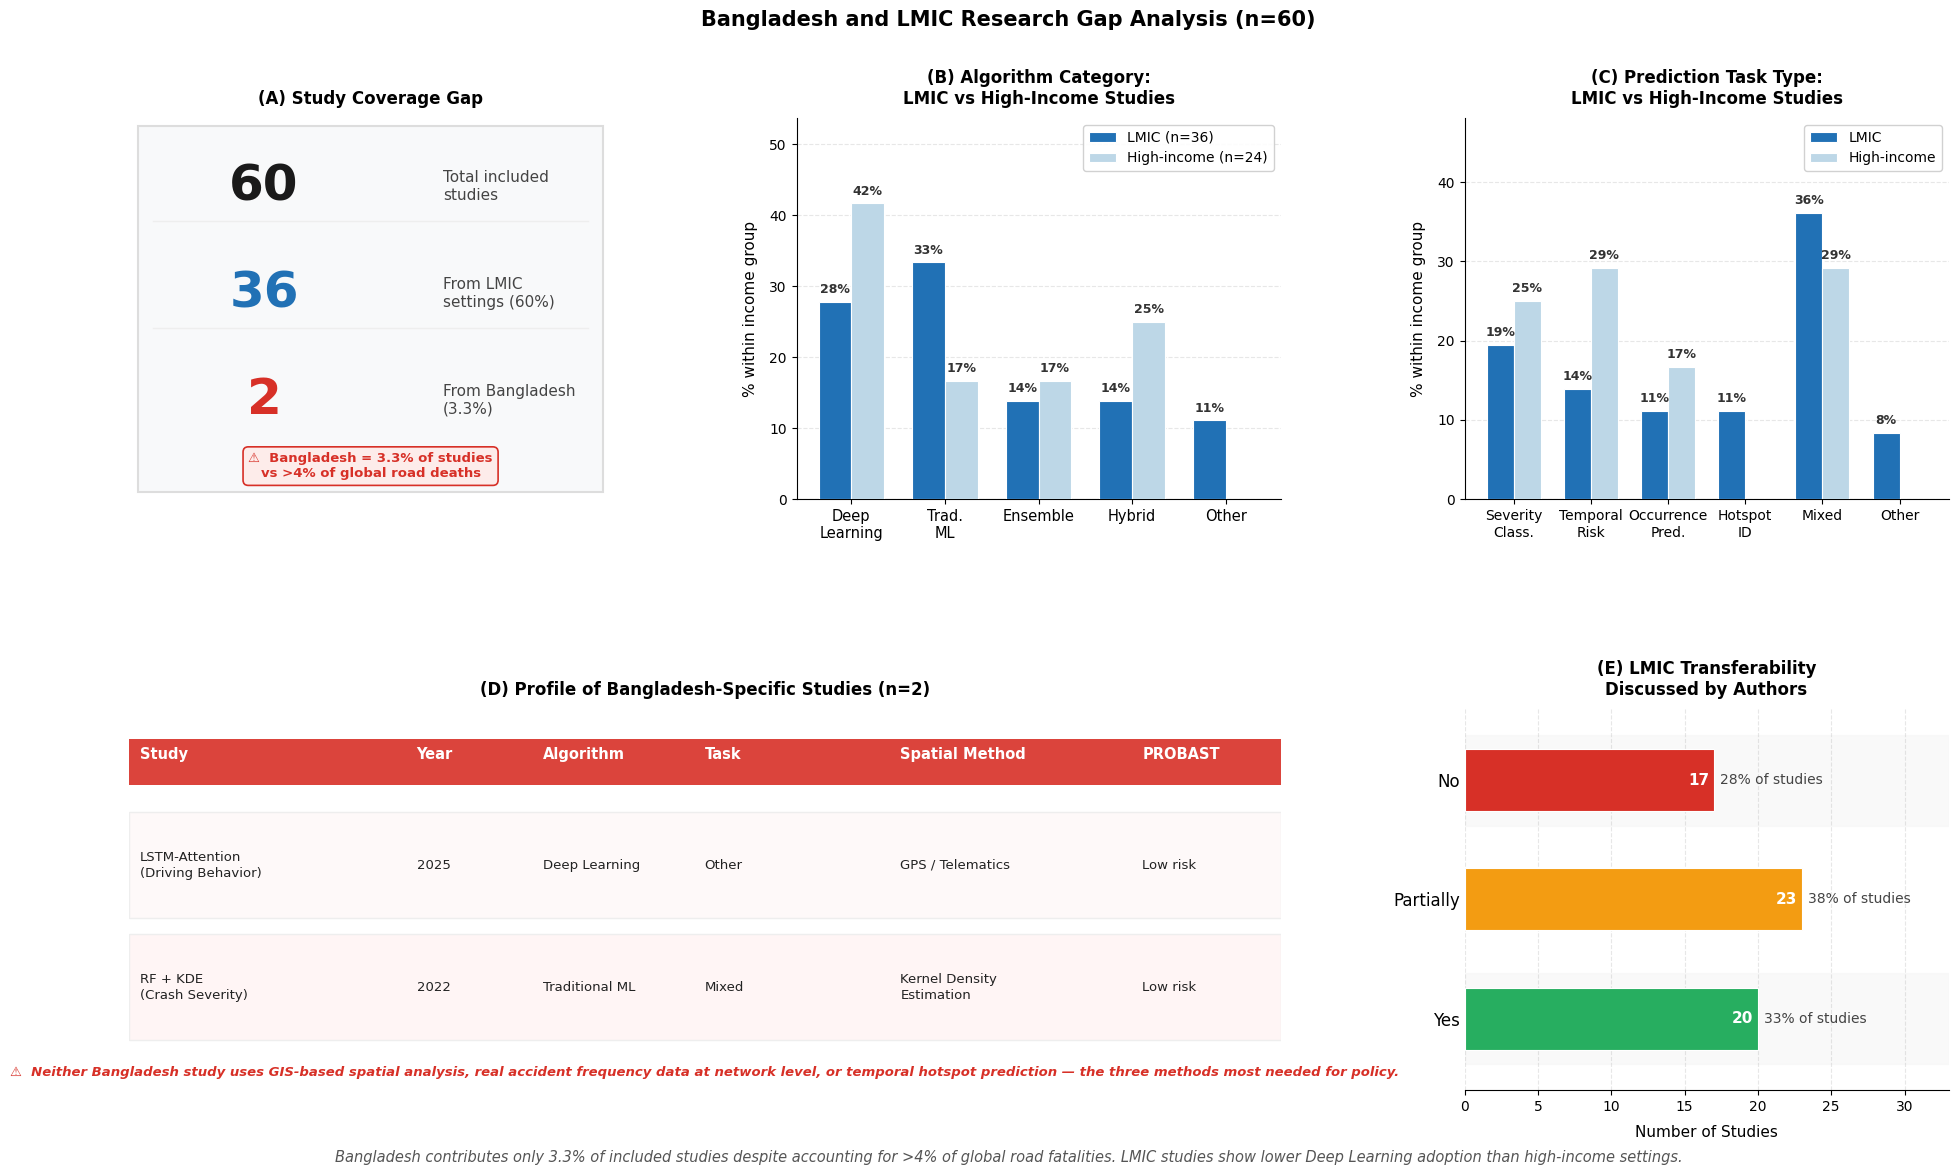

Saved: fig12_bangladesh_lmic_gap.pdf


In [ ]:
# CELL 24 — Figure 12: Bangladesh & LMIC Gap Summary

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

total   = len(df)
n_lmic  = 36
n_hic   = total - n_lmic
n_bgd   = 2

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#ffffff')

gs = gridspec.GridSpec(2, 3,
                       hspace=0.55, wspace=0.38,
                       left=0.06, right=0.97,
                       top=0.88, bottom=0.07)

C_BGD    = '#d73027'
C_LMIC   = '#2171b5'
C_HIC    = '#bdd7e7'
C_GREEN  = '#27ae60'
C_ORANGE = '#f39c12'
C_GREY   = '#95a5a6'

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — Study coverage gap (big numbers infographic style)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#ffffff')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# Background card
card = plt.Rectangle((0.02, 0.02), 0.96, 0.96,
                      facecolor='#f8f9fa',
                      edgecolor='#dddddd',
                      linewidth=1.5,
                      zorder=1)
ax1.add_patch(card)

ax1.set_title('(A) Study Coverage Gap',
              fontsize=12, fontweight='bold', pad=10)

# Big numbers
stats = [
    ('60',   '#1a1a1a', 'Total included\nstudies'),
    ('36',   C_LMIC,    'From LMIC\nsettings (60%)'),
    ('2',    C_BGD,     'From Bangladesh\n(3.3%)'),
]
for i, (num, color, label) in enumerate(stats):
    y = 0.82 - i * 0.28
    ax1.text(0.28, y, num,
             ha='center', va='center',
             fontsize=36, fontweight='bold',
             color=color, zorder=3,
             transform=ax1.transAxes)
    ax1.text(0.65, y, label,
             ha='left', va='center',
             fontsize=11, color='#444444',
             zorder=3,
             transform=ax1.transAxes)
    # divider
    if i < 2:
        ax1.axhline(y - 0.09, xmin=0.05, xmax=0.95,
                    color='#eeeeee', lw=1.0, zorder=2)

# Bangladesh gap callout
ax1.text(0.5, 0.05,
         '⚠  Bangladesh = 3.3% of studies\nvs >4% of global road deaths',
         ha='center', va='bottom',
         fontsize=9.5, fontweight='bold',
         color=C_BGD,
         transform=ax1.transAxes,
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#fdecea',
                   edgecolor=C_BGD,
                   linewidth=1.2))

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — LMIC vs HIC algo category comparison
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#ffffff')

algo_cats  = ['Deep Learning', 'Traditional ML',
              'Ensemble', 'Hybrid', 'Other']
lmic_vals  = [df[(df['Is_LMIC']=='LMIC') &
                  (df['AlgoCat_clean']==a)].shape[0]
              for a in algo_cats]
hic_vals   = [df[(df['Is_LMIC']=='High-income') &
                  (df['AlgoCat_clean']==a)].shape[0]
              for a in algo_cats]
lmic_pcts  = [v/n_lmic*100 for v in lmic_vals]
hic_pcts   = [v/n_hic*100  for v in hic_vals]

x  = np.arange(len(algo_cats))
w  = 0.35

b1 = ax2.bar(x - w/2, lmic_pcts, width=w,
             color=C_LMIC, edgecolor='white',
             linewidth=0.8, label='LMIC (n=36)',
             zorder=3)
b2 = ax2.bar(x + w/2, hic_pcts,  width=w,
             color=C_HIC,  edgecolor='white',
             linewidth=0.8, label='High-income (n=24)',
             zorder=3)

for bar, pct in zip(list(b1)+list(b2),
                     lmic_pcts+hic_pcts):
    if pct >= 5:
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f'{pct:.0f}%',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold',
                 color='#333333')

ax2.set_xticks(x)
ax2.set_xticklabels(['Deep\nLearning', 'Trad.\nML',
                     'Ensemble', 'Hybrid', 'Other'],
                    fontsize=10.5)
ax2.set_ylabel('% within income group', fontsize=11, labelpad=8)
ax2.set_ylim(0, max(lmic_pcts+hic_pcts) + 12)
ax2.set_title('(B) Algorithm Category:\nLMIC vs High-Income Studies',
              fontsize=12, fontweight='bold', pad=10)
ax2.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=10, loc='upper right',
           framealpha=0.9, edgecolor='#cccccc')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C — LMIC vs HIC prediction task comparison
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#ffffff')

task_cats  = ['Severity\nClass.', 'Temporal\nRisk',
              'Occurrence\nPred.', 'Hotspot\nID', 'Mixed', 'Other']
task_keys2 = ['Severity Classification', 'Temporal Risk Prediction',
              'Occurrence Prediction', 'Hotspot Identification',
              'Mixed', 'Other']
lmic_t = [df[(df['Is_LMIC']=='LMIC') &
              (df['Task_clean']==t)].shape[0]
          for t in task_keys2]
hic_t  = [df[(df['Is_LMIC']=='High-income') &
              (df['Task_clean']==t)].shape[0]
          for t in task_keys2]
lmic_tp = [v/n_lmic*100 for v in lmic_t]
hic_tp  = [v/n_hic*100  for v in hic_t]

x3 = np.arange(len(task_cats))
b3 = ax3.bar(x3 - w/2, lmic_tp, width=w,
             color=C_LMIC, edgecolor='white',
             linewidth=0.8, label='LMIC', zorder=3)
b4 = ax3.bar(x3 + w/2, hic_tp,  width=w,
             color=C_HIC,  edgecolor='white',
             linewidth=0.8, label='High-income', zorder=3)

for bar, pct in zip(list(b3)+list(b4), lmic_tp+hic_tp):
    if pct >= 5:
        ax3.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f'{pct:.0f}%',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold',
                 color='#333333')

ax3.set_xticks(x3)
ax3.set_xticklabels(task_cats, fontsize=10, linespacing=1.3)
ax3.set_ylabel('% within income group', fontsize=11, labelpad=8)
ax3.set_ylim(0, max(lmic_tp+hic_tp) + 12)
ax3.set_title('(C) Prediction Task Type:\nLMIC vs High-Income Studies',
              fontsize=12, fontweight='bold', pad=10)
ax3.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax3.spines[['top', 'right']].set_visible(False)
ax3.legend(fontsize=10, loc='upper right',
           framealpha=0.9, edgecolor='#cccccc')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL D — Bangladesh papers deep-dive (horizontal comparison table)
# ─────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
ax4.set_facecolor('#ffffff')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

ax4.set_title('(D) Profile of Bangladesh-Specific Studies (n=2)',
              fontsize=12, fontweight='bold', pad=10)

# Table headers
headers = ['Study', 'Year', 'Algorithm', 'Task', 'Spatial Method', 'PROBAST']
col_x   = [0.01, 0.25, 0.36, 0.50, 0.67, 0.88]
header_y = 0.88

for hdr, cx in zip(headers, col_x):
    ax4.text(cx, header_y, hdr,
             ha='left', va='center',
             fontsize=10.5, fontweight='bold',
             color='white',
             transform=ax4.transAxes)

# Header background
hdr_rect = plt.Rectangle((0, 0.80), 1, 0.12,
                           facecolor=C_BGD, alpha=0.9,
                           zorder=1)
ax4.add_patch(hdr_rect)

# Row data
bgd_rows = [
    ('LSTM-Attention\n(Driving Behavior)',
     '2025', 'Deep Learning',
     'Other', 'GPS / Telematics', 'Low risk'),
    ('RF + KDE\n(Crash Severity)',
     '2022', 'Traditional ML',
     'Mixed', 'Kernel Density\nEstimation', 'Low risk'),
]

row_colors = ['#fef9f9', '#fff5f5']
for r_idx, row in enumerate(bgd_rows):
    ry = 0.55 - r_idx * 0.32
    rect = plt.Rectangle((0, ry - 0.10), 1, 0.28,
                           facecolor=row_colors[r_idx],
                           edgecolor='#eeeeee',
                           linewidth=1, zorder=1)
    ax4.add_patch(rect)
    for val, cx in zip(row, col_x):
        ax4.text(cx, ry + 0.04, val,
                 ha='left', va='center',
                 fontsize=9.5, color='#222222',
                 transform=ax4.transAxes,
                 linespacing=1.3)

# Gap note
ax4.text(0.5, 0.03,
         '⚠  Neither Bangladesh study uses GIS-based spatial analysis, '
         'real accident frequency data at network level, '
         'or temporal hotspot prediction — the three methods most needed for policy.',
         ha='center', va='bottom',
         fontsize=9.5, color=C_BGD,
         fontweight='bold', style='italic',
         transform=ax4.transAxes,
         wrap=True)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL E — LMIC transferability discussed
# ─────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor('#ffffff')

tr_labels = ['Yes', 'Partially', 'No']
tr_vals   = [20, 23, 17]
tr_colors = [C_GREEN, C_ORANGE, C_BGD]

y5   = np.arange(len(tr_labels))
bars = ax5.barh(y5, tr_vals,
                color=tr_colors, height=0.52,
                edgecolor='white', linewidth=0.8,
                zorder=3)

for bar, v in zip(bars, tr_vals):
    pct = v / total * 100
    ax5.text(bar.get_width() - 0.3,
             bar.get_y() + bar.get_height()/2,
             f'{v}',
             ha='right', va='center',
             fontsize=11, fontweight='bold',
             color='white', zorder=4)
    ax5.text(bar.get_width() + 0.4,
             bar.get_y() + bar.get_height()/2,
             f'{pct:.0f}% of studies',
             ha='left', va='center',
             fontsize=10, color='#444444')

for i in range(0, 3, 2):
    ax5.axhspan(i-0.38, i+0.38,
                color='#f5f5f5', alpha=0.5, zorder=0)

ax5.set_yticks(y5)
ax5.set_yticklabels(tr_labels, fontsize=12)
ax5.set_xlabel('Number of Studies', fontsize=11, labelpad=8)
ax5.set_xlim(0, max(tr_vals) + 10)
ax5.set_ylim(-0.6, 2.6)
ax5.set_title('(E) LMIC Transferability\nDiscussed by Authors',
              fontsize=12, fontweight='bold', pad=10)
ax5.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax5.spines[['top', 'right', 'left']].set_visible(False)
ax5.tick_params(axis='y', length=0)

# ── Main title ────────────────────────────────────────────────────────────────
fig.suptitle(
    'Bangladesh and LMIC Research Gap Analysis (n=60)',
    fontsize=15, fontweight='bold', y=0.97)

fig.text(0.5, 0.01,
         'Bangladesh contributes only 3.3% of included studies despite '
         'accounting for >4% of global road fatalities. '
         'LMIC studies show lower Deep Learning adoption than high-income settings.',
         ha='center', fontsize=10.5,
         style='italic', color='#555555')

plt.savefig(f'{SAVE_DIR}/fig12_bangladesh_lmic_gap.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig12_bangladesh_lmic_gap.pdf")

## Claude responded: CELL 25 — Inspect Performance Metric ColumnsCELL 25 — Inspect Performance Metric Columns

In [ ]:
# CELL 25 — Inspect performance metric columns

metric_cols = [
    'Accuracy reported ',
    'AUC or AUROC reported',
    'F1-score reported ',
    'Precision reported',
    'Recall or sensitivity reported ',
    'RMSE reported',
    'MAE reported',
    'Other metric and value ',
]

for col in metric_cols:
    vals = df[col].dropna()
    not_reported = (df[col].isna()) | (df[col].astype(str).str.lower().str.contains('not report|n/a|none|—|-', na=True))
    reported = (~not_reported).sum()
    print(f"{col.strip()}")
    print(f"  Reported: {reported} | Sample values: {df[col].dropna().head(3).tolist()}")
    print()

Accuracy reported
  Reported: 40 | Sample values: ['99.18% for driving behavior classification (calibrated data). 99.94% for road anomaly detection (calibrated data). Uncalibrated: 94.00% behavior, 94.18% anomaly.', 'Not reported', 'Average annual error rate of 5.31%']

AUC or AUROC reported
  Reported: 17 | Sample values: ['1.00 for both driving behavior and road anomaly detection on calibrated data. AUC = 0.99 on uncalibrated data for both tasks.', 'ROC curves presented in Figures 15, 16, 17 for all accidents and individual accident cases — specific AUC numerical values not stated', 'Not Reported']

F1-score reported
  Reported: 19 | Sample values: ['Driving behavior — average F1 = 99.00% (calibrated), 92.33% (uncalibrated). Road anomaly — average F1 = 99.94% (calibrated), 94.50% (uncalibrated).', '0.62 — achieved after hyperparameter optimisation with Chebyshev metric (improved from baseline of 0.52). Multiple interval comparison F1 = 0.62.', 'Not Reported']

Precision reported
  Re

## CELL 26 — Parse Metrics & Build Reporting Rate Data

In [ ]:
# CELL 26 — Parse metrics reporting rates

import re

metric_cols = {
    'Accuracy':    'Accuracy reported ',
    'AUC/AUROC':   'AUC or AUROC reported',
    'F1-Score':    'F1-score reported ',
    'Precision':   'Precision reported',
    'Recall':      'Recall or sensitivity reported ',
    'RMSE':        'RMSE reported',
    'MAE':         'MAE reported',
    'Other Metric':'Other metric and value ',
}

not_reported_patterns = [
    'not report', 'not applicable', 'n/a',
    'no\n', '^no$', 'none', '—', 'not stated',
    'not provided', 'not given'
]

def is_not_reported(val):
    if pd.isna(val): return True
    s = str(val).strip().lower()
    for pat in not_reported_patterns:
        if re.search(pat, s): return True
    # if no digit at all → not reported
    if not re.search(r'\d', s): return True
    return False

def extract_first_number(val):
    """Extract first percentage or decimal from string."""
    if pd.isna(val): return None
    s = str(val)
    # try percentage first
    pct = re.search(r'(\d+\.?\d*)\s*%', s)
    if pct: return float(pct.group(1))
    # try decimal 0.xx
    dec = re.search(r'\b(0\.\d+)\b', s)
    if dec: return float(dec.group(1)) * 100
    # try plain number > 50 (likely accuracy %)
    num = re.search(r'\b(\d{2,3}\.?\d*)\b', s)
    if num:
        v = float(num.group(1))
        if 50 <= v <= 100: return v
    return None

# ── Reporting rate per metric ─────────────────────────────────────────────────
reporting_summary = {}
numeric_values    = {}

for label, col in metric_cols.items():
    reported     = []
    not_rep      = []
    num_vals     = []

    for val in df[col]:
        if is_not_reported(val):
            not_rep.append(val)
        else:
            reported.append(val)
            n = extract_first_number(val)
            if n is not None:
                num_vals.append(n)

    reporting_summary[label] = {
        'reported':     len(reported),
        'not_reported': len(not_rep),
        'pct_reported': len(reported) / len(df) * 100,
    }
    numeric_values[label] = num_vals

print("Metric Reporting Summary:")
print(f"{'Metric':<15} {'Reported':>10} {'Not Reported':>14} {'% Reported':>12}")
print("-" * 55)
for label, s in reporting_summary.items():
    print(f"{label:<15} {s['reported']:>10} {s['not_reported']:>14} "
          f"{s['pct_reported']:>11.0f}%")

print()
print("Extracted numeric values per metric:")
for label, vals in numeric_values.items():
    print(f"  {label}: n={len(vals)} values → "
          f"sample: {[round(v,1) for v in vals[:5]]}")

Metric Reporting Summary:
Metric            Reported   Not Reported   % Reported
-------------------------------------------------------
Accuracy                22             38          37%
AUC/AUROC               13             47          22%
F1-Score                16             44          27%
Precision               15             45          25%
Recall                  16             44          27%
RMSE                     5             55           8%
MAE                      7             53          12%
Other Metric            25             35          42%

Extracted numeric values per metric:
  Accuracy: n=22 values → sample: [99.2, 5.3, 94.2, 97.9, 97.0]
  AUC/AUROC: n=12 values → sample: [99.0, 93.1, 89.0, 90.7, 95.0]
  F1-Score: n=16 values → sample: [100.0, 88.0, 86.0, 83.0, 99.2]
  Precision: n=15 values → sample: [100.0, 86.0, 87.1, 84.0, 92.4]
  Recall: n=16 values → sample: [19.3, 100.0, 91.0, 84.8, 83.0]
  RMSE: n=1 values → sample: [13.0]
  MAE: n=4 values → sa

## CELL 27 — Figure 13: Performance Metrics Reporting Rate + Distribution

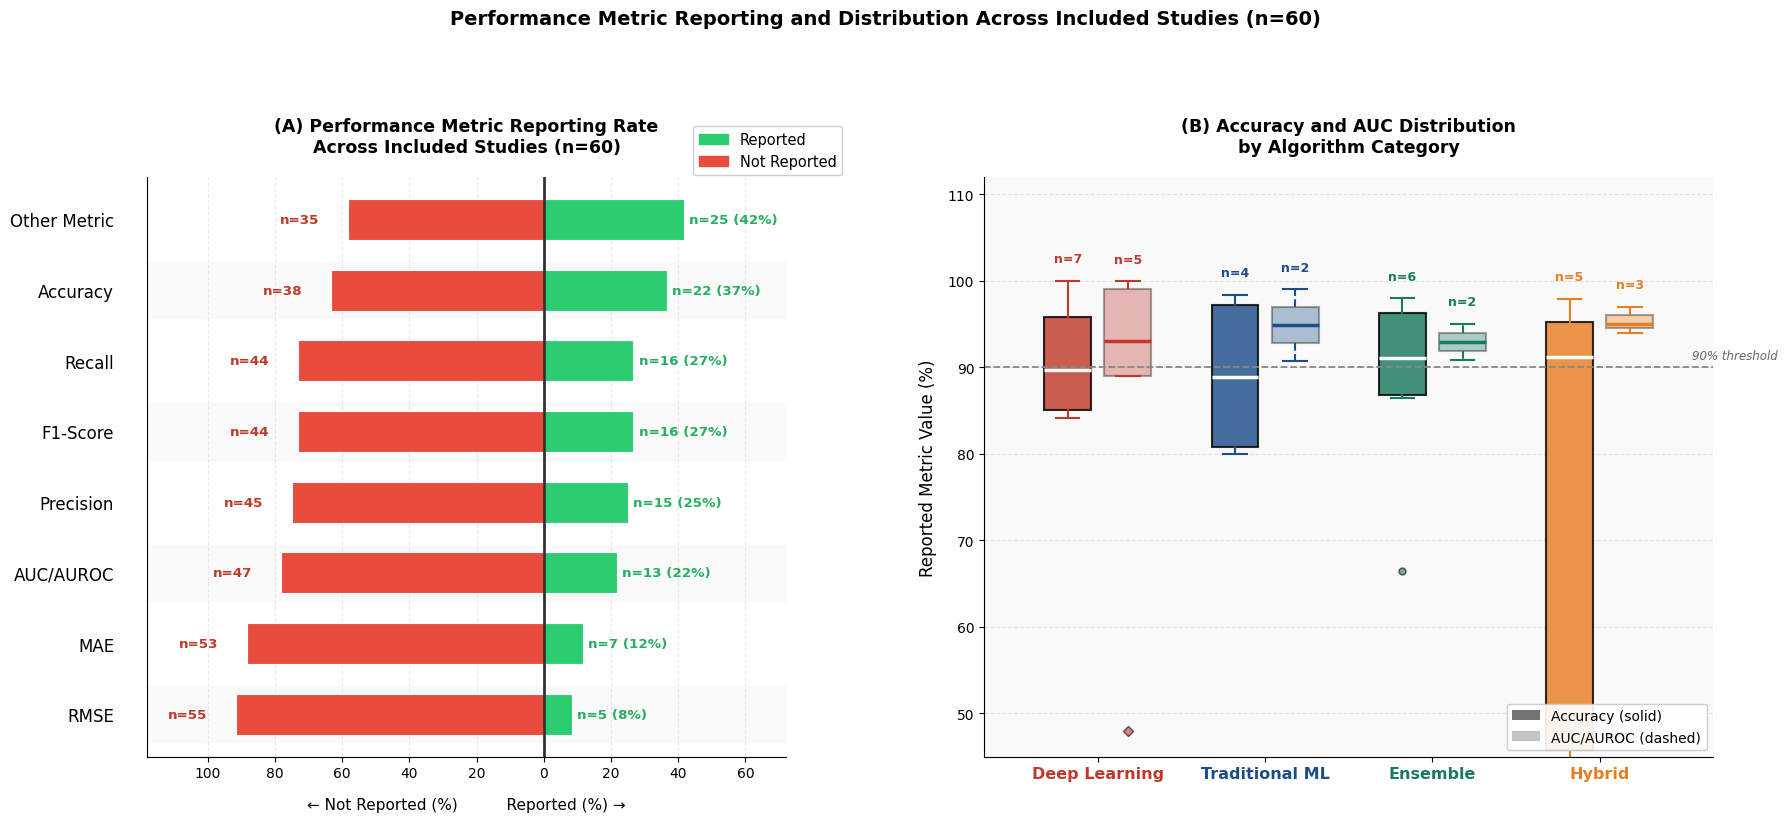

✅ Figure 13 — Legend position finalized (no overlap)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import re # Import re for regex operations

fig = plt.figure(figsize=(18, 8.4))
fig.patch.set_facecolor('#ffffff')

gs = gridspec.GridSpec(1, 2, width_ratios=[1.4, 1.6],
                       wspace=0.29,
                       left=0.09, right=0.96,
                       top=0.82, bottom=0.13)

total = 60

# ========================= PANEL A =========================
metrics_order = ['RMSE', 'MAE', 'AUC/AUROC', 'Precision',
                 'F1-Score', 'Recall', 'Accuracy', 'Other Metric']

reported_n = [5, 7, 13, 15, 16, 16, 22, 25]
not_rep_n  = [total - r for r in reported_n]
rep_pcts   = [r / total * 100 for r in reported_n]
not_pcts   = [n / total * 100 for n in not_rep_n]

C_REP  = '#2ecc71'
C_NREP = '#e74c3c'

ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#ffffff')

y = np.arange(len(metrics_order))

# Bars
ax1.barh(y, rep_pcts, height=0.58, color=C_REP, edgecolor='white', linewidth=0.8, zorder=3)
ax1.barh(y, [-p for p in not_pcts], height=0.58, color=C_NREP, edgecolor='white', linewidth=0.8, zorder=3)

# Reported labels (right side)
for i, (pct, n) in enumerate(zip(rep_pcts, reported_n)):
    ax1.text(pct + 1.6, i, f'n={n} ({pct:.0f}%)',
             va='center', ha='left', fontsize=9.7, color='#27ae60', fontweight='bold')

# Not Reported labels — Far left
for i, (pct, n) in enumerate(zip(not_pcts, not_rep_n)):
    ax1.text(-pct - 8.5, i, f'n={n}',
             va='center', ha='right', fontsize=9.7, color='#c0392b', fontweight='bold')

ax1.axvline(0, color='#333333', lw=2, zorder=5)

# Alternating row shading
for i in range(0, len(metrics_order), 2):
    ax1.axhspan(i - 0.4, i + 0.4, color='#f8f8f8', alpha=0.65, zorder=0)

ax1.set_yticks(y)
ax1.set_yticklabels(metrics_order, fontsize=12, ha='right')
ax1.yaxis.set_tick_params(pad=24)

ax1.set_xlim(-118, 72)
ax1.set_ylim(-0.6, len(metrics_order) - 0.4)

ticks = np.arange(-100, 61, 20)
ax1.set_xticks(ticks)
ax1.set_xticklabels([str(abs(int(t))) for t in ticks], fontsize=10)

ax1.set_xlabel('← Not Reported (%)          Reported (%) →',
               fontsize=11, labelpad=12)

ax1.set_title('(A) Performance Metric Reporting Rate\nAcross Included Studies (n=60)',
              fontsize=12.5, fontweight='bold', pad=18)

ax1.grid(axis='x', linestyle='--', alpha=0.25, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', length=0)

# === LEGEND FIXED: Placed in clean area (upper right but shifted inside) ===
leg_patches = [
    mpatches.Patch(color=C_REP, label='Reported'),
    mpatches.Patch(color=C_NREP, label='Not Reported')
]
ax1.legend(handles=leg_patches, fontsize=10.5, loc='upper right',
           framealpha=0.97, edgecolor='#cccccc', bbox_to_anchor=(1.1, 1.1))

# ========================= PANEL B =========================
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#f9f9f9')

algo_cats   = ['Deep Learning', 'Traditional ML', 'Ensemble', 'Hybrid']
algo_colors = ['#c0392b', '#1d4e89', '#1a7a5e', '#e67e22']

x_base = np.arange(len(algo_cats))
offset = 0.18
w_box  = 0.28

# --- Helper functions (copied from CELL 26 for self-containment) ---
not_reported_patterns = [
    'not report', 'not applicable', 'n/a',
    'no\n', '^no$', 'none', '—', 'not stated',
    'not provided', 'not given'
]

def is_not_reported(val):
    if pd.isna(val): return True
    s = str(val).strip().lower()
    for pat in not_reported_patterns:
        if re.search(pat, s): return True
    # if no digit at all -> not reported
    if not re.search(r'\d', s): return True
    return False

def extract_first_number(val):
    """Extract first percentage or decimal from string."""
    if pd.isna(val): return None
    s = str(val)
    # try percentage first
    pct = re.search(r'(\d+\.?\d*)\s*%', s)
    if pct: return float(pct.group(1))
    # try decimal 0.xx
    dec = re.search(r'\b(0\.\d+)\b', s)
    if dec: return float(dec.group(1)) * 100
    # try plain number > 50 (likely accuracy %)
    num = re.search(r'\b(\d{2,3}\.?\d*)\b', s)
    if num:
        v = float(num.group(1))
        if 50 <= v <= 100: return v
    return None

# --- Populate acc_by_algo and auc_by_algo ---
acc_by_algo = {algo_cat: [] for algo_cat in algo_cats}
auc_by_algo = {algo_cat: [] for algo_cat in algo_cats}

for index, row in df.iterrows():
    algo_cat = row['AlgoCat_clean']

    if algo_cat not in algo_cats: # Only consider categories relevant to the plot
        continue

    # Process Accuracy
    acc_val_raw = row['Accuracy reported ']
    if not is_not_reported(acc_val_raw):
        num = extract_first_number(acc_val_raw)
        if num is not None:
            acc_by_algo[algo_cat].append(num)

    # Process AUC/AUROC
    auc_val_raw = row['AUC or AUROC reported']
    if not is_not_reported(auc_val_raw):
        num = extract_first_number(auc_val_raw)
        if num is not None:
            auc_by_algo[algo_cat].append(num)

for i, (algo, color) in enumerate(zip(algo_cats, algo_colors)):
    acc = acc_by_algo[algo]
    auc = auc_by_algo[algo]

    if len(acc) >= 2:
        ax2.boxplot(acc, positions=[x_base[i] - offset], widths=w_box,
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.82, linewidth=1.5),
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(color=color, linewidth=1.5),
                    capprops=dict(color=color, linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor=color, markersize=5, alpha=0.6))
        ax2.text(x_base[i] - offset, max(acc) + 1.8, f'n={len(acc)}',
                 ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')

    if len(auc) >= 2:
        ax2.boxplot(auc, positions=[x_base[i] + offset], widths=w_box,
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.35, linewidth=1.5, linestyle='--'),
                    medianprops=dict(color=color, linewidth=2.5),
                    whiskerprops=dict(color=color, linewidth=1.5, linestyle='--'),
                    capprops=dict(color=color, linewidth=1.5),
                    flierprops=dict(marker='D', markerfacecolor=color, markersize=5, alpha=0.6))
        ax2.text(x_base[i] + offset, max(auc) + 1.8, f'n={len(auc)}',
                 ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')

ax2.axhline(90, color='#888888', linestyle='--', lw=1.3, zorder=2)
ax2.text(3.55, 91, '90% threshold', fontsize=8.5, color='#666666', style='italic')

ax2.set_xticks(x_base)
ax2.set_xticklabels(algo_cats, fontsize=11.5, fontweight='bold')
for tick, color in zip(ax2.get_xticklabels(), algo_colors):
    tick.set_color(color)

ax2.set_ylabel('Reported Metric Value (%)', fontsize=12, labelpad=8)
ax2.set_ylim(45, 112)
ax2.set_title('(B) Accuracy and AUC Distribution\nby Algorithm Category',
              fontsize=12.5, fontweight='bold', pad=18)

ax2.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)

acc_patch = mpatches.Patch(facecolor='#555555', alpha=0.82, label='Accuracy (solid)')
auc_patch = mpatches.Patch(facecolor='#555555', alpha=0.35, label='AUC/AUROC (dashed)')
ax2.legend(handles=[acc_patch, auc_patch], fontsize=10, loc='lower right',
           framealpha=0.92, edgecolor='#cccccc')

# ========================= MAIN TITLE & FOOTER =========================
fig.suptitle('Performance Metric Reporting and Distribution Across Included Studies (n=60)',
             fontsize=14, fontweight='bold', y=1.02)


plt.savefig(f'{SAVE_DIR}/fig13_performance_metrics.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("✅ Figure 13 — Legend position finalized (no overlap)")

## CELL 28 — Figure 14: Year × Country Research Heatmap

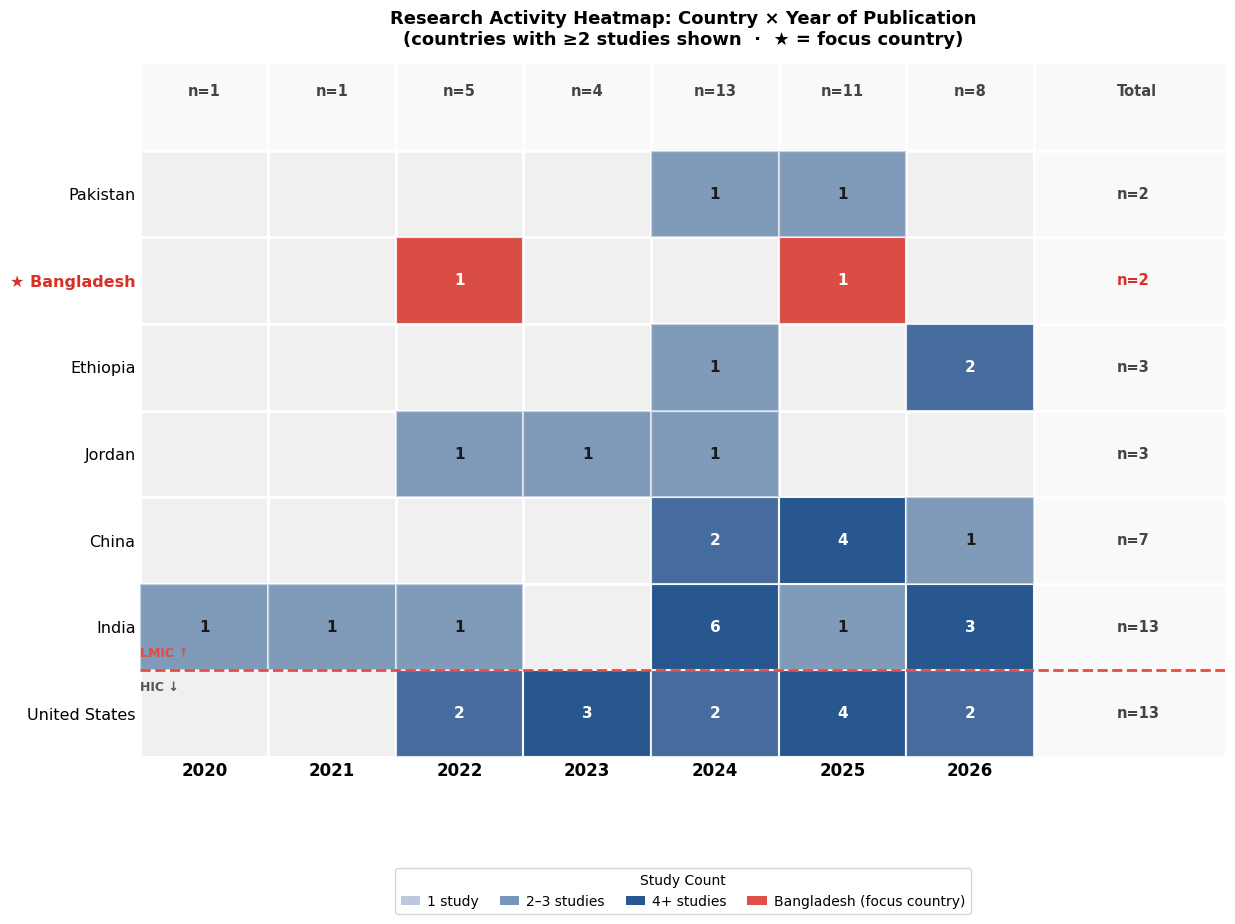

Saved: fig14_country_year_heatmap.pdf


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import re

# ── Data ──────────────────────────────────────────────────────────────────────
# Keep countries with ≥ 2 studies total
country_counts = df['Country_clean'].value_counts()
countries_keep = country_counts[country_counts >= 2].index.tolist()

df_map = df[df['Country_clean'].isin(countries_keep)].copy()

years     = sorted(df['Year of publication'].unique())
countries = sorted(countries_keep,
                   key=lambda c: country_counts[c],
                   reverse=True)

# Build matrix: rows = countries, cols = years
matrix = pd.DataFrame(0, index=countries, columns=years)
for _, row in df_map.iterrows():
    c = row['Country_clean']
    y = row['Year of publication']
    if c in matrix.index and y in matrix.columns:
        matrix.loc[c, y] += 1

# Row totals
row_totals = matrix.sum(axis=1)

# ── Color: white → deep blue, with red for Bangladesh ────────────────────────
cmap_base = plt.cm.Blues

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f9f9f9')

n_countries = len(countries)
n_years     = len(years)

for i, country in enumerate(countries):
    for j, year in enumerate(years):
        val = matrix.loc[country, year]

        # background cell
        bg = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                            facecolor='#f0f0f0',
                            edgecolor='white',
                            linewidth=1.5, zorder=1)
        ax.add_patch(bg)

        if val > 0:
            # Bangladesh = red, others = blue intensity
            if country == 'Bangladesh':
                intensity = '#d73027'
                alpha     = 0.85
            else:
                alpha     = min(0.25 + val * 0.28, 0.95)
                intensity = '#1d4e89'

            cell = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                  facecolor=intensity,
                                  alpha=alpha,
                                  edgecolor='white',
                                  linewidth=1.5, zorder=2)
            ax.add_patch(cell)

            tc = 'white' if (val >= 2 or country == 'Bangladesh') \
                         else '#1a1a1a'
            ax.text(j, i, str(int(val)),
                    ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color=tc, zorder=3)

# Row totals on right
for i, country in enumerate(countries):
    tot = int(row_totals[country])
    ax.text(n_years - 0.5 + 0.65, i,
            f'n={tot}',
            ha='left', va='center',
            fontsize=10.5, fontweight='bold',
            color='#d73027' if country == 'Bangladesh'
                            else '#444444')

# Column totals on top
col_totals = matrix.sum(axis=0)
for j, year in enumerate(years):
    tot = int(col_totals[year])
    ax.text(j, n_countries - 0.5 + 0.6,
            f'n={tot}',
            ha='center', va='bottom',
            fontsize=10.5, fontweight='bold',
            color='#444444')

# ── Axes ─────────────────────────────────────────────────────────────────────
ax.set_xlim(-0.5, n_years - 0.5 + 1.5)
ax.set_ylim(-0.5, n_countries - 0.5 + 1.0)

ax.set_xticks(range(n_years))
ax.set_xticklabels(years, fontsize=12, fontweight='bold')
ax.xaxis.set_ticks_position('bottom')

ax.set_yticks(range(n_countries))
yticklabels = []
for c in countries:
    if c == 'Bangladesh':
        yticklabels.append(f'★ {c}')
    else:
        yticklabels.append(c)
ax.set_yticklabels(yticklabels, fontsize=11.5)

# Colour Bangladesh y-label red
for tick, country in zip(ax.get_yticklabels(), countries):
    if country == 'Bangladesh':
        tick.set_color('#d73027')
        tick.set_fontweight('bold')

ax.tick_params(length=0)
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

# Minor grid
ax.set_xticks(np.arange(-0.5, n_years,     1), minor=True)
ax.set_yticks(np.arange(-0.5, n_countries, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', length=0)

# ── LMIC divider line ─────────────────────────────────────────────────────────
# Countries: USA, India, China are HIC → draw divider after them
hic_countries = [c for c in countries
                 if df[df['Country_clean']==c]['Income_clean'].iloc[0]
                 == 'High income']
lmic_countries = [c for c in countries if c not in hic_countries]

# find boundary
boundary = None
for i, c in enumerate(countries):
    if c in lmic_countries:
        boundary = i - 0.5
        break

if boundary:
    ax.axhline(boundary, color='#e74c3c',
               lw=2.0, linestyle='--', zorder=4)
    ax.text(-0.5, boundary + 0.12,
            'LMIC ↑',
            fontsize=9, color='#e74c3c',
            fontweight='bold', va='bottom')
    ax.text(-0.5, boundary - 0.12,
            'HIC ↓',
            fontsize=9, color='#555555',
            fontweight='bold', va='top')

# ── Annotation ────────────────────────────────────────────────────────────────
ax.text(n_years - 0.5 + 0.65,
        n_countries - 0.5 + 0.6,
        'Total',
        ha='left', va='bottom',
        fontsize=10.5, fontweight='bold',
        color='#444444')

ax.set_title(
    'Research Activity Heatmap: Country × Year of Publication\n'
    '(countries with ≥2 studies shown  ·  ★ = focus country)',
    fontsize=13, fontweight='bold', pad=14)

# ── Horizontal Legend Below Plot ──────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor='#1d4e89', alpha=0.3, label='1 study'),
    mpatches.Patch(facecolor='#1d4e89', alpha=0.6, label='2–3 studies'),
    mpatches.Patch(facecolor='#1d4e89', alpha=0.95, label='4+ studies'),
    mpatches.Patch(facecolor='#d73027', alpha=0.85, label='Bangladesh (focus country)'),
]

ax.legend(handles=legend_patches,
          title='Study Count',
          title_fontsize=10, fontsize=10,
          loc='upper center',          # Anchors the top-center of the legend box
          bbox_to_anchor=(0.5, -0.15), # Moves the anchor point below the x-axis
          ncol=4,                      # Arranges items in a single horizontal row
          frameon=True,
          edgecolor='#cccccc',
          handlelength=1.4,
          columnspacing=1.5,
          handletextpad=0.5)

# ── Caption ───────────────────────────────────────────────────────────────────
# Adjusted y-coordinate to sit below the new legend position


plt.savefig(f'{SAVE_DIR}/fig14_country_year_heatmap.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig14_country_year_heatmap.pdf")

In [ ]:
# CELL 29 — Install networkx
!pip install networkx -q

## CELL 30 — Figure 15: Algorithm Co-occurrence Network

In [ ]:
# CELL 31 — Install wordcloud
!pip install wordcloud -q

## CELL 32 — Inspect paper titles first

In [ ]:
# CELL 32 — Inspect paper titles

print(f"Total titles: {len(df)}")
print()
for i, title in enumerate(df['Title'].values):
    print(f"[{i+1}] {title}")

Total titles: 60

[1] An Explainable Attention-Augmented LSTM Model for Robust Real-Time Detection of Driving Behavior Patterns and Road Anomalies in Smart Transportation Networks
[2] Automatic Accident Detection, Segmentation and Duration Prediction Using Machine Learning
[3] A hybrid ARIMA-BP approach for superior accuracy in predicting traffic accident losses.
[4] Performance of Traffic Accidents' Prediction Models
[5] Machine learning for predictions of road traffic accidents and spatial network analysis for safe routing on accident and congestion-prone road networks
[6] Research on Traffic Accident Risk Prediction Method Based on Spatial and Visual Semantics
[7] STCAGNN-RNKDE: a traffic accident prediction model for spatiotemporal combinatorial attention graph neural networks using Ripley's K and network kernel density estimation
[8] Using Machine Learning Models to Forecast Severity Level of Traffic Crashes by R Studio and ArcGIS
[9] Exploring the Utility of Auto-machine Learning

## CELL 33 — Figure 15: Word Cloud from Paper Titles


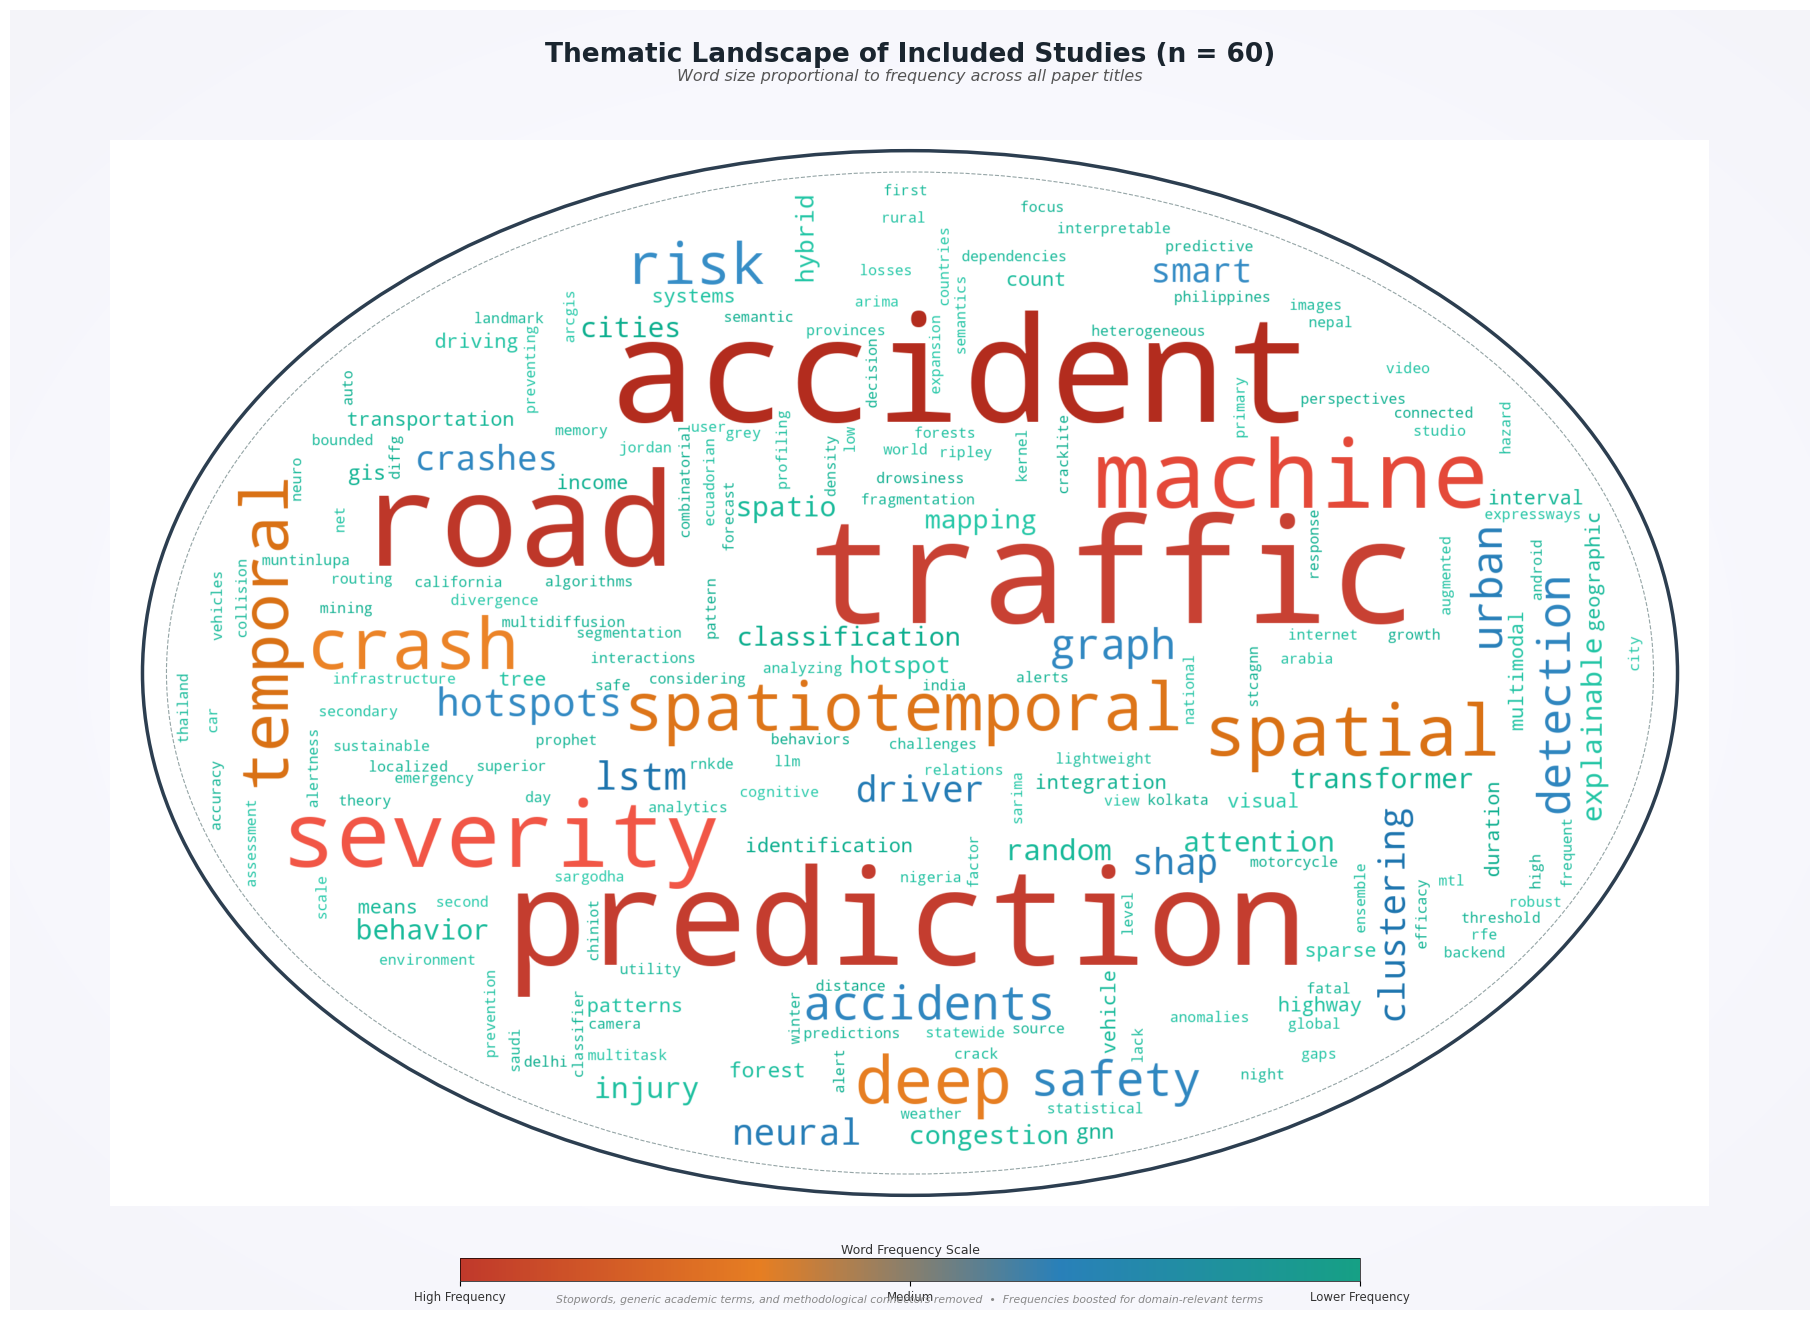

✅  Saved: fig15_wordcloud_titles.pdf / .png


In [ ]:
# CELL 33 — Figure 15: Word Cloud from Paper Titles (Enhanced Aesthetic Version)

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── All 60 titles ─────────────────────────────────────────────────────────────
titles = [
    "An Explainable Attention-Augmented LSTM Model for Robust Real-Time Detection of Driving Behavior Patterns and Road Anomalies in Smart Transportation Networks",
    "Automatic Accident Detection Segmentation and Duration Prediction Using Machine Learning",
    "A hybrid ARIMA-BP approach for superior accuracy in predicting traffic accident losses",
    "Performance of Traffic Accidents Prediction Models",
    "Machine learning for predictions of road traffic accidents and spatial network analysis for safe routing on accident and congestion-prone road networks",
    "Research on Traffic Accident Risk Prediction Method Based on Spatial and Visual Semantics",
    "STCAGNN-RNKDE a traffic accident prediction model for spatiotemporal combinatorial attention graph neural networks using Ripley K and network kernel density estimation",
    "Using Machine Learning Models to Forecast Severity Level of Traffic Crashes by R Studio and ArcGIS",
    "Exploring the Utility of Auto-machine Learning in Predicting Traffic Accident Severity in Jordan",
    "Harnessing the integrated statistical machine learning for traffic crash injury-severity modeling",
    "A Machine Learning Approach for Classifying Road Accident Hotspots",
    "Encoding global semantic and localized geographic spatial-temporal relations for traffic accident risk prediction",
    "Utilizing GIS and Machine Learning for Traffic Accident Prediction in Urban Environment",
    "Learning spatial patterns and temporal dependencies for traffic accident severity prediction A deep learning approach",
    "Advancing urban traffic accident forecasting through sparse spatio-temporal dynamic learning",
    "Traffic accident prediction method based on multi-view spatial-temporal learning",
    "Modeling Road User Interactions with Dynamic Graph Attention Networks for Traffic Crash Prediction",
    "SARIMA vs Prophet Comparative Efficacy in Forecasting Traffic Accidents Across Ecuadorian Provinces",
    "DiffG-MTL A Dynamic Multidiffusion Graph Network for Multitask Traffic Accident Prediction",
    "MobileNetV3 Transformer-Based Prediction of Highway Accident Severity",
    "Time and Distance Gaps of Primary-Secondary Crashes Prediction and Analysis Using Random Forests and SHAP Model",
    "Severity Prediction of Highway Crashes in Saudi Arabia Using Machine Learning Techniques",
    "Risk prediction for winter road accidents on expressways",
    "A New Spatio-Temporal Neural Network Approach for Traffic Accident Forecasting",
    "LLM Multimodal Traffic Accident Forecasting",
    "Bounded memory based frequent pattern growth approach with deep neural network and decision tree for road accident prediction",
    "Advancements in Machine Learning and Data Mining Techniques for Collision Prediction and Hazard Detection in Internet of Vehicles",
    "Spatiotemporal Risk Mapping of Statewide Weather-related Traffic Crashes A Machine Learning Approach",
    "Deep Learning-Based Traffic Accident Prediction An Investigative Study for Enhanced Road Safety",
    "CrackLite-Net A Sustainable Transportation-Oriented Real-Time Lightweight Network for Adaptive Road Crack Detection",
    "Enhancing Emergency Response in Road Accidents A Severity Prediction Framework Using RF-RFE and Deep Learning Model",
    "Road traffic accident classification using a sparse video transformer and adaptive fragmentation",
    "Deep Learning and LSTM Integration for Analyzing Driver Behaviors",
    "Predicting Road Crash Severity Using Classifier Models and Crash Hotspots",
    "Analysis and Prediction of the Interval Duration between the First and Second Accidents considering the Spatiotemporal Threshold",
    "Neuro-cognitive AI-driven system for preventing road accidents through driver drowsiness alerts",
    "Machine Learning Framework for Real-Time Assessment of Traffic Safety Utilizing Connected Vehicle Data",
    "Accident Prediction Model Using Divergence Between Visual Attention and Focus of Expansion in Vehicle-Mounted Camera Images",
    "A Hybrid K-Means Clustering and Ensemble Model for Predicting Road Traffic Accident Severity",
    "Evaluation of tree-based machine learning algorithms for accident risk mapping caused by driver lack of alertness at a national scale",
    "Road Traffic Accident Risk Prediction and Key Factor Identification Framework Based on Explainable Deep Learning",
    "Analysis and Prediction of Traffic Accidents Based on Interpretable Spatial Machine Learning A Case Study in California",
    "Analysis and Prediction of Road Accidents in Nepal by Grey System Theory",
    "Predictive Analysis Through Machine Learning Fatal Road Crashes in Delhi India",
    "Exploring Spatio-Temporal Multimodal Data for Accident Count Prediction A Case Study of Kolkata",
    "Examining Car Accident Prediction Techniques and Road Traffic Congestion A Comparative Analysis of Road Safety and Prevention of World Challenges in Low-Income and High-Income Countries",
    "ESTIMATION OF ROAD ACCIDENT SEVERITY USING K-MEANS CLUSTERING OF SPATIO-TEMPORAL DATA WITH BACKEND SPATIAL DATA INFRASTRUCTURE",
    "A random forest and SHAP-based analysis of motorcycle crash severity in Thailand Urban-rural and day-night perspectives",
    "Landmark-Aware Heterogeneous Graph Framework for Multi-Source Road Crash Data Integration in Nigeria",
    "Data-Driven Urban Traffic Injury Profiling Using Machine Learning and Spatiotemporal Analytics in Muntinlupa City Philippines",
    "Hybrid Deep Learning for Accident Detection with an Android-Based Alert System",
    "Exploring hotspots of traffic accidents in Chiniot-Sargodha Road Punjab Pakistan",
    "Road Accident Analysis and Hotspot Prediction using Clustering",
    "Towards a Spatially Intelligent Approach for Road Safety Analysis in Tunisia Spatial Autocorrelation Approach vs Crash Count Models",
    "Exploring Spatiotemporal Relational Learning With TimeSformer for Identifying the Severity of the Road Accidents",
    "A Computational Intelligence GNN-LSTM Framework for Spatiotemporal Prediction of Traffic Accident Severity in Smart Cities Using SHAP XAI",
    "Temporal trends and forecasting of road traffic crashes in Amhara region Ethiopia a time series approach",
    "Geographic Information Systems and Confidence Interval with Deep Learning Techniques for Traffic Management Systems in Smart Cities",
    "Applications of QGIS and machine learning for road crash spot identification",
    "Modeling and Real-Time classification of driving behavior in mixed traffic A naturalistic study using rule-Based labeling and supervised learning",
]

# ── Combine all titles ────────────────────────────────────────────────────────
text = ' '.join(titles)

# ── Custom stopwords ──────────────────────────────────────────────────────────
custom_stops = set(STOPWORDS) | {
    'using', 'based', 'study', 'approach', 'method',
    'model', 'models', 'analysis', 'case', 'new',
    'via', 'towards', 'used', 'use', 'utilized',
    'utilizing', 'A', 'An', 'The', 'for', 'of',
    'in', 'on', 'and', 'with', 'to', 'from',
    'by', 'through', 'a', 'an', 'the', 'vs',
    'between', 'across', 'within', 'among',
    'driven', 'oriented', 'aware', 'based',
    'driven', 'related', 'prone', 'mounted',
    'caused', 'enhanced', 'integrated',
    'comparative', 'examining', 'exploring',
    'advancing', 'enhancing', 'harnessing',
    'encoding', 'learning', 'identifying',
    'predicting', 'forecasting', 'classifying',
    'modeling', 'estimation', 'evaluation',
    'applications', 'advancements', 'research',
    'performance', 'framework', 'system',
    'network', 'networks', 'data', 'technique',
    'techniques', 'investigative', 'automatic',
    'adaptive', 'dynamic', 'multi', 'time',
    'real', 'key',
}

# ── Frequency dict with domain boosts ────────────────────────────────────────
words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
freq  = Counter(w for w in words
                if w not in {s.lower() for s in custom_stops})

boosts = {
    'accident':        4.5,
    'traffic':         4.0,
    'prediction':      4.0,
    'road':            3.8,
    'severity':        3.5,
    'spatiotemporal':  3.8,
    'spatial':         3.2,
    'temporal':        2.8,
    'machine':         3.0,
    'deep':            2.8,
    'crash':           3.2,
    'hotspot':         2.8,
    'risk':            2.8,
    'lstm':            2.5,
    'gnn':             2.2,
    'random':          2.2,
    'forest':          2.2,
    'graph':           2.2,
    'urban':           2.2,
    'safety':          2.8,
    'smart':           2.0,
    'cities':          2.0,
    'gis':             2.2,
    'shap':            2.2,
    'clustering':      2.2,
    'transformer':     2.0,
    'driver':          2.2,
    'behavior':        2.0,
    'injury':          2.2,
    'neural':          2.2,
    'detection':       2.0,
    'hotspots':        2.5,
    'mapping':         1.8,
    'congestion':      1.8,
    'explainable':     2.0,
    'convolutional':   1.8,
    'classification':  1.8,
}

freq_boosted = {}
for word, count in freq.items():
    boost = boosts.get(word, 1.0)
    freq_boosted[word] = int(count * boost * 25)

# Remove very low-frequency noise
freq_boosted = {k: v for k, v in freq_boosted.items() if v >= 10}

# ── Create elliptical mask for word cloud shape ───────────────────────────────
mask_width, mask_height = 2400, 1600
mask = Image.new('RGB', (mask_width, mask_height), (255, 255, 255))
draw = ImageDraw.Draw(mask)

# Draw filled dark ellipse as mask region
draw.ellipse(
    [80, 60, mask_width - 80, mask_height - 60],
    fill=(0, 0, 0)
)
mask_array = np.array(mask)

# ── Custom beautiful colormap ─────────────────────────────────────────────────
# Deep navy → cobalt → teal → crimson → orange gradient
colors_hex = [
    '#C0392B',   # crimson red     (largest words)
    '#E74C3C',   # soft red
    '#E67E22',   # warm orange
    '#2980B9',   # cobalt blue
    '#1ABC9C',   # teal
    '#16A085',   # dark teal       (smallest words)
]

def make_color_func(colors):
    """Return a colour function that cycles through a custom palette."""
    from matplotlib.colors import to_rgb
    rgb_list = [tuple(int(c * 255) for c in to_rgb(h)) for h in colors]
    rng = np.random.default_rng(42)

    def color_func(word, font_size, position, orientation,
                   random_state=None, **kwargs):
        # Map font_size to color: larger → earlier in list (warm/red)
        max_fs, min_fs = 220, 8
        t = (font_size - min_fs) / max(max_fs - min_fs, 1)
        idx = int((1 - t) * (len(rgb_list) - 1))
        idx = np.clip(idx, 0, len(rgb_list) - 1)
        r, g, b = rgb_list[idx]
        # Slight random jitter so neighboring words differ subtly
        jitter = rng.integers(-15, 15)
        r = int(np.clip(r + jitter, 0, 255))
        g = int(np.clip(g + jitter, 0, 255))
        b = int(np.clip(b + jitter, 0, 255))
        return f'rgb({r},{g},{b})'

    return color_func

color_func = make_color_func(colors_hex)

# ── Generate word cloud ───────────────────────────────────────────────────────
wc = WordCloud(
    width             = mask_width,
    height            = mask_height,
    background_color  = 'white',
    max_words         = 200,
    max_font_size     = 220,
    min_font_size     = 11,
    prefer_horizontal = 0.72,
    collocations      = False,
    relative_scaling  = 0.52,
    margin            = 6,
    random_state      = 42,
    mask              = mask_array,
    contour_width     = 0,
    font_path         = None,   # uses default; swap for a custom TTF if desired
).generate_from_frequencies(freq_boosted)

# Apply custom colour function
wc.recolor(color_func=color_func)

# ── Build figure with layered aesthetic ──────────────────────────────────────
fig = plt.figure(figsize=(18, 13), facecolor='white')

# ── Subtle radial gradient background ────────────────────────────────────────
ax_bg = fig.add_axes([0, 0, 1, 1], zorder=0)
ax_bg.set_xlim(0, 1); ax_bg.set_ylim(0, 1)
ax_bg.axis('off')

gradient = np.zeros((500, 800, 3))
for i in range(500):
    for j in range(800):
        dist = np.sqrt(((i/500) - 0.5)**2 + ((j/800) - 0.5)**2)
        val  = 1.0 - 0.06 * dist
        gradient[i, j] = [val, val, np.clip(val + 0.02, 0, 1)]
ax_bg.imshow(gradient, extent=[0, 1, 0, 1], aspect='auto',
             interpolation='bilinear', zorder=0)

# ── Main word-cloud axes ──────────────────────────────────────────────────────
ax = fig.add_axes([0.03, 0.08, 0.94, 0.82], zorder=1)
ax.set_facecolor('none')
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')

# ── Decorative thin border ring around the cloud ─────────────────────────────
from matplotlib.patches import Ellipse
ell_outer = Ellipse((0.5, 0.5), 0.96, 0.98,
                    transform=ax.transAxes,
                    linewidth=2.5, edgecolor='#2C3E50',
                    facecolor='none', zorder=3)
ell_inner = Ellipse((0.5, 0.5), 0.93, 0.94,
                    transform=ax.transAxes,
                    linewidth=0.8, edgecolor='#95A5A6',
                    facecolor='none', linestyle='--', zorder=3)
ax.add_patch(ell_outer)
ax.add_patch(ell_inner)

# ── Title ─────────────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.975,
    'Thematic Landscape of Included Studies (n = 60)',
    ha='center', va='top',
    fontsize=19, fontweight='bold', color='#1A252F',
    fontfamily='DejaVu Sans',
)
fig.text(
    0.5, 0.955,
    'Word size proportional to frequency across all paper titles',
    ha='center', va='top',
    fontsize=11.5, color='#555555', style='italic',
    fontfamily='DejaVu Sans',
)

# ── Colour-legend bar (large → small) ────────────────────────────────────────
legend_ax = fig.add_axes([0.25, 0.022, 0.50, 0.018])
cmap_custom = LinearSegmentedColormap.from_list(
    'custom', ['#C0392B', '#E67E22', '#2980B9', '#16A085'], N=256)
cb = plt.colorbar(
    plt.cm.ScalarMappable(cmap=cmap_custom),
    cax=legend_ax, orientation='horizontal'
)
cb.set_ticks([0, 0.5, 1.0])
cb.set_ticklabels(['High Frequency', 'Medium', 'Lower Frequency'],
                  fontsize=8.5, color='#333333')
cb.outline.set_linewidth(0.5)
legend_ax.set_title('Word Frequency Scale',
                    fontsize=9, color='#333333', pad=3)

# ── Footer note ───────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.004,
    'Stopwords, generic academic terms, and methodological connectors removed  •  Frequencies boosted for domain-relevant terms',
    ha='center', va='bottom', fontsize=7.8, color='#888888', style='italic'
)

# ── Save & show ───────────────────────────────────────────────────────────────
plt.savefig(
    f'{SAVE_DIR}/fig15_wordcloud_titles.pdf',
    dpi=400, bbox_inches='tight', format='pdf',
    facecolor='white'
)
plt.savefig(
    f'{SAVE_DIR}/fig15_wordcloud_titles.png',
    dpi=300, bbox_inches='tight', format='png',
    facecolor='white'
)
plt.show()
print("✅  Saved: fig15_wordcloud_titles.pdf / .png")

In [ ]:
# CELL 34 — Install openpyxl
!pip install openpyxl -q

## CELL 35 — Inspect columns available for Table 1

In [ ]:
# CELL 35 — Inspect all columns for table construction

print("All columns:")
for i, col in enumerate(df.columns.tolist()):
    print(f"  [{i}] {col}")

All columns:
  [0] Covidence #
  [1] Study ID
  [2] Title
  [3] Reviewer Name
  [4] Title.1
  [5] Authors
  [6] Year of publication
  [7] Journal name
  [8] Country of study 
  [9] World Bank income classification
  [10] Data source type
  [11] Sample size — number of accidents
  [12] Study period covered by data
  [13] Geographic scope
  [14] Urban or rural setting
  [15] ML algorithm or algorithms used 
  [16] Algorithm category
  [17] Prediction task type
  [18] Training and test split method
  [19] Class imbalance addressed
  [20] Hyperparameter tuning reported
  [21] Spatial analysis method used 
  [22] Temporal resolution of analysis
  [23] Geographic unit of analysis 
  [24] Spatiotemporal framework type
  [25] Accuracy reported 
  [26] AUC or AUROC reported
  [27] F1-score reported 
  [28] Precision reported
  [29] Recall or sensitivity reported 
  [30] RMSE reported
  [31] MAE reported
  [32] Other metric and value 
  [33] Best performing algorithm in study 
  [34] Study condu

## CELL 36 — Generate All 3 Synthesis Tables

In [ ]:
# CELL 36 — Generate All 3 Synthesis Tables as Excel

import pandas as pd
import openpyxl
from openpyxl.styles import (Font, PatternFill, Alignment,
                              Border, Side, GradientFill)
from openpyxl.utils import get_column_letter
from openpyxl.utils.dataframe import dataframe_to_rows
import numpy as np

SAVE_DIR = '/content/drive/MyDrive/SLR FNN/'
# ── Helper: auto-fit column widths ────────────────────────────────────────────
def auto_fit(ws, max_width=60):
    for col in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            if cell.value:
                max_len = max(max_len, len(str(cell.value)))
        ws.column_dimensions[col_letter].width = min(max_len + 4, max_width)

# ── Helper: style header row ──────────────────────────────────────────────────
def style_header(ws, row_num, bg_color='1D4E89', font_color='FFFFFF'):
    for cell in ws[row_num]:
        cell.font      = Font(bold=True, color=font_color,
                              size=11, name='Calibri')
        cell.fill      = PatternFill('solid', fgColor=bg_color)
        cell.alignment = Alignment(wrap_text=True,
                                   vertical='center',
                                   horizontal='center')
        cell.border    = Border(
            bottom=Side(style='medium', color='FFFFFF'))

# ── Helper: style data rows ───────────────────────────────────────────────────
def style_rows(ws, start_row, zebra1='EBF3FB', zebra2='FFFFFF'):
    for i, row in enumerate(ws.iter_rows(
            min_row=start_row, max_row=ws.max_row)):
        bg = zebra1 if i % 2 == 0 else zebra2
        for cell in row:
            cell.fill      = PatternFill('solid', fgColor=bg)
            cell.alignment = Alignment(wrap_text=True,
                                       vertical='top',
                                       horizontal='left')
            cell.font      = Font(size=10, name='Calibri')
            cell.border    = Border(
                bottom=Side(style='thin', color='DDDDDD'))

def style_rob_cell(cell, val):
    colors = {
        'Low risk':     ('27AE60', 'FFFFFF'),
        'Unclear risk': ('F39C12', 'FFFFFF'),
        'High risk':    ('E74C3C', 'FFFFFF'),
    }
    if val in colors:
        bg, fg = colors[val]
        cell.fill = PatternFill('solid', fgColor=bg)
        cell.font = Font(bold=True, color=fg,
                         size=10, name='Calibri')
        cell.alignment = Alignment(horizontal='center',
                                   vertical='center')

# ─────────────────────────────────────────────────────────────────────────────
# TABLE 1 — Characteristics of Included Studies
# ─────────────────────────────────────────────────────────────────────────────
t1_cols = {
    'Study ID':              'Study ID',
    'Title':                 'Title',
    'Year':                  'Year of publication',
    'Journal':               'Journal name',
    'Country':               'Country_clean',
    'Income Group':          'Income_clean',
    'Data Source':           'Data source type',
    'Sample Size':           'Sample size — number of accidents',
    'Study Period':          'Study period covered by data',
    'Geographic Scope':      'GeoScope_clean',
    'Urban / Rural':         'Urban or rural setting',
    'Algorithm(s) Used':     'ML algorithm or algorithms used ',
    'Algorithm Category':    'AlgoCat_clean',
    'Prediction Task':       'Task_clean',
    'Spatiotemporal Framework': 'STFramework_clean',
    'Spatial Method':        'Spatial_bucket',
    'Temporal Resolution':   'Temporal_clean',
    'LMIC Study':            'Is_LMIC',
    'Bangladesh Study':      'Is_Bangladesh',
    'PROBAST Overall':       'PROBAST_overall',
}

t1 = pd.DataFrame()
for new_col, old_col in t1_cols.items():
    if old_col in df.columns:
        t1[new_col] = df[old_col].fillna('Not Reported')
    else:
        t1[new_col] = 'Not Reported'

t1['Bangladesh Study'] = t1['Bangladesh Study'].map(
    {True: 'Yes', False: 'No'}).fillna('No')
t1 = t1.reset_index(drop=True)
t1.index = t1.index + 1

# ─────────────────────────────────────────────────────────────────────────────
# TABLE 2 — ML Algorithm Performance Comparison
# ─────────────────────────────────────────────────────────────────────────────
t2_cols = {
    'Study ID':                   'Study ID',
    'Year':                       'Year of publication',
    'Country':                    'Country_clean',
    'Income Group':               'Income_clean',
    'Algorithm Category':         'AlgoCat_clean',
    'Algorithm(s) Used':          'ML algorithm or algorithms used ',
    'Best Performing Algorithm':  'Best performing algorithm in study ',
    'Prediction Task':            'Task_clean',
    'Accuracy':                   'Accuracy reported ',
    'AUC / AUROC':                'AUC or AUROC reported',
    'F1-Score':                   'F1-score reported ',
    'Precision':                  'Precision reported',
    'Recall / Sensitivity':       'Recall or sensitivity reported ',
    'RMSE':                       'RMSE reported',
    'MAE':                        'MAE reported',
    'Other Metric':               'Other metric and value ',
    'Class Imbalance Handled':    'Imbalance_clean',
    'Train/Test Split':           'Split_clean',
    'Hyperparameter Tuning':      'Hyperparameter tuning reported',
}

t2 = pd.DataFrame()
for new_col, old_col in t2_cols.items():
    if old_col in df.columns:
        t2[new_col] = df[old_col].fillna('Not Reported')
    else:
        t2[new_col] = 'Not Reported'

t2 = t2.reset_index(drop=True)
t2.index = t2.index + 1

# ─────────────────────────────────────────────────────────────────────────────
# TABLE 3 — PROBAST Risk of Bias Assessment
# ─────────────────────────────────────────────────────────────────────────────
t3_cols = {
    'Study ID':          'Study ID',
    'Year':              'Year of publication',
    'Country':           'Country_clean',
    'Income Group':      'Income_clean',
    'Algorithm Category':'AlgoCat_clean',
    'Participants':      'PROBAST_participants',
    'Predictors':        'PROBAST_predictors',
    'Outcome':           'PROBAST_outcome',
    'Analysis':          'PROBAST_analysis',
    'Overall ROB':       'PROBAST_overall',
    'Participants Notes':'PROBAST — Participants supporting text',
    'Predictors Notes':  'PROBAST — Predictors supporting text',
    'Outcome Notes':     'PROBAST — Outcome supporting text',
    'Analysis Notes':    'PROBAST — Analysis supporting text',
    'Overall Notes':     'PROBAST — Overall risk of bias supporting text',
    'Author Limitations':'Author stated limitations',
}

t3 = pd.DataFrame()
for new_col, old_col in t3_cols.items():
    if old_col in df.columns:
        t3[new_col] = df[old_col].fillna('Not Reported')
    else:
        t3[new_col] = 'Not Reported'

t3 = t3.reset_index(drop=True)
t3.index = t3.index + 1

# ─────────────────────────────────────────────────────────────────────────────
# Write to Excel with formatting
# ─────────────────────────────────────────────────────────────────────────────
output_path = f'{SAVE_DIR}/SLR_Synthesis_Tables.xlsx'
wb = openpyxl.Workbook()

# ── Sheet definitions ─────────────────────────────────────────────────────────
sheets = [
    ('Table 1 - Study Characteristics', t1,
     '1D4E89', 'Characteristics of 60 Included Studies'),
    ('Table 2 - Performance Metrics',   t2,
     '1A7A5E', 'ML Algorithm Performance Comparison'),
    ('Table 3 - PROBAST',               t3,
     'C0392B', 'PROBAST Risk of Bias Assessment'),
]

# Remove default sheet
wb.remove(wb.active)

for sheet_name, table, hdr_color, description in sheets:
    ws = wb.create_sheet(title=sheet_name)

    # ── Description row ───────────────────────────────────────────────────────
    ws.append([description])
    desc_cell = ws.cell(row=1, column=1)
    desc_cell.font      = Font(bold=True, size=13,
                               color='1a1a1a', name='Calibri')
    desc_cell.alignment = Alignment(horizontal='left',
                                    vertical='center')
    ws.row_dimensions[1].height = 28

    # ── n= row ────────────────────────────────────────────────────────────────
    ws.append([f'n = {len(table)} studies included'])
    n_cell = ws.cell(row=2, column=1)
    n_cell.font = Font(italic=True, size=10,
                       color='555555', name='Calibri')
    ws.row_dimensions[2].height = 18

    # blank row
    ws.append([])

    # ── Header ────────────────────────────────────────────────────────────────
    ws.append(['#'] + list(table.columns))
    style_header(ws, 4, bg_color=hdr_color)
    ws.row_dimensions[4].height = 32

    # ── Data rows ─────────────────────────────────────────────────────────────
    for idx, row in table.iterrows():
        ws.append([idx] + list(row.values))

    style_rows(ws, start_row=5)

    # ── Special: colour ROB cells in Table 3 ─────────────────────────────────
    if 'PROBAST' in sheet_name:
        rob_cols = ['Participants', 'Predictors',
                    'Outcome', 'Analysis', 'Overall ROB']
        header_row = [cell.value for cell in ws[4]]
        for rob_col in rob_cols:
            if rob_col in header_row:
                col_idx = header_row.index(rob_col) + 1
                for row_num in range(5, ws.max_row + 1):
                    cell = ws.cell(row=row_num, column=col_idx)
                    style_rob_cell(cell, str(cell.value))

    # ── Special: highlight Bangladesh rows ───────────────────────────────────
    if 'Characteristics' in sheet_name:
        header_row = [cell.value for cell in ws[4]]
        if 'Bangladesh Study' in header_row:
            bgd_col = header_row.index('Bangladesh Study') + 1
            for row_num in range(5, ws.max_row + 1):
                cell = ws.cell(row=row_num, column=bgd_col)
                if str(cell.value) == 'Yes':
                    for c in ws[row_num]:
                        c.fill = PatternFill('solid',
                                             fgColor='FDECEA')
                        c.font = Font(bold=True, size=10,
                                      color='C0392B',
                                      name='Calibri')

    # ── Freeze panes at row 5 (below header) ─────────────────────────────────
    ws.freeze_panes = 'B5'

    # ── Auto-fit columns ──────────────────────────────────────────────────────
    auto_fit(ws, max_width=55)

    # ── Row heights for data ──────────────────────────────────────────────────
    for row_num in range(5, ws.max_row + 1):
        ws.row_dimensions[row_num].height = 52

# ── Cover sheet ───────────────────────────────────────────────────────────────
cover = wb.create_sheet(title='README', index=0)
cover_content = [
    ['SLR Synthesis Tables'],
    ['Spatiotemporal Patterns and Machine Learning for Road Traffic'],
    ['Accident Prediction in Developing Countries'],
    [''],
    ['Sheet', 'Content', 'Rows'],
    ['Table 1 - Study Characteristics',
     'Full characteristics of all 60 included studies', '60'],
    ['Table 2 - Performance Metrics',
     'Algorithm performance metrics per study', '60'],
    ['Table 3 - PROBAST',
     'Risk of bias assessment across all PROBAST domains', '60'],
    [''],
    ['Notes:'],
    ['- Bangladesh studies highlighted in red in Table 1'],
    ['- PROBAST cells colour-coded: Green=Low, Orange=Unclear, Red=High'],
    ['- All data extracted by single reviewer with consensus review'],
    ['- Generated from Covidence extraction — 60 included papers'],
]

for r_idx, row in enumerate(cover_content, 1):
    for c_idx, val in enumerate(row, 1):
        cell = cover.cell(row=r_idx, column=c_idx, value=val)
        if r_idx == 1:
            cell.font = Font(bold=True, size=16,
                             color='1D4E89', name='Calibri')
        elif r_idx in [2, 3]:
            cell.font = Font(bold=True, size=12,
                             color='555555', name='Calibri')
        elif r_idx == 5:
            cell.font      = Font(bold=True, size=11,
                                  color='FFFFFF', name='Calibri')
            cell.fill      = PatternFill('solid', fgColor='1D4E89')
            cell.alignment = Alignment(horizontal='center')
        elif r_idx > 5 and r_idx <= 8:
            cell.font = Font(size=11, name='Calibri')
            if r_idx % 2 == 0:
                cell.fill = PatternFill('solid', fgColor='EBF3FB')

auto_fit(cover, max_width=70)
cover.row_dimensions[1].height = 36

# ── Save ──────────────────────────────────────────────────────────────────────
wb.save(output_path)
print(f"✓ Saved: SLR_Synthesis_Tables.xlsx")
print(f"  Table 1: {len(t1)} rows × {len(t1.columns)} columns")
print(f"  Table 2: {len(t2)} rows × {len(t2.columns)} columns")
print(f"  Table 3: {len(t3)} rows × {len(t3.columns)} columns")

✓ Saved: SLR_Synthesis_Tables.xlsx
  Table 1: 60 rows × 20 columns
  Table 2: 60 rows × 19 columns
  Table 3: 60 rows × 16 columns


## CELL 37 — Inspect the two new columns first

In [ ]:
# CELL 37 — Inspect new columns

print("Data source type:")
for v in df['Data source type'].value_counts().index:
    print(f"  {repr(v)}")

print()
print("Geographic unit of analysis:")
for v in df['Geographic unit of analysis '].value_counts().index:
    print(f"  {repr(v)}")

Data source type:
  'Mixed sources'
  'Sensor or telematics data'
  'Police records'
  'Other: Official records (NYC Open Data for traffic accidents, MesoWest for weather, and Google Maps API for POI data)'
  'Other: Official government records (National Institute of Statistics and Censuses - INEC and the National Transit Agency - ANT)'
  'Other: Official records (Hebei Provincial Highway Traffic Accident Dataset)'
  'Other: Official records (Iteris iPeMS database and high-resolution crash data)'
  'Other: Not explicitly detailed in the abstract, but indicates usage of accident locations and attributes for mining.'
  'Other: This is a literature review paper analyzing various data sources used in IoV safety, such as V2V, V2I, and sensor data'
  'Other: Official government records (National multi-source accident data from France)'
  'Other: Image-based dataset (Multi-class driver behavior dataset)'
  'Other: Official records (Addis Ababa City Administration Traffic Management Agency)'
 

## CELL 38 — Clean + Generate Figures 16, 17, 18, 19

In [ ]:
# CELL 38 — Figures 16, 17, 18, 19 — All separate files

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# CLEANING
# ─────────────────────────────────────────────────────────────────────────────

# ── Data Source Type ──────────────────────────────────────────────────────────
def clean_datasource(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip()
    if r == 'Mixed sources':              return 'Mixed Sources'
    if r == 'Sensor or telematics data':  return 'Sensor / Telematics'
    if r == 'Police records':             return 'Police Records'
    rl = r.lower()
    if 'police' in rl:                    return 'Police Records'
    if 'sensor' in rl or 'telematic' in rl: return 'Sensor / Telematics'
    if 'image' in rl or 'video' in rl or 'visual' in rl: return 'Image / Video'
    if 'kaggle' in rl or 'public' in rl:  return 'Publicly Available Dataset'
    if 'review' in rl or 'literature' in rl: return 'Literature Review'
    if 'iov' in rl or 'v2v' in rl or 'v2i' in rl: return 'IoV / V2X Data'
    if 'official' in rl or 'government' in rl \
       or 'police' in rl or 'agency' in rl \
       or 'commission' in rl or 'registry' in rl \
       or 'statistical' in rl or 'statista' in rl \
       or 'management' in rl or 'meteorolog' in rl \
       or 'transit' in rl or 'open data' in rl \
       or 'ipems' in rl or 'pems' in rl \
       or 'haims' in rl:                  return 'Official Government Records'
    return 'Other'

df['DataSource_clean'] = df['Data source type'].apply(clean_datasource)

# ── Geographic Unit ───────────────────────────────────────────────────────────
def clean_geounit(raw):
    if pd.isna(raw): return 'Not Reported'
    r = str(raw).strip().lower()
    if 'not report' in r:                    return 'Not Reported'
    if 'grid' in r or 'km' in r or '5 mi' in r: return 'Grid / Zone'
    if 'road segment' in r or 'highway seg' in r \
       or 'expressway' in r or 'freeway' in r \
       or 'road network seg' in r or '1-km' in r \
       or 'kilometer' in r or 'postmile' in r \
       or 'link segment' in r:               return 'Road Segment'
    if 'intersection' in r or 'street level' in r: return 'Intersection / Street'
    if 'national' in r or 'country' in r \
       or 'country-wide' in r or 'country level' in r: return 'National'
    if 'province' in r or 'provincial' in r \
       or 'regional admin' in r or 'region' in r: return 'Province / Region'
    if 'city' in r or 'urban' in r \
       or 'nct' in r or 'delhi' in r \
       or 'dhaka' in r or 'barangay' in r \
       or 'sub-cit' in r:                    return 'City / Urban Zone'
    if 'vehicle' in r or 'driver' in r \
       or 'ego' in r or 'iov' in r \
       or 'camera' in r or 'trajectory' in r: return 'Vehicle / Driver Level'
    if 'accident location' in r \
       or 'crash location' in r \
       or 'coordinates' in r \
       or 'latitude' in r \
       or 'spatial coord' in r \
       or 'point level' in r \
       or 'hotspot' in r:                    return 'Accident Location / Point'
    if 'smart city' in r:                    return 'City / Urban Zone'
    if 'road network' in r \
       or 'subgraph' in r:                   return 'Road Segment'
    if 'route' in r:                         return 'Road Segment'
    return 'Other'

df['GeoUnit_clean'] = df['Geographic unit of analysis '].apply(clean_geounit)

print("DataSource_clean:")
print(df['DataSource_clean'].value_counts().to_string())
print()
print("GeoUnit_clean:")
print(df['GeoUnit_clean'].value_counts().to_string())

DataSource_clean:
DataSource_clean
Mixed Sources                  27
Police Records                 10
Official Government Records     9
Sensor / Telematics             8
Image / Video                   3
Other                           1
Literature Review               1
Publicly Available Dataset      1

GeoUnit_clean:
GeoUnit_clean
Road Segment                 16
Grid / Zone                   8
Vehicle / Driver Level        7
City / Urban Zone             6
Accident Location / Point     6
Not Reported                  6
National                      5
Province / Region             5
Intersection / Street         1


## CELL 39 — Figure 16: Data Source Type Distribution

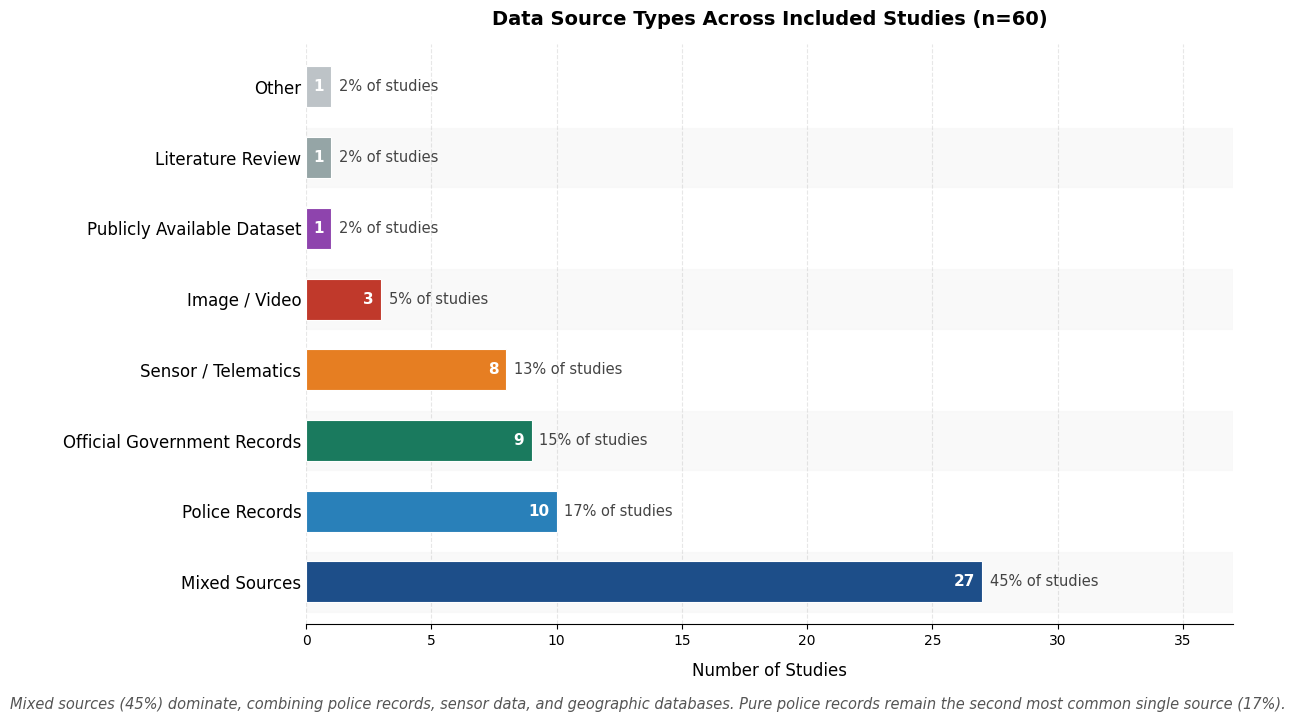

Saved: fig16_data_source.pdf


In [ ]:
# CELL 39 — Figure 16: Data Source Type Distribution

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
SAVE_DIR = '/content/drive/MyDrive/SLR FNN'
total = len(df)

ds_order  = ['Mixed Sources', 'Police Records',
             'Official Government Records', 'Sensor / Telematics',
             'Image / Video', 'Publicly Available Dataset',
             'Literature Review', 'Other']
ds_vals   = [df['DataSource_clean'].value_counts().get(k, 0)
             for k in ds_order]
ds_colors = ['#1d4e89', '#2980b9', '#1a7a5e', '#e67e22',
             '#c0392b', '#8e44ad', '#95a5a6', '#bdc3c7']

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

y    = np.arange(len(ds_order))
bars = ax.barh(y, ds_vals, color=ds_colors,
               height=0.58, edgecolor='white',
               linewidth=0.8, zorder=3)

for bar, v in zip(bars, ds_vals):
    pct = v / total * 100
    ax.text(bar.get_width() - 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{v}',
            ha='right', va='center',
            fontsize=11, fontweight='bold',
            color='white', zorder=4)
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.0f}% of studies',
            ha='left', va='center',
            fontsize=10.5, color='#444444')

for i in range(0, len(ds_order), 2):
    ax.axhspan(i - 0.42, i + 0.42,
               color='#f5f5f5', alpha=0.5, zorder=0)

ax.set_yticks(y)
ax.set_yticklabels(ds_order, fontsize=12)
ax.set_xlabel('Number of Studies', fontsize=12, labelpad=10)
ax.set_xlim(0, max(ds_vals) + 10)
ax.set_ylim(-0.6, len(ds_order) - 0.4)
ax.set_title('Data Source Types Across Included Studies (n=60)',
             fontsize=14, fontweight='bold', pad=14)
ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

fig.text(0.5, -0.02,
         'Mixed sources (45%) dominate, combining police records, '
         'sensor data, and geographic databases. '
         'Pure police records remain the second most common single source (17%).',
         ha='center', fontsize=10.5,
         style='italic', color='#555555')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig16_data_source.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig16_data_source.pdf")

## CELL 40 — Figure 17: Geographic Unit of Analysis

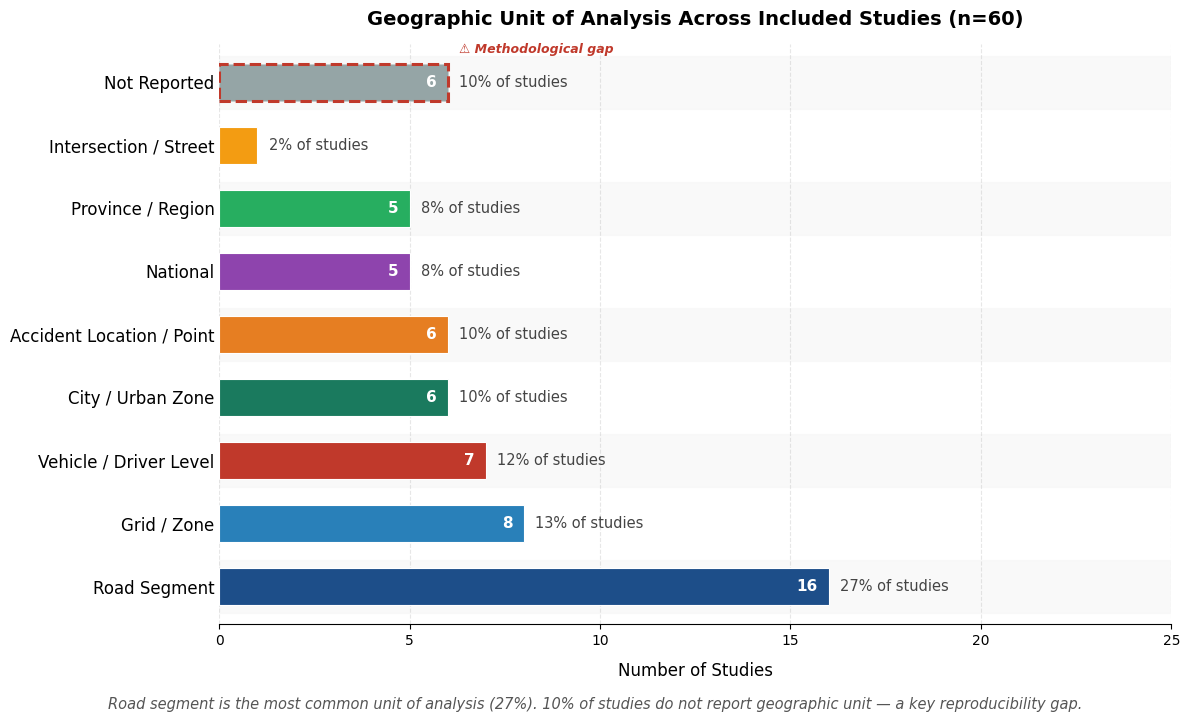

Saved: fig17_geo_unit.pdf


In [ ]:
# CELL 40 — Figure 17: Geographic Unit of Analysis

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

total = len(df)

geo_order  = ['Road Segment', 'Grid / Zone',
              'Vehicle / Driver Level', 'City / Urban Zone',
              'Accident Location / Point', 'National',
              'Province / Region', 'Intersection / Street',
              'Not Reported']
geo_vals   = [df['GeoUnit_clean'].value_counts().get(k, 0)
              for k in geo_order]
geo_colors = ['#1d4e89', '#2980b9', '#c0392b', '#1a7a5e',
              '#e67e22', '#8e44ad', '#27ae60', '#f39c12',
              '#95a5a6']

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

y    = np.arange(len(geo_order))
bars = ax.barh(y, geo_vals, color=geo_colors,
               height=0.58, edgecolor='white',
               linewidth=0.8, zorder=3)

for bar, v in zip(bars, geo_vals):
    pct = v / total * 100
    if v >= 2:
        ax.text(bar.get_width() - 0.3,
                bar.get_y() + bar.get_height() / 2,
                f'{v}',
                ha='right', va='center',
                fontsize=11, fontweight='bold',
                color='white', zorder=4)
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.0f}% of studies',
            ha='left', va='center',
            fontsize=10.5, color='#444444')

# Highlight Not Reported as gap
gap_idx = geo_order.index('Not Reported')
bars[gap_idx].set_edgecolor('#c0392b')
bars[gap_idx].set_linewidth(2.2)
bars[gap_idx].set_linestyle('--')
ax.text(geo_vals[gap_idx] + 0.3,
        gap_idx + 0.42,
        '⚠ Methodological gap',
        ha='left', va='bottom',
        fontsize=9, color='#c0392b',
        fontweight='bold', style='italic')

for i in range(0, len(geo_order), 2):
    ax.axhspan(i - 0.42, i + 0.42,
               color='#f5f5f5', alpha=0.5, zorder=0)

ax.set_yticks(y)
ax.set_yticklabels(geo_order, fontsize=12)
ax.set_xlabel('Number of Studies', fontsize=12, labelpad=10)
ax.set_xlim(0, max(geo_vals) + 9)
ax.set_ylim(-0.6, len(geo_order) - 0.4)
ax.set_title('Geographic Unit of Analysis Across Included Studies (n=60)',
             fontsize=14, fontweight='bold', pad=14)
ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

fig.text(0.5, -0.02,
         'Road segment is the most common unit of analysis (27%). '
         '10% of studies do not report geographic unit — '
         'a key reproducibility gap.',
         ha='center', fontsize=10.5,
         style='italic', color='#555555')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig17_geo_unit.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig17_geo_unit.pdf")

## CELL 41 — Figure 18: Visual Summary Table (Harvest Plot).

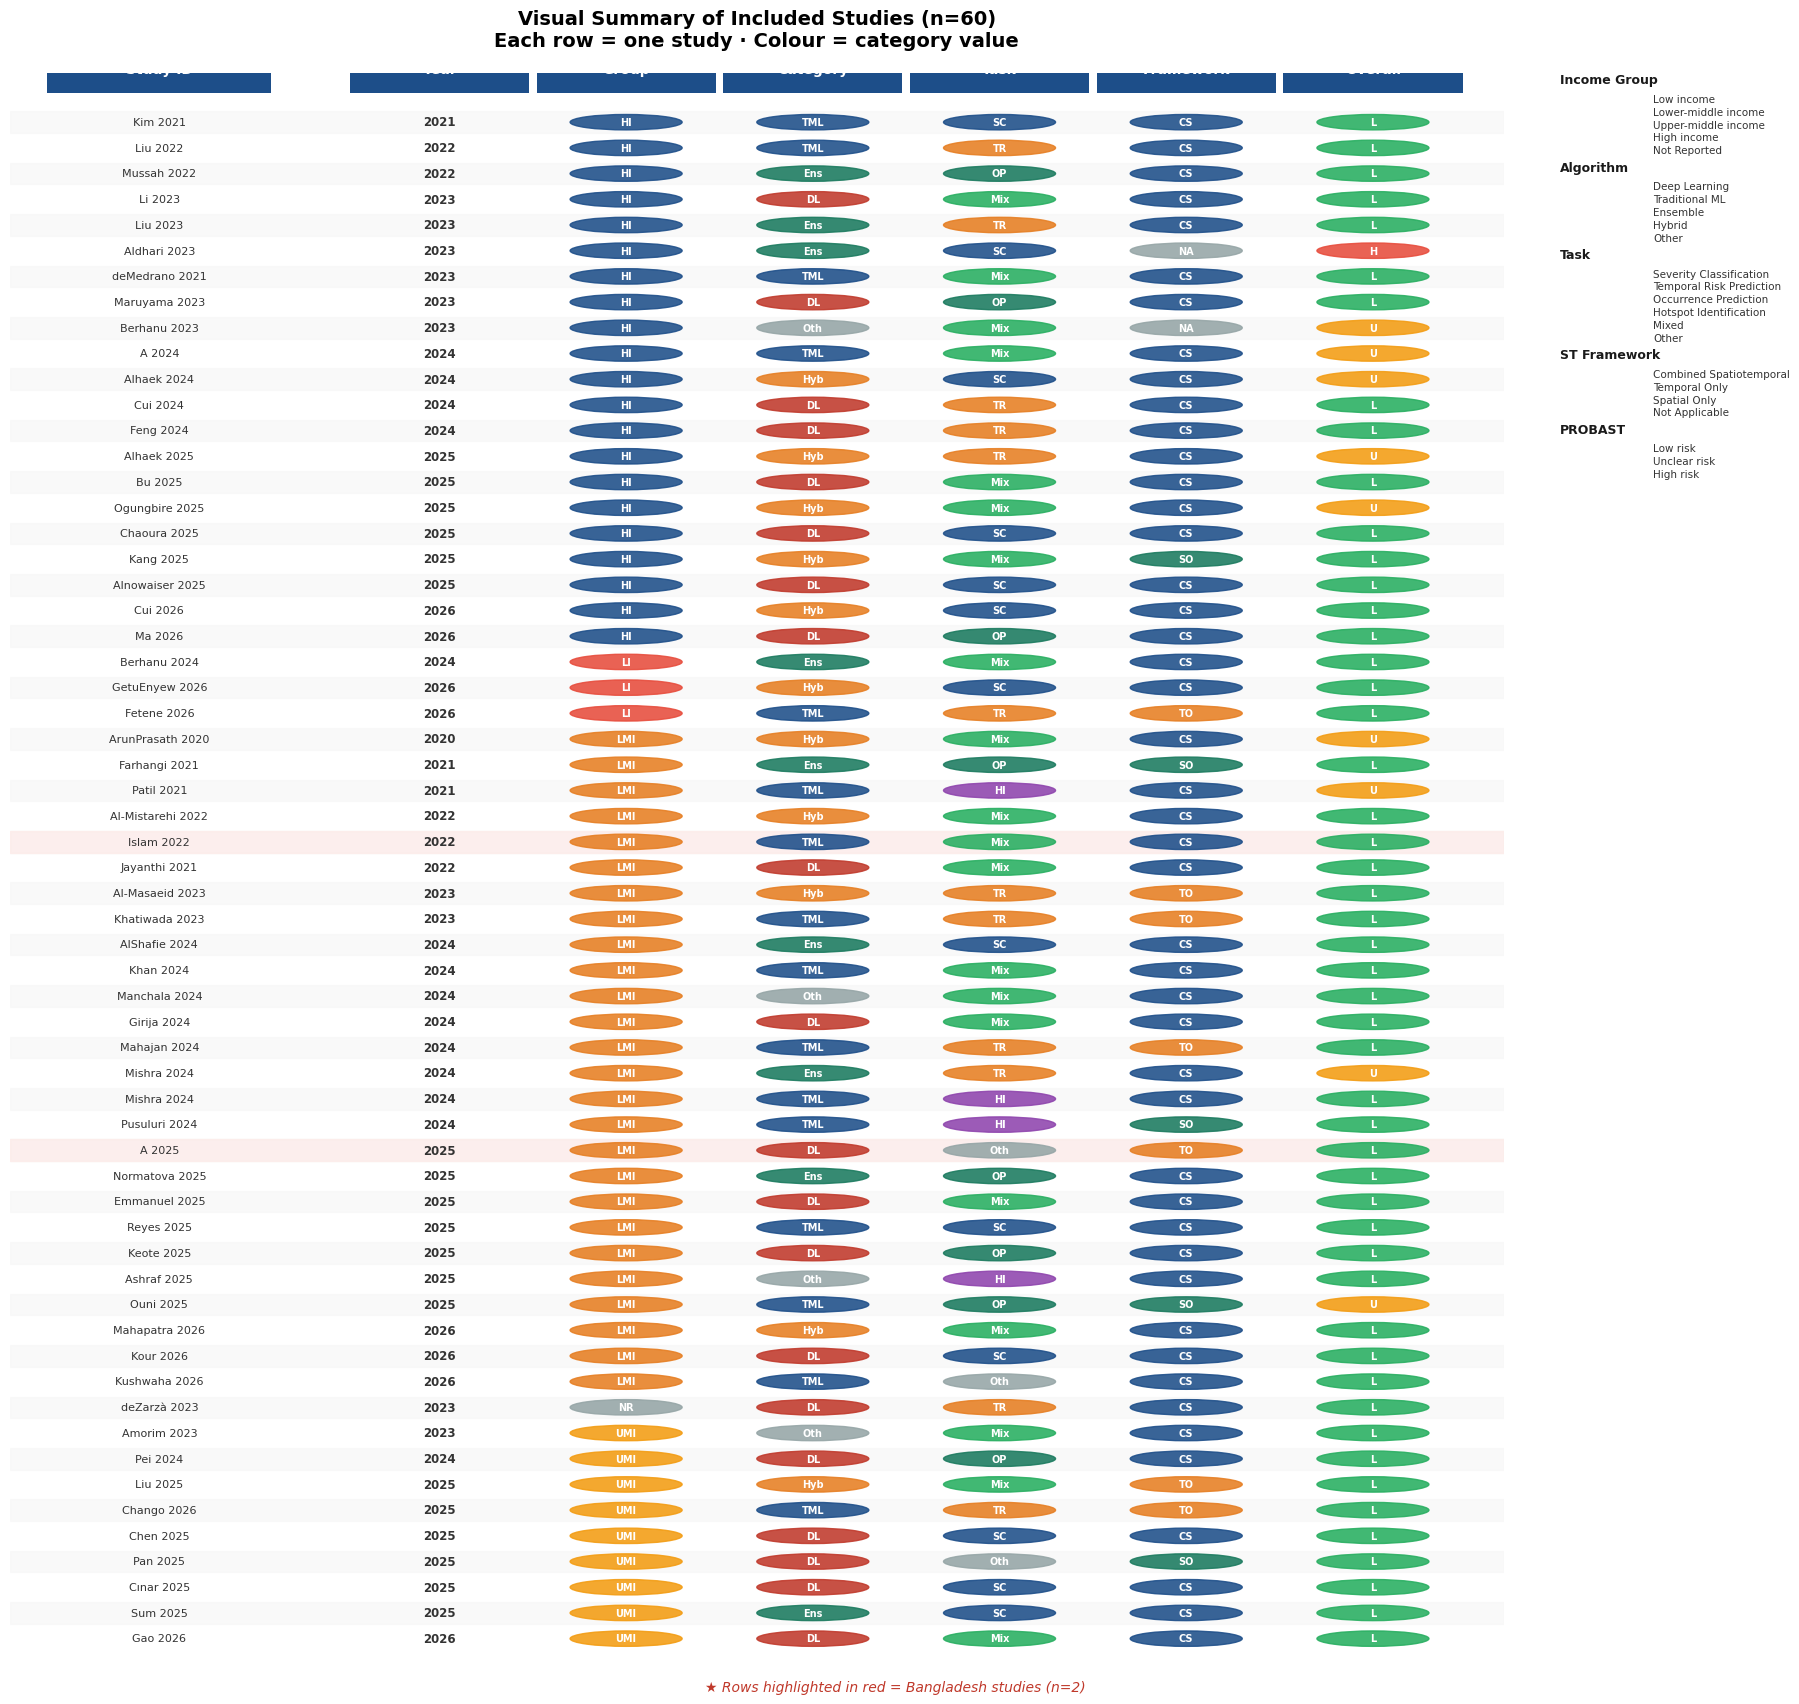

Saved: fig18_visual_summary.pdf


In [ ]:
# CELL 41 — Figure 18: Visual Summary Table (Harvest Plot)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Prepare data ──────────────────────────────────────────────────────────────
plot_df = df[['Study ID', 'Year of publication',
              'Income_clean', 'AlgoCat_clean',
              'Task_clean', 'STFramework_clean',
              'PROBAST_overall', 'Is_LMIC',
              'Is_Bangladesh']].copy()

plot_df = plot_df.sort_values(
    ['Income_clean', 'Year of publication']).reset_index(drop=True)

n = len(plot_df)

# ── Color maps ────────────────────────────────────────────────────────────────
income_colors = {
    'Low income':          '#e74c3c',
    'Lower-middle income': '#e67e22',
    'Upper-middle income': '#f39c12',
    'High income':         '#1d4e89',
    'Not Reported':        '#95a5a6',
}
algo_colors = {
    'Deep Learning':  '#c0392b',
    'Traditional ML': '#1d4e89',
    'Ensemble':       '#1a7a5e',
    'Hybrid':         '#e67e22',
    'Other':          '#95a5a6',
}
task_colors = {
    'Severity Classification':    '#1d4e89',
    'Temporal Risk Prediction':   '#e67e22',
    'Occurrence Prediction':      '#1a7a5e',
    'Hotspot Identification':     '#8e44ad',
    'Mixed':                      '#27ae60',
    'Other':                      '#95a5a6',
}
st_colors = {
    'Combined Spatiotemporal': '#1d4e89',
    'Temporal Only':           '#e67e22',
    'Spatial Only':            '#1a7a5e',
    'Not Applicable':          '#95a5a6',
}
rob_colors = {
    'Low risk':     '#27ae60',
    'Unclear risk': '#f39c12',
    'High risk':    '#e74c3c',
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig_h = max(14, n * 0.28)
fig, ax = plt.subplots(figsize=(18, fig_h))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Column definitions: (x_center, label, color_map, col_key)
col_defs = [
    (0,   'Year',        None,          'Year of publication'),
    (1,   'Income\nGroup', income_colors, 'Income_clean'),
    (2,   'Algorithm\nCategory', algo_colors, 'AlgoCat_clean'),
    (3,   'Prediction\nTask', task_colors, 'Task_clean'),
    (4,   'ST\nFramework', st_colors,   'STFramework_clean'),
    (5,   'PROBAST\nOverall', rob_colors, 'PROBAST_overall'),
]

dot_r = 0.30

# Header row
for cx, label, _, _ in col_defs:
    ax.text(cx, n + 0.8, label,
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            color='white')
    rect = plt.Rectangle((cx - 0.48, n + 0.15), 0.96, 0.75,
                           facecolor='#1d4e89', zorder=2)
    ax.add_patch(rect)

# Study ID header
ax.text(-1.5, n + 0.8, 'Study ID',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='white')
rect = plt.Rectangle((-2.1, n + 0.15), 1.2, 0.75,
                      facecolor='#1d4e89', zorder=2)
ax.add_patch(rect)

# Data rows
for i, row in plot_df.iterrows():
    y_pos = n - 1 - i

    # zebra
    if i % 2 == 0:
        ax.axhspan(y_pos - 0.42, y_pos + 0.42,
                   color='#f5f5f5', alpha=0.5, zorder=0)

    # Bangladesh highlight
    if row['Is_Bangladesh']:
        ax.axhspan(y_pos - 0.42, y_pos + 0.42,
                   color='#fdecea', alpha=0.8, zorder=0)

    # Study ID
    ax.text(-1.5, y_pos,
            str(row['Study ID']),
            ha='center', va='center',
            fontsize=8, color='#333333')

    # Dots for each column
    for cx, _, color_map, col_key in col_defs:
        val = row[col_key]

        if color_map is None:
            # Year — text
            ax.text(cx, y_pos, str(int(val)),
                    ha='center', va='center',
                    fontsize=8.5, color='#333333',
                    fontweight='bold')
        else:
            color = color_map.get(str(val), '#cccccc')
            circle = plt.Circle((cx, y_pos), dot_r,
                                  color=color, alpha=0.88,
                                  zorder=3)
            ax.add_patch(circle)
            # abbreviated label inside dot
            short = {
                'Deep Learning':            'DL',
                'Traditional ML':           'TML',
                'Ensemble':                 'Ens',
                'Hybrid':                   'Hyb',
                'Other':                    'Oth',
                'Severity Classification':  'SC',
                'Temporal Risk Prediction': 'TR',
                'Occurrence Prediction':    'OP',
                'Hotspot Identification':   'HI',
                'Mixed':                    'Mix',
                'Combined Spatiotemporal':  'CS',
                'Temporal Only':            'TO',
                'Spatial Only':             'SO',
                'Not Applicable':           'NA',
                'Low risk':                 'L',
                'Unclear risk':             'U',
                'High risk':                'H',
                'Low income':               'LI',
                'Lower-middle income':      'LMI',
                'Upper-middle income':      'UMI',
                'High income':              'HI',
                'Not Reported':             'NR',
            }
            abbr = short.get(str(val), '?')
            tc   = 'white' if color != '#cccccc' else '#333333'
            ax.text(cx, y_pos, abbr,
                    ha='center', va='center',
                    fontsize=7, fontweight='bold',
                    color=tc, zorder=4)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(-2.3, 5.7)
ax.set_ylim(-0.8, n + 1.2)
ax.set_yticks([])
ax.set_xticks([])
ax.spines[['top','right','bottom','left']].set_visible(False)

ax.set_title(
    'Visual Summary of Included Studies (n=60)\n'
    'Each row = one study · Colour = category value',
    fontsize=14, fontweight='bold', pad=14)

# ── Legends ───────────────────────────────────────────────────────────────────
legend_data = [
    ('Income Group',   income_colors),
    ('Algorithm',      algo_colors),
    ('Task',           task_colors),
    ('ST Framework',   st_colors),
    ('PROBAST',        rob_colors),
]

x_leg = 6.0
y_leg = n + 0.5
for group_label, cmap in legend_data:
    ax.text(x_leg, y_leg, group_label,
            fontsize=9, fontweight='bold',
            color='#1a1a1a',
            transform=ax.transData)
    y_leg -= 0.6
    for label, color in cmap.items():
        circle = plt.Circle((x_leg + 0.18, y_leg), 0.18,
                             color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x_leg + 0.5, y_leg, label,
                fontsize=7.5, va='center',
                color='#333333')
        y_leg -= 0.5
    y_leg -= 0.3

# Bangladesh note
fig.text(0.5, -0.01,
         '★ Rows highlighted in red = Bangladesh studies (n=2)',
         ha='center', fontsize=10,
         style='italic', color='#c0392b')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig18_visual_summary.pdf', dpi=1200,
            bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig18_visual_summary.pdf")

## CELL 42 — Figure 19: Sankey / Alluvial Diagram

In [ ]:
!pip install -U kaleido -q
!pip install plotly -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.6 MB/s eta 0:00:00


In [ ]:
# CELL 42 FINAL FIX — Install correct kaleido for Colab
!pip install kaleido==0.2.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.8 MB/s eta 0:00:00


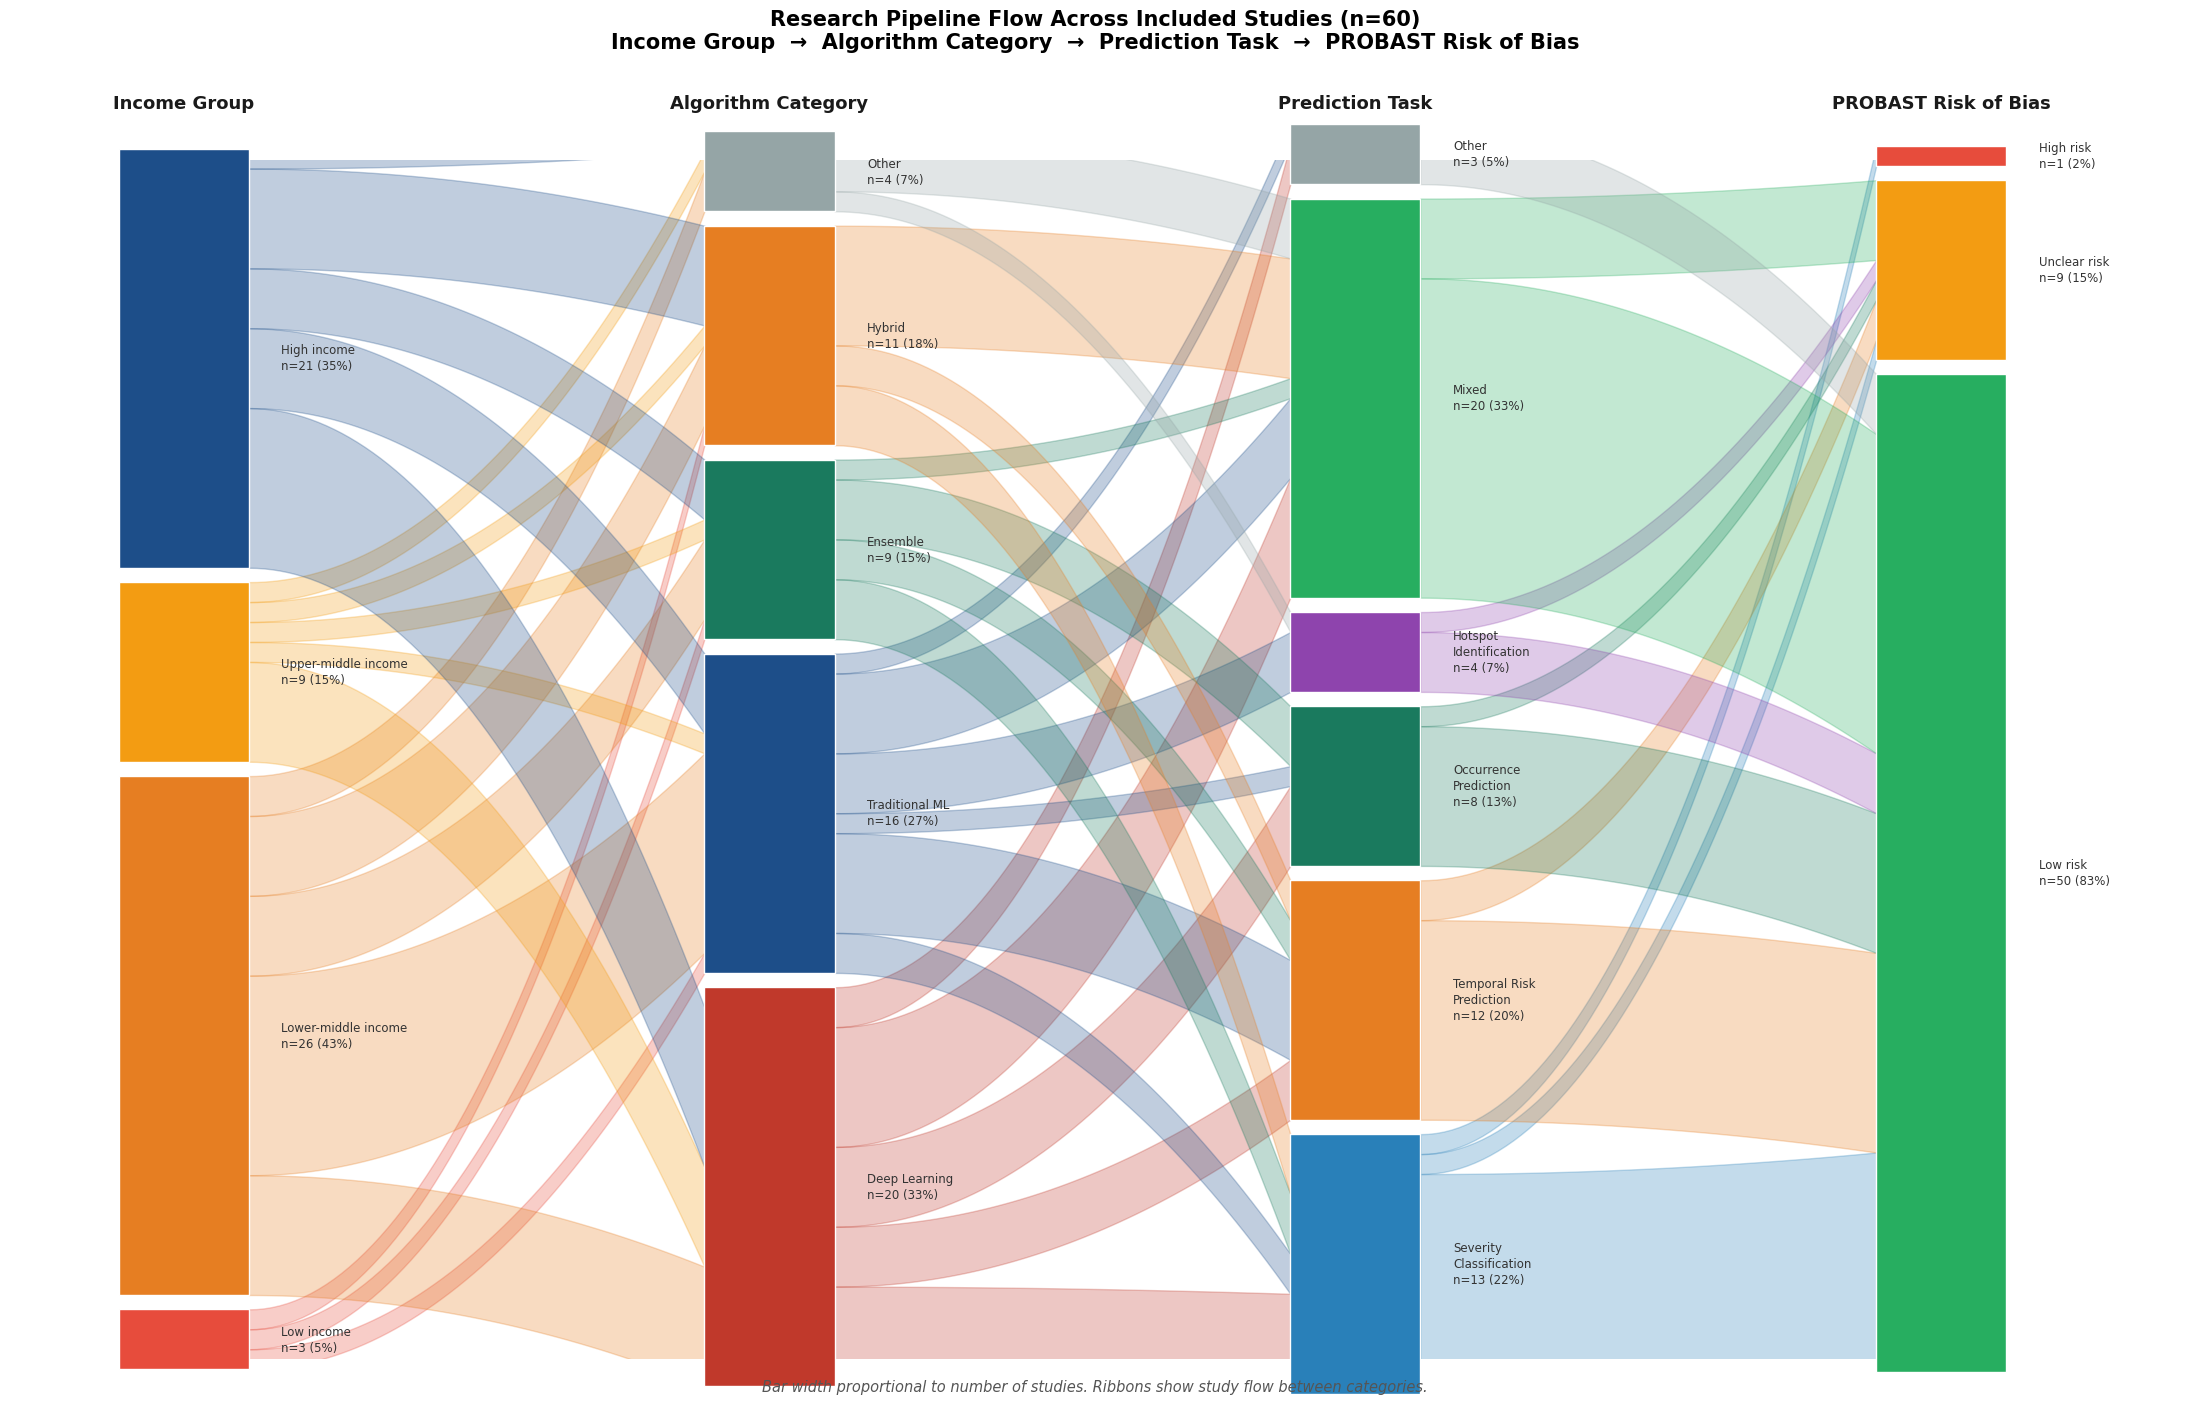

Saved: fig19_sankey.pdf


In [ ]:
# CELL 43 MATPLOTLIB SANKEY — Figure 19: Research Pipeline Flow

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
income_cats = ['Low income', 'Lower-middle income',
               'Upper-middle income', 'High income']
algo_cats   = ['Deep Learning', 'Traditional ML',
               'Ensemble', 'Hybrid', 'Other']
task_cats   = ['Severity\nClassification',
               'Temporal Risk\nPrediction',
               'Occurrence\nPrediction',
               'Hotspot\nIdentification',
               'Mixed', 'Other']
rob_cats    = ['Low risk', 'Unclear risk', 'High risk']

income_colors = {'Low income':          '#e74c3c',
                 'Lower-middle income': '#e67e22',
                 'Upper-middle income': '#f39c12',
                 'High income':         '#1d4e89'}
algo_colors   = {'Deep Learning':  '#c0392b',
                 'Traditional ML': '#1d4e89',
                 'Ensemble':       '#1a7a5e',
                 'Hybrid':         '#e67e22',
                 'Other':          '#95a5a6'}
task_colors   = {'Severity\nClassification':    '#2980b9',
                 'Temporal Risk\nPrediction':   '#e67e22',
                 'Occurrence\nPrediction':      '#1a7a5e',
                 'Hotspot\nIdentification':     '#8e44ad',
                 'Mixed':                       '#27ae60',
                 'Other':                       '#95a5a6'}
rob_colors    = {'Low risk':     '#27ae60',
                 'Unclear risk': '#f39c12',
                 'High risk':    '#e74c3c'}

# ── Count flows ───────────────────────────────────────────────────────────────
task_keys = ['Severity Classification',
             'Temporal Risk Prediction',
             'Occurrence Prediction',
             'Hotspot Identification',
             'Mixed', 'Other']
task_label_map = dict(zip(task_keys,
                           task_cats))

def get_flow(col_a, col_b, a, b):
    b_key = {v: k for k, v in
             task_label_map.items()}.get(b, b)
    return ((df[col_a] == a) &
            (df[col_b] == b_key)).sum()

def get_flow2(col_a, col_b, a, b):
    a_key = {v: k for k, v in
             task_label_map.items()}.get(a, a)
    return ((df[col_a] == a_key) &
            (df[col_b] == b)).sum()

# ── Layout: 4 columns ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')
ax.axis('off')

col_x     = [0.08, 0.35, 0.62, 0.89]
col_labels = ['Income Group',
              'Algorithm Category',
              'Prediction Task',
              'PROBAST Risk of Bias']
total     = len(df)

# Column header
for cx, lbl in zip(col_x, col_labels):
    ax.text(cx, 1.04, lbl,
            ha='center', va='bottom',
            fontsize=13, fontweight='bold',
            color='#1a1a1a',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#1d4e89',
                      edgecolor='none',
                      alpha=0.9,
                      color='white'))

# ── Draw bars for each column ─────────────────────────────────────────────────
def draw_bars(ax, cats, counts, colors_dict,
              x_center, total, bar_w=0.06):
    """Returns {cat: (y_center, height)} for flow drawing."""
    positions = {}
    gap       = 0.012
    total_h   = sum(counts[c]/total for c in cats)
    total_h  += gap * (len(cats) - 1)

    y_start = 0.5 - total_h / 2

    for cat in cats:
        h     = counts[cat] / total
        color = colors_dict.get(cat, '#cccccc')

        rect = plt.Rectangle(
            (x_center - bar_w/2, y_start),
            bar_w, h,
            facecolor=color, edgecolor='white',
            linewidth=1.0, zorder=3,
            transform=ax.transAxes,
            clip_on=False)
        ax.add_patch(rect)

        y_mid = y_start + h / 2
        positions[cat] = (y_mid, h)

        # label
        n_val = counts[cat]
        pct   = n_val / total * 100
        label_x = x_center + bar_w/2 + 0.015
        ax.text(label_x, y_mid,
                f'{cat}\nn={n_val} ({pct:.0f}%)',
                va='center', ha='left',
                fontsize=8.5, color='#333333',
                transform=ax.transAxes,
                linespacing=1.3)

        y_start += h + gap

    return positions

# Count per category
inc_counts  = {c: (df['Income_clean'] == c).sum()
               for c in income_cats}
algo_counts = {c: (df['AlgoCat_clean'] == c).sum()
               for c in algo_cats}
task_counts = {c: (df['Task_clean'] == tk).sum()
               for c, tk in zip(task_cats, task_keys)}
rob_counts  = {c: (df['PROBAST_overall'] == c).sum()
               for c in rob_cats}

pos_inc  = draw_bars(ax, income_cats, inc_counts,
                     income_colors, col_x[0], total)
pos_algo = draw_bars(ax, algo_cats,   algo_counts,
                     algo_colors,  col_x[1], total)
pos_task = draw_bars(ax, task_cats,   task_counts,
                     task_colors,  col_x[2], total)
pos_rob  = draw_bars(ax, rob_cats,    rob_counts,
                     rob_colors,   col_x[3], total)

# ── Draw flow ribbons ─────────────────────────────────────────────────────────
bar_w = 0.06

def draw_flows(ax, pos_left, pos_right,
               col_a, col_b, cats_left, cats_right,
               colors_left, x_left, x_right,
               task_map=None, reverse_task=False):

    # Compute cumulative offsets within each bar
    left_offsets  = {c: 0.0 for c in cats_left}
    right_offsets = {c: 0.0 for c in cats_right}

    for a in cats_left:
        for b in cats_right:
            if task_map and not reverse_task:
                b_key = {v: k for k, v in
                         task_map.items()}.get(b, b)
                v = ((df[col_a] == a) &
                     (df[col_b] == b_key)).sum()
            elif task_map and reverse_task:
                a_key = {v: k for k, v in
                         task_map.items()}.get(a, a)
                v = ((df[col_a] == a_key) &
                     (df[col_b] == b)).sum()
            else:
                v = ((df[col_a] == a) &
                     (df[col_b] == b)).sum()

            if v == 0:
                continue

            h_flow    = v / total
            color     = colors_left.get(a, '#cccccc')
            y_left_c  = pos_left[a][0]
            h_left    = pos_left[a][1]
            y_right_c = pos_right[b][0]
            h_right   = pos_right[b][1]

            # Start/end y coords
            y0_bot = (y_left_c - h_left/2 +
                      left_offsets[a])
            y0_top = y0_bot + h_flow
            y1_bot = (y_right_c - h_right/2 +
                      right_offsets[b])
            y1_top = y1_bot + h_flow

            left_offsets[a]  += h_flow
            right_offsets[b] += h_flow

            # Bezier ribbon
            n_pts  = 60
            t      = np.linspace(0, 1, n_pts)
            cx1    = x_left  + bar_w/2
            cx2    = x_right - bar_w/2
            ctrl_x = (cx1 + cx2) / 2

            top_y = (y0_top * (1-t)**2 +
                     2 * (y0_top) * (1-t) * t +
                     y1_top * t**2)
            bot_y = (y0_bot * (1-t)**2 +
                     2 * (y0_bot) * (1-t) * t +
                     y1_bot * t**2)
            xs    = cx1 + (cx2 - cx1) * t

            ax.fill_between(
                xs, bot_y, top_y,
                color=color, alpha=0.28,
                transform=ax.transAxes,
                zorder=1)

# Income → Algo
draw_flows(ax, pos_inc, pos_algo,
           'Income_clean', 'AlgoCat_clean',
           income_cats, algo_cats,
           income_colors, col_x[0], col_x[1])

# Algo → Task
draw_flows(ax, pos_algo, pos_task,
           'AlgoCat_clean', 'Task_clean',
           algo_cats, task_cats,
           algo_colors, col_x[1], col_x[2],
           task_map=task_label_map)

# Task → ROB
draw_flows(ax, pos_task, pos_rob,
           'Task_clean', 'PROBAST_overall',
           task_cats, rob_cats,
           task_colors, col_x[2], col_x[3],
           task_map=task_label_map,
           reverse_task=True)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)



fig.text(0.5, 0.01,
         'Bar width proportional to number of studies. '
         'Ribbons show study flow between categories.',
         ha='center', fontsize=10.5,
         style='italic', color='#555555')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig19_sankey.pdf',
            dpi=1200, bbox_inches='tight',
            format='pdf')
plt.show()
print("Saved: fig19_sankey.pdf")

## CELL 45 — Figure 20: Search Keyword String Word Cloud

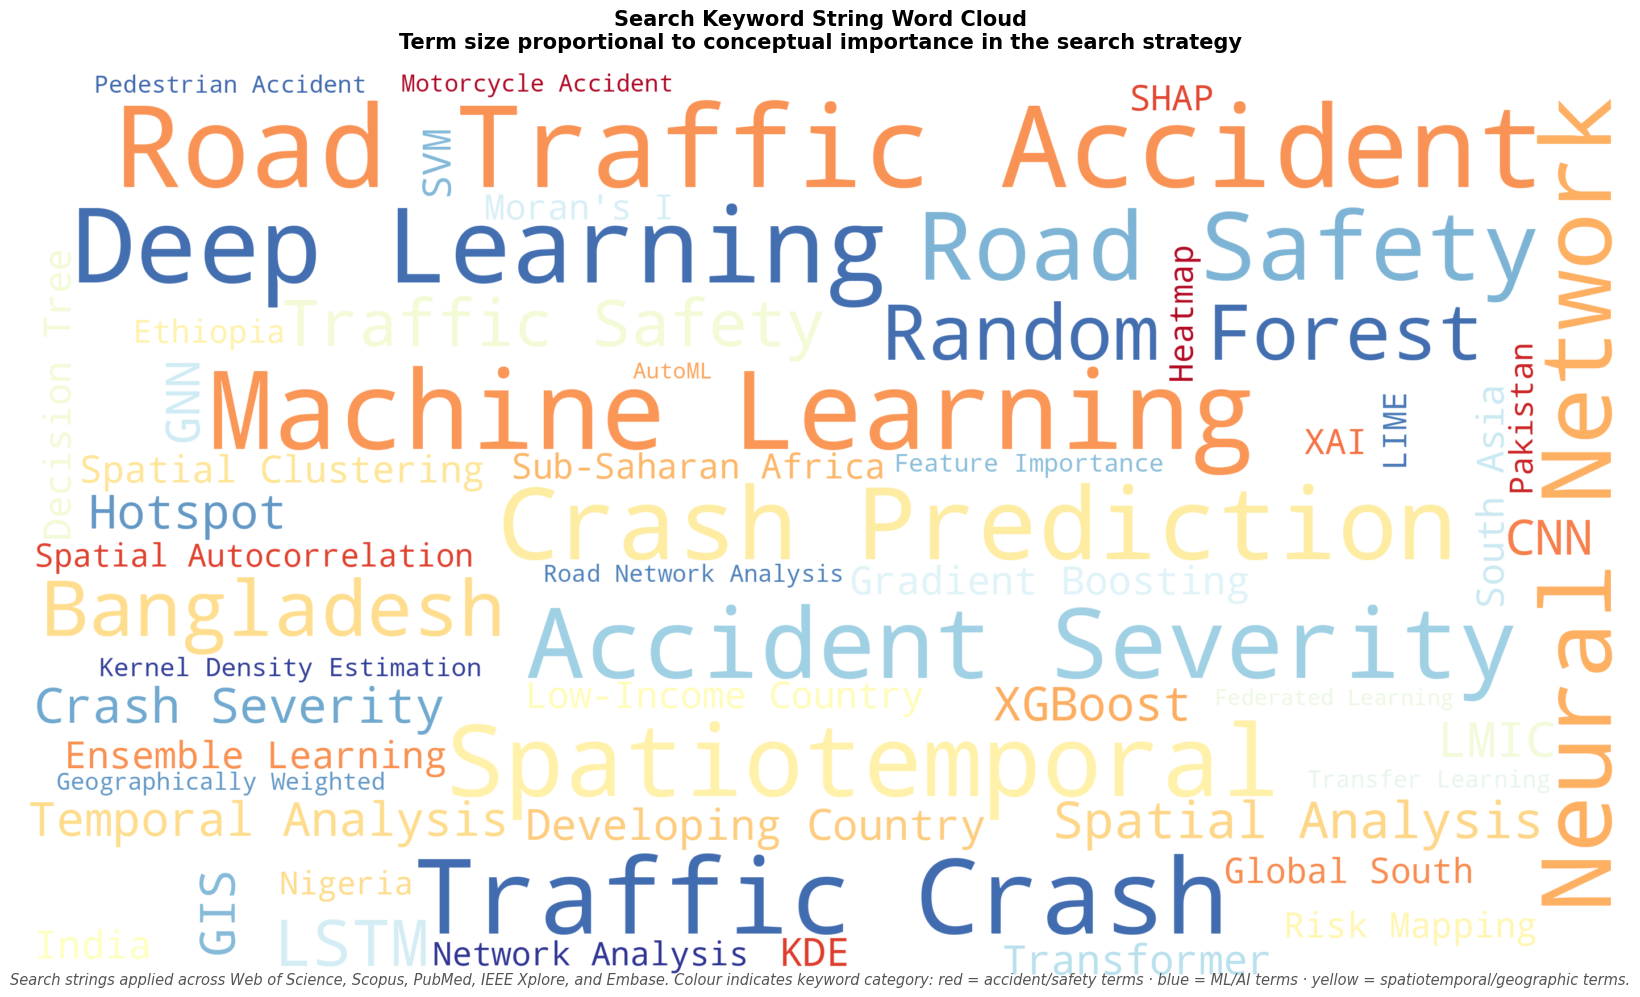

Saved: fig20_search_keyword_cloud.pdf


In [ ]:
# CELL 45 — Figure 20: Search Keyword String Word Cloud

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re
from collections import Counter

# ── Your full search string ───────────────────────────────────────────────────
search_string = """
road traffic accident, road traffic crash, traffic accident, traffic crash,
road crash, road collision, vehicle collision, motor vehicle accident,
motor vehicle crash, traffic injury, traffic fatality, road fatality,
pedestrian accident, motorcycle accident, road safety, traffic safety,
road incident, accident severity, crash severity, accident frequency,
crash prediction, traffic accident prediction,
machine learning, deep learning, artificial intelligence, neural network,
convolutional neural network, CNN, recurrent neural network, RNN,
long short-term memory, LSTM, graph neural network, GNN,
graph attention network, transformer model, BERT,
random forest, decision tree, support vector machine, SVM,
gradient boosting, XGBoost, LightGBM, CatBoost, k-nearest neighbor, KNN,
logistic regression, naive bayes, ensemble learning, ensemble method,
data mining, predictive model, classification model, regression model,
automated machine learning, AutoML, transfer learning, federated learning,
explainable artificial intelligence, XAI, SHAP, LIME, feature importance,
feature selection, spatiotemporal, spatio-temporal, spatial-temporal,
spatial analysis, temporal analysis, geospatial, geographic information system,
GIS, spatial pattern, temporal pattern, spatial distribution, temporal distribution,
hotspot, hot spot, blackspot, accident hotspot, crash hotspot,
kernel density estimation, KDE, spatial clustering, spatial autocorrelation,
Moran's I, LISA, geographically weighted regression, GWR, spatial regression,
risk mapping, crash mapping, accident mapping, density mapping, heatmap,
road network analysis, network analysis, point pattern analysis,
developing country, low-income country, middle-income country,
low and middle income country, LMIC, Global South, resource-limited,
resource-constrained, Sub-Saharan Africa, South Asia, Southeast Asia,
Latin America, Middle East, North Africa, West Africa, East Africa,
Bangladesh, India, Pakistan, Sri Lanka, Nepal, Myanmar, Cambodia, Vietnam,
Indonesia, Philippines, Thailand, Malaysia, Laos, China, Iran, Iraq, Jordan,
Nigeria, Ethiopia, Kenya, Ghana, Tanzania, Uganda, Rwanda, Mozambique,
Zambia, Zimbabwe, Cameroon, Senegal, Morocco, Algeria, Tunisia, Egypt,
Brazil, Colombia, Peru, Bolivia, Ecuador, Paraguay, Venezuela
"""

# ── Manual frequency boosts for domain importance ────────────────────────────
# More important terms get higher frequency
manual_freq = {
    # Core topic — highest weight
    'Road Traffic Accident':    120,
    'Traffic Crash':            100,
    'Crash Prediction':          90,
    'Accident Severity':         85,
    'Road Safety':               80,
    'Traffic Safety':            75,
    'Crash Severity':            70,

    # ML methods — high weight
    'Machine Learning':         110,
    'Deep Learning':            100,
    'Neural Network':            85,
    'Random Forest':             80,
    'LSTM':                      75,
    'CNN':                       70,
    'GNN':                       65,
    'XGBoost':                   65,
    'Transformer':               60,
    'SVM':                       55,
    'Gradient Boosting':         55,
    'Decision Tree':             50,
    'Ensemble Learning':         50,
    'SHAP':                      45,
    'XAI':                       45,
    'LIME':                      40,

    # Spatiotemporal — medium weight
    'Spatiotemporal':            90,
    'Spatial Analysis':          75,
    'Temporal Analysis':         65,
    'GIS':                       70,
    'Hotspot':                   65,
    'KDE':                       55,
    'Spatial Clustering':        50,
    'Moran\'s I':                45,
    'Risk Mapping':              45,
    'Network Analysis':          40,
    'Heatmap':                   40,
    'Spatial Autocorrelation':   40,

    # LMIC/Geography — medium weight
    'LMIC':                      70,
    'Developing Country':        65,
    'Bangladesh':                80,  # boost — focus country
    'India':                     55,
    'Sub-Saharan Africa':        45,
    'South Asia':                50,
    'Global South':              45,
    'Low-Income Country':        50,
    'Nigeria':                   40,
    'Ethiopia':                  40,
    'Pakistan':                  40,

    # Other terms — lower weight
    'Pedestrian Accident':       35,
    'Motorcycle Accident':       35,
    'Road Network Analysis':     35,
    'Kernel Density Estimation': 40,
    'Geographically Weighted':   35,
    'Feature Importance':        40,
    'Transfer Learning':         35,
    'AutoML':                    30,
    'Federated Learning':        30,
}

# ── Generate word cloud ───────────────────────────────────────────────────────
wc = WordCloud(
    width             = 2800,
    height            = 1600,
    background_color  = 'white',
    colormap          = 'RdYlBu_r',
    max_words         = 150,
    max_font_size     = 200,
    min_font_size     = 14,
    prefer_horizontal = 0.70,
    collocations      = False,
    relative_scaling  = 0.45,
    margin            = 10,
    random_state      = 42,
).generate_from_frequencies(manual_freq)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('#ffffff')
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')

ax.set_title(
    'Search Keyword String Word Cloud\n'
    'Term size proportional to conceptual importance in the search strategy',
    fontsize=15, fontweight='bold', pad=16)

fig.text(0.5, 0.01,
         'Search strings applied across Web of Science, Scopus, PubMed, '
         'IEEE Xplore, and Embase. '
         'Colour indicates keyword category: '
         'red = accident/safety terms · blue = ML/AI terms · '
         'yellow = spatiotemporal/geographic terms.',
         ha='center', fontsize=10.5,
         style='italic', color='#555555')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig20_search_keyword_cloud.pdf',
            dpi=1200, bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig20_search_keyword_cloud.pdf")

## CELL 46 — Figure 21: Journal Distribution + Paper Keyword Cloud

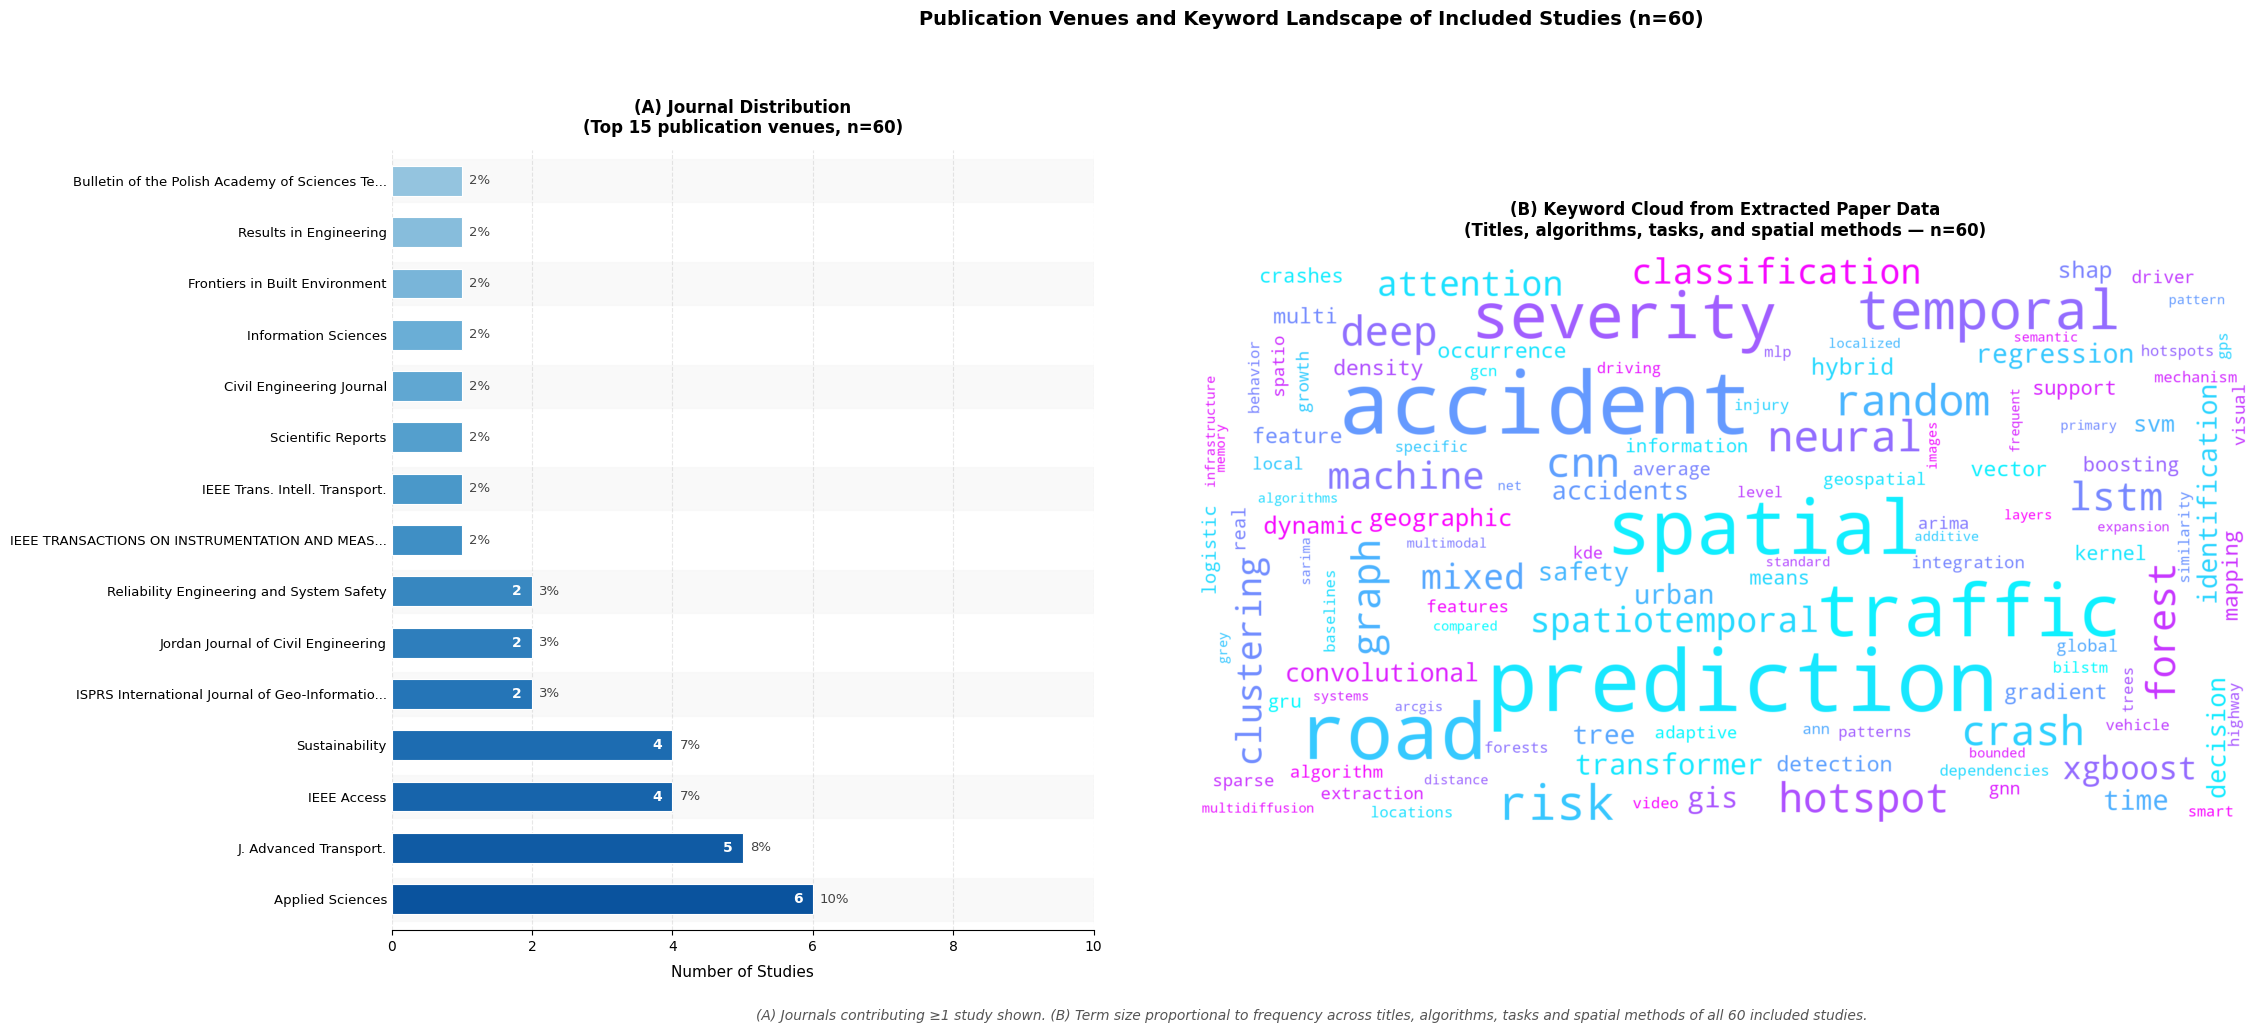

Saved: fig21_journal_keyword.pdf


In [ ]:
# CELL 46 — Figure 21: Journal Distribution + Paper Keyword Cloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import re
from collections import Counter

# ── Panel A: Journal distribution ────────────────────────────────────────────
journal_counts = df['Journal name'].value_counts()

# Clean journal names — truncate long ones
def clean_journal(j):
    if pd.isna(j): return 'Not Reported'
    j = str(j).strip()
    # common abbreviations
    replacements = {
        'Transportation Research Part C: Emerging Technologies': 'Transport. Res. Part C',
        'Accident Analysis and Prevention':                      'Accident Anal. & Prev.',
        'Accident Analysis & Prevention':                        'Accident Anal. & Prev.',
        'Transportation Research Record':                        'Transport. Res. Record',
        'IEEE Transactions on Intelligent Transportation Systems':
            'IEEE Trans. Intell. Transport.',
        'International Journal of Environmental Research and Public Health':
            'Int. J. Environ. Res. Public Health',
        'Applied Sciences':                                      'Applied Sciences',
        'Journal of Advanced Transportation':                    'J. Advanced Transport.',
        'Expert Systems with Applications':                      'Expert Syst. Appl.',
        'IEEE Access':                                           'IEEE Access',
        'Sustainability':                                        'Sustainability',
        'Sensors':                                               'Sensors',
        'Neural Networks':                                       'Neural Networks',
    }
    for full, abbr in replacements.items():
        if full.lower() in j.lower():
            return abbr
    # truncate if too long
    return j[:45] + '...' if len(j) > 45 else j

journal_clean = df['Journal name'].apply(clean_journal).value_counts()
# Keep top 15
top15 = journal_clean.head(15)

# ── Panel B: Keyword cloud from paper titles + known SLR findings ─────────────
# Combine all titles + key terms extracted from 60 papers
all_titles = ' '.join(df['Title'].fillna('').tolist())
all_algos  = ' '.join(df['ML algorithm or algorithms used '].fillna('').tolist())
all_tasks  = ' '.join(df['Prediction task type'].fillna('').tolist())
all_spatial= ' '.join(df['Spatial analysis method used '].fillna('').tolist())

combined_text = ' '.join([all_titles, all_algos, all_tasks, all_spatial])

# ── Custom stopwords ──────────────────────────────────────────────────────────
custom_stops = set(WordCloud().stopwords) | {
    'using', 'based', 'study', 'approach', 'method', 'model', 'models',
    'analysis', 'case', 'new', 'via', 'towards', 'used', 'use',
    'utilizing', 'a', 'an', 'the', 'for', 'of', 'in', 'on', 'and',
    'with', 'to', 'from', 'by', 'through', 'between', 'across',
    'within', 'among', 'driven', 'oriented', 'aware', 'related',
    'prone', 'mounted', 'caused', 'enhanced', 'integrated',
    'comparative', 'examining', 'exploring', 'advancing', 'enhancing',
    'harnessing', 'encoding', 'learning', 'identifying', 'predicting',
    'forecasting', 'classifying', 'modeling', 'estimation', 'evaluation',
    'applications', 'advancements', 'research', 'performance',
    'framework', 'system', 'network', 'networks', 'data', 'technique',
    'techniques', 'proposed', 'two', 'three', 'four', 'five',
    'first', 'second', 'also', 'however', 'results', 'proposed',
    'high', 'low', 'large', 'small', 'best', 'multiple',
}

words = re.findall(r'\b[a-zA-Z]{3,}\b', combined_text.lower())
freq  = Counter(w for w in words
                if w not in {s.lower() for s in custom_stops})

# Boost important terms
boosts = {
    'accident':        3.5, 'traffic':         3.0,
    'prediction':      3.0, 'road':            3.0,
    'severity':        2.8, 'spatiotemporal':  3.0,
    'spatial':         2.5, 'temporal':        2.3,
    'crash':           2.8, 'hotspot':         2.5,
    'risk':            2.3, 'lstm':            2.0,
    'random':          1.8, 'forest':          1.8,
    'deep':            2.0, 'graph':           2.0,
    'gnn':             1.8, 'xgboost':         1.8,
    'urban':           1.8, 'safety':          2.2,
    'gis':             2.0, 'shap':            1.8,
    'clustering':      1.8, 'convolutional':   1.8,
    'transformer':     1.8, 'driver':          1.8,
    'injury':          2.0, 'lmic':            2.2,
    'bangladesh':      2.5, 'developing':      2.0,
    'kde':             1.6, 'neural':          2.0,
    'cnn':             1.8, 'frequency':       1.5,
}
freq_boosted = {w: int(c * boosts.get(w, 1.0) * 8)
                for w, c in freq.items() if c > 0}

# ── Figure: 2 panels ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 10))
fig.patch.set_facecolor('#ffffff')
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1.8],
                        wspace=0.12,
                        left=0.04, right=0.97,
                        top=0.88, bottom=0.10)

# ── Panel A: Horizontal bar — journal distribution ────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#ffffff')

y       = np.arange(len(top15))
vals    = top15.values
labels  = top15.index.tolist()
total   = len(df)

# color gradient: top journals darker
cmap   = plt.cm.Blues
colors = [cmap(0.4 + 0.5 * (i / len(vals)))
          for i in range(len(vals))][::-1]

bars = ax1.barh(y, vals, color=colors,
                height=0.58, edgecolor='white',
                linewidth=0.8, zorder=3)

for bar, v in zip(bars, vals):
    pct = v / total * 100
    if v >= 2:
        ax1.text(bar.get_width() - 0.15,
                 bar.get_y() + bar.get_height()/2,
                 f'{v}', ha='right', va='center',
                 fontsize=10, fontweight='bold',
                 color='white', zorder=4)
    ax1.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height()/2,
             f'{pct:.0f}%', ha='left', va='center',
             fontsize=9.5, color='#444444')

for i in range(0, len(top15), 2):
    ax1.axhspan(i - 0.42, i + 0.42,
                color='#f5f5f5', alpha=0.5, zorder=0)

ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=9.5)
ax1.set_xlabel('Number of Studies', fontsize=11, labelpad=8)
ax1.set_xlim(0, max(vals) + 4)
ax1.set_ylim(-0.6, len(top15) - 0.4)
ax1.set_title('(A) Journal Distribution\n(Top 15 publication venues, n=60)',
              fontsize=12, fontweight='bold', pad=12)
ax1.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax1.spines[['top','right','left']].set_visible(False)
ax1.tick_params(axis='y', length=0)

# ── Panel B: Word cloud from extracted paper data ─────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#ffffff')

wc2 = WordCloud(
    width             = 2200,
    height            = 1200,
    background_color  = 'white',
    colormap          = 'cool',
    max_words         = 120,
    max_font_size     = 180,
    min_font_size     = 14,
    prefer_horizontal = 0.72,
    collocations      = False,
    relative_scaling  = 0.50,
    margin            = 8,
    random_state      = 7,
).generate_from_frequencies(freq_boosted)

ax2.imshow(wc2, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('(B) Keyword Cloud from Extracted Paper Data\n'
              '(Titles, algorithms, tasks, and spatial methods — n=60)',
              fontsize=12, fontweight='bold', pad=12)

# ── Main title ────────────────────────────────────────────────────────────────
fig.suptitle(
    'Publication Venues and Keyword Landscape of Included Studies (n=60)',
    fontsize=14, fontweight='bold', y=1.02)

fig.text(0.5, 0.01,
         '(A) Journals contributing ≥1 study shown. '
         '(B) Term size proportional to frequency across titles, '
         'algorithms, tasks and spatial methods of all 60 included studies.',
         ha='center', fontsize=10,
         style='italic', color='#555555')

plt.savefig(f'{SAVE_DIR}/fig21_journal_keyword.pdf',
            dpi=1200, bbox_inches='tight', format='pdf')
plt.show()
print("Saved: fig21_journal_keyword.pdf")